# 08 — Muon isolation × |Δφ|: tight / loose comparison (4μ)

For the mu-isolation × |Δφ| study, use a **2×2 comparison**. Rows apply the partner-LJ isolation event cuts **iso1<0.25** and **iso1<0.50**; columns apply the tight ABCD boundaries **(0.25, 2.0)** and loose boundaries **(0.50, 1.5)**. The partner is the eγ LJ in 2μ2e and the subleading muon LJ in 4μ. Keep mass≥150 GeV and the stated nominal/double-inverse displacement definitions fixed, with no |Δφ| event precut.

The columns within one row share a selected plane and move only the ABCD boundaries. Changing the row changes the event sample because partner isolation is a genuine preselection. The 0.25 sample is nested within the 0.50 sample; do not combine them as independent measurements or add their yields. Retain each profile's individual yields, closure, correlation, signal metrics, and DATA gate decisions.

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


In [1]:
from pathlib import Path
import ast
import gc
import hashlib
import json
import sys
from datetime import datetime, timezone

SIDM_DIR = next((p for p in (Path.cwd(), *Path.cwd().parents) if p.name == "sidm"), None)
if SIDM_DIR is None:
    raise RuntimeError("Run this notebook from within the sidm repository.")
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(0, str(SIDM_DIR.parent))
NOTEBOOK_DIR = SIDM_DIR / "studies" / "ABCD_plane_summary"
STUDIES_DIR = SIDM_DIR / "studies"

# Import coffea/pyarrow before registering NumPy 2 pickle compatibility aliases.
import coffea.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "pdf.fonttype": 42})
pd.set_option("display.max_columns", 20)


## Inputs and partner-isolation row profiles

For the mu-isolation × |Δφ| study, use a **2×2 comparison**. Rows apply the partner-LJ isolation event cuts **iso1<0.25** and **iso1<0.50**; columns apply the tight ABCD boundaries **(0.25, 2.0)** and loose boundaries **(0.50, 1.5)**. The partner is the eγ LJ in 2μ2e and the subleading muon LJ in 4μ. Keep mass≥150 GeV and the stated nominal/double-inverse displacement definitions fixed, with no |Δφ| event precut.

The columns within one row share a selected plane and move only the ABCD boundaries. Changing the row changes the event sample because partner isolation is a genuine preselection. The 0.25 sample is nested within the 0.50 sample; do not combine them as independent measurements or add their yields. Retain each profile's individual yields, closure, correlation, signal metrics, and DATA gate decisions.

In [2]:
TOPOLOGY = '4mu'
NOTEBOOK_NAME = '08_MuIso_DPhi_4mu_6D_comparison.ipynb'
TIGHT_BOUNDARY = {"iso": .25, "dphi": 2.0}
LOOSE_BOUNDARY = {"iso": .50, "dphi": 1.5}
PARTNER_ISO_MAXIMA = (.25, .5)
MASS_MIN = 150.0
SR_YIELD_YLIM = (0.0, 10.0)
MAX_SIGNAL_FRACTION = .10  # Contamination diagnostic only.
GATE_MODE = "leakage"
LEAKAGE_LIMIT = .15
LEAKAGE_CONTEXTS = ("SR",)
SHAPE_SIGNAL_SCALE = {}  # Independent optional shape overrides; empty means raw stored weights.
SIGNAL_REFERENCES = {'mA200': '4Mu_200GeV_0p25GeV_1p0mm', 'mA500': '4Mu_500GeV_0p25GeV_0p4mm', 'mA800': '4Mu_800GeV_0p25GeV_0p25mm', 'mA1000': '4Mu_1000GeV_0p25GeV_0p2mm'}
SIGNAL_SCALE = {}
RUN_DATA = True
SAVE_FIGURES = True
EXPORT_TABLES = True
OUTPUT_DIR = NOTEBOOK_DIR / '08_MuIso_DPhi_4mu_6D_comparison_outputs'
CONFIG = {
    "topology": TOPOLOGY,
    "current_dir": NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_bkg_merged_samples_v1",
    "bkg_dir": NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_bkg_merged_samples_v1",
    "signal_dir": NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_signal_merged_samples_v1",
    "data_dir": NOTEBOOK_DIR / "ABCD_6D_inclusive_eHEM_skimv1_v1_data_merged_samples_v1",
    "current_hist": "abcd6d_"+TOPOLOGY,
    "expected_current_channel": "abcd6d_inclusive_"+TOPOLOGY+"_dxySpread_cosAlpha_mu_veto_eHEM",
    "tight_boundary": TIGHT_BOUNDARY,
    "loose_boundary": LOOSE_BOUNDARY,
    "partner_iso_maxima": PARTNER_ISO_MAXIMA,
    "mass_min": MASS_MIN,
    "pixel_max": 2,
    "lost_min": 1,
    "iso_scan_max": 1.0,
    "iso_grid": np.array([.05,.10,.15,.20,.25,.30,.40,.50]),
    "dphi_grid": np.array([1.0,1.5,2.0,2.2,2.4,2.6,2.8,3.0]),
    "signal_references": SIGNAL_REFERENCES,
    "signal_scale": SIGNAL_SCALE,
    "max_signal_fraction": MAX_SIGNAL_FRACTION,
    "gate_mode": GATE_MODE, "leakage_limit": LEAKAGE_LIMIT, "leakage_contexts": LEAKAGE_CONTEXTS,
    "shape_signal_scale": SHAPE_SIGNAL_SCALE,
    "min_neff": 10.,
    "expected_background_count": 18,
    "expected_data_count": 68,
    "run_data": RUN_DATA,
    "source_label": "MC",
    "yield_ylim_by_context": {"SR": SR_YIELD_YLIM},
    "x_label": 'Leading mu-LJ isolation',
    "y_label": "|Δφ| [rad]",
}
print("Tight boundary:", TIGHT_BOUNDARY, "loose boundary:", LOOSE_BOUNDARY)
print("Partner isolation row profiles:", PARTNER_ISO_MAXIMA, "; M(LJ,LJ) >=", MASS_MIN, "GeV")
print("Delta phi is an ABCD axis: no delta-phi event preselection is applied.")


Tight boundary: {'iso': 0.25, 'dphi': 2.0} loose boundary: {'iso': 0.5, 'dphi': 1.5}
Partner isolation row profiles: (0.25, 0.5) ; M(LJ,LJ) >= 150.0 GeV
Delta phi is an ABCD axis: no delta-phi event preselection is applied.


## 2. Plane definitions and helpers

Isolation passes for **iso0<xcut**; the angular condition passes for **|Δφ|≥ycut**. Thus A is the **upper-left** quadrant: low isolation and high |Δφ|. B is high isolation/high |Δφ|, C is low isolation/low |Δφ|, and D is high isolation/low |Δφ|. The y-pass direction is opposite to the iso×iso plane.

Sum the background components in each region first, then calculate $P=BC/D$, $\kappa=A/P$, and $N_{\mathrm{eff}}=(\sum w)^2/\sum w^2$. The total-background prediction is nonlinear and is not the sum of process-by-process predictions. Yield errors use $\sqrt{\sum w^2}$; prediction and closure errors use first-order propagation of disjoint-region variances. Preserve undefined ratios, unsupported inputs, and low-statistics flags. Negative weighted yields are not clipped in numerical ABCD sums.

Exclude iso0 underflow from the ABCD sums and retain its overflow in B/D. Partition angular underflow into C/D and angular overflow into A/B. The partner-isolation event cut also excludes iso1 underflow. Mass overflow is retained by the mass≥150 GeV selection. Photon lost-hit sentinel 999 is a displacement-axis overflow value and is retained when selected by the lost-hit requirement. Correlation uses regular plane bins only, so its support differs from the flow-inclusive angular yield partition.

In [3]:
"""Current-6D muon isolation versus absolute delta-phi ABCD comparison.

Standalone MC preparation and late, point-gated DATA VR evaluation. The partner
isolation is a fixed event cut. Both displayed plane axes retain pass/fail sides:
x passes below its isolation boundary, y passes above its angle boundary.
"""
from pathlib import Path
from datetime import datetime, timezone
import copy
import gc
import hashlib
import json
import sys

import coffea.util
import numpy as np
import pandas as pd
import yaml

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

PLANE_PROFILE_VALUES = {"p025": .25, "p050": .5}
PLANE_BENCHMARKS = ("p025_tight", "p025_loose", "p050_tight", "p050_loose")
PLANE_CONTEXTS = ("SR", "VR")
PLANE_COMPONENTS = ("QCD", "DY", "TTJets", "Diboson")
COMPARISON_VARIABLES = ("iso0", "iso1", "disp0", "disp1", "abs_dphi", "ljlj_mass")


def _comparison_json(value):
    def convert(item):
        if isinstance(item, (set, frozenset)):
            return sorted(item, key=str)
        if isinstance(item, np.generic):
            return item.item()
        if isinstance(item, np.ndarray):
            return item.tolist()
        if isinstance(item, Path):
            return str(item)
        return str(item)
    return json.dumps(value, sort_keys=True, default=convert)


def _comparison_hash(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _comparison_group(sample):
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample == "TTJets":
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    raise ValueError(f"Unexpected MC background sample: {sample}")


def _comparison_split(edges, threshold):
    matches = np.flatnonzero(np.isclose(edges, float(threshold), rtol=0, atol=1e-12))
    if len(matches) != 1:
        raise ValueError(f"A requested threshold is not a unique stored bin edge: {threshold}")
    return int(matches[0]) + 1  # Numeric underflow is index zero.


def _comparison_validate_arrays(values, variances):
    if variances is None or values.shape != variances.shape:
        raise ValueError("Weighted values and sumw2 must have the same shape.")
    if not np.isfinite(values).all() or not np.isfinite(variances).all():
        raise ValueError("The selected histogram contains nonfinite weights or sumw2.")
    if np.any(variances < 0):
        raise ValueError("The selected histogram contains negative sumw2.")


def _comparison_plane(values, variances, xedges, yedges):
    values = np.asarray(values, dtype=float).copy()
    variances = np.asarray(variances, dtype=float).copy()
    _comparison_validate_arrays(values, variances)
    xedges = np.asarray(xedges, dtype=float).copy()
    yedges = np.asarray(yedges, dtype=float).copy()
    if values.shape != (len(xedges) + 1, len(yedges) + 1):
        raise ValueError("The 2D plane must contain both numeric flow bins on each axis.")
    return dict(values=values, variances=variances, xedges=xedges, yedges=yedges)


def _comparison_add(target, incoming, component):
    if target is None:
        target = _comparison_plane(incoming["values"], incoming["variances"],
                                   incoming["xedges"], incoming["yedges"])
        target["values"][:] = 0
        target["variances"][:] = 0
        target["components"] = {}
    if not all(np.array_equal(target[key], incoming[key]) for key in ("xedges", "yedges")):
        raise ValueError("Cannot combine planes with different numeric bin edges.")
    target["values"] += incoming["values"]
    target["variances"] += incoming["variances"]
    if component not in target["components"]:
        target["components"][component] = dict(
            values=np.zeros_like(incoming["values"]),
            variances=np.zeros_like(incoming["variances"]))
    target["components"][component]["values"] += incoming["values"]
    target["components"][component]["variances"] += incoming["variances"]
    return target


def _comparison_payload(path, source):
    loaded = coffea.util.load(path)
    outputs = loaded.get("out", loaded) if isinstance(loaded, dict) else None
    if outputs is None or set(outputs) != {path.stem}:
        raise ValueError(f"The payload sample identity does not match its file name: {path}")
    payload = outputs[path.stem]
    metadata = payload.get("metadata", {})
    if set(metadata.get("is_data", ())) != {False}:
        raise ValueError(f"Only explicitly identified MC backgrounds may be loaded: {path}")
    if set(metadata.get("unweighted_hist", ())) != {False}:
        raise ValueError(f"A weighted production is required: {path}")
    if {str(value) for value in metadata.get("year", ())} != {"2018"}:
        raise ValueError(f"The payload must have a unique 2018 year: {path}")
    if "hists" not in payload or "cutflow" not in payload:
        raise ValueError(f"Missing histograms or production cutflows: {path}")
    return loaded, payload


def _comparison_validate_hist(histogram, path):
    if histogram.storage_type.__name__ != "Weight":
        raise ValueError(f"Weight storage is required: {path}")
    for axis in histogram.axes:
        if not axis.traits.discrete and not (axis.traits.underflow and axis.traits.overflow):
            raise ValueError(f"Numeric flow bins are required: {path}/{axis.name}")


def _comparison_current_cube(payload, path, config):
    expected_hists = {f"abcd6d_{topology}" for topology in ("2mu2e", "4mu")} | {
        f"abcd6d_ref_{topology}_{pair}" for topology in ("2mu2e", "4mu")
        for pair in ("iso0_vs_iso1", "iso0_vs_abs_dphi", "disp0_vs_disp1")}
    if set(payload["hists"]) != expected_hists:
        raise ValueError(f"The current 6D campaign histogram schema differs: {path}")
    histogram = payload["hists"][config["current_hist"]]
    _comparison_validate_hist(histogram, path)
    if tuple(axis.name for axis in histogram.axes) != ("channel",) + COMPARISON_VARIABLES:
        raise ValueError(f"Current 6D axis order mismatch: {path}")
    channel_axis = histogram.axes["channel"]
    if (list(channel_axis) != [config["expected_current_channel"]]
            or not channel_axis.traits.discrete
            or channel_axis.traits.underflow or channel_axis.traits.overflow):
        raise ValueError(f"Current topology channel identity/flow mismatch: {path}")
    expected_edges = {
        "iso0": [0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5],
        "iso1": [0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5],
        "disp0": np.arange(-.5, 12, 1),
        "disp1": np.arange(-.5, 10 if config["topology"] == "2mu2e" else 12, 1),
        "abs_dphi": [0, .5, 1, 1.5, 2, 2.2, 2.4, 2.6, 2.7, 2.8, 2.9, 3, 3.05, 3.1, np.pi],
        "ljlj_mass": [0, 50, 100, 150, 200, 300, 400, 600, 800, 1000, 1500, 2500],
    }
    edges = {name: np.asarray(histogram.axes[name].edges, dtype=float) for name in COMPARISON_VARIABLES}
    for name in COMPARISON_VARIABLES:
        expected = np.asarray(expected_edges[name], dtype=float)
        if edges[name].shape != expected.shape or not np.allclose(edges[name], expected, rtol=0, atol=1e-12):
            raise ValueError(f"Current campaign stored bin edges differ: {path}/{name}")
    weights, variances = histogram.values(flow=True), histogram.variances(flow=True)
    expected_shape = (1,) + tuple(len(edges[name]) + 1 for name in COMPARISON_VARIABLES)
    if variances is None or weights.shape != expected_shape or variances.shape != expected_shape:
        raise ValueError(f"Current 6D weighted values/variance shape mismatch: {path}")
    return weights[0], variances[0], edges


def plane_statistics(plane, tx, ty, include_iso_underflow=False, min_neff=10.):
    """Match notebook 10 prediction/closure conventions; annotate edge cases.

    B, C and D are total background sums. No negative sumw is clipped. The
    relative-error formula intentionally reproduces notebook 10's zero-sideband
    uncertainty convention; its mathematical limitation is flagged in status.
    """
    regions = _comparison_regions(plane, tx, ty, include_iso_underflow)
    row = dict(tx=float(tx), ty=float(ty), pred=np.nan, pred_error=np.nan,
               kappa=np.nan, kappa_error=np.nan, pull=np.nan,
               status="UNDEFINED_PREDICTION", kappa_status="UNDEFINED_PREDICTION")
    for name, item in regions.items():
        row.update({name: item["value"], "var_" + name: item["variance"],
                    name + "_error": item["error"], "neff_" + name: item["neff"]})
    neffs = np.array([regions[name]["neff"] for name in "ABCD"])
    row.update(neff_min=float(np.min(neffs)), min_neff=float(np.min(neffs)),
               min_sideband_neff=float(np.min(neffs[1:])),
               low_stat=bool(not np.all(np.isfinite(neffs) & (neffs >= min_neff))))
    a, b, c, d = (regions[name]["value"] for name in "ABCD")
    ea, eb, ec, ed = (regions[name]["error"] for name in "ABCD")
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        row["status"] = "NONPOSITIVE_D_OR_NONFINITE_SIDEBAND"
        row["kappa_status"] = row["status"]
        return row
    pred = b * c / d
    terms = [(eb / b)**2 if b else 0., (ec / c)**2 if c else 0., (ed / d)**2]
    epred = abs(pred) * np.sqrt(sum(terms))
    row.update(pred=pred, pred_error=epred)
    if b == 0 or c == 0:
        row["status"] = "ZERO_SIDEBAND_LEGACY_ZERO_PREDICTION_ERROR"
    elif b < 0 or c < 0:
        row["status"] = "NEGATIVE_SIDEBAND_RETAINED"
    else:
        row["status"] = "LOW_STAT_SIDEBAND" if not np.all(
            np.isfinite(neffs[1:]) & (neffs[1:] >= min_neff)) else "OK"
    if np.isfinite(a) and pred > 0:
        row["kappa"] = a / pred
        if a > 0:
            row["kappa_error"] = abs(row["kappa"]) * np.sqrt((ea / a)**2 + (epred / pred)**2)
            row["kappa_status"] = "LOW_STAT" if row["low_stat"] else "OK"
        else:
            row["kappa_status"] = "NONPOSITIVE_A_LEGACY_KAPPA_ERROR_UNDEFINED"
    else:
        row["kappa_status"] = "NONPOSITIVE_PREDICTION_OR_NONFINITE_A"
    if np.isfinite(a) and ea**2 + epred**2 > 0:
        row["pull"] = (a - pred) / np.sqrt(ea**2 + epred**2)
    return row


def _comparison_cutflow_rows(payload, path, source, config):
    channels = {"Inclusive": config["expected_current_channel"]}
    rows = []
    for context, channel in channels.items():
        flow = payload["cutflow"].get(channel)
        if flow is None or not isinstance(getattr(flow, "rows", None), dict):
            raise ValueError(f"An auditable SimpleCutflow is missing: {path}/{channel}")
        for sequence, (cut, counts) in enumerate(flow.rows.items()):
            rows.append(dict(source=source, sample=path.stem, component=_comparison_group(path.stem),
                             context=context, channel=channel, sequence=sequence, cut=cut,
                             raw=float(counts["raw"]), weighted=float(counts["weighted"]),
                             interpretation="Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently"))
    return rows


def _extension_reference_metadata(config):
    """Validate the four displaced mass references and describe their physical points."""
    expected = {"mA200": (200., 1.), "mA500": (500., .4),
                "mA800": (800., .25), "mA1000": (1000., .2)}
    references = config["signal_references"]
    if set(references) != set(expected) or len(set(references.values())) != 4:
        raise ValueError("Exactly four distinct displaced references for mA=200, 500, 800 and 1000 GeV are required.")
    prefix = "2Mu2E" if config["topology"] == "2mu2e" else "4Mu"
    physical = {}
    for role, (mass, lifetime) in expected.items():
        sample = references[role]
        parts = sample.split("_")
        try:
            if len(parts) != 4 or parts[0] != prefix:
                raise ValueError("Topology/sample naming mismatch")
            mA = float(parts[1].removesuffix("GeV").replace("p", "."))
            mZd = float(parts[2].removesuffix("GeV").replace("p", "."))
            ctau = float(parts[3].removesuffix("mm").replace("p", "."))
        except (ValueError, AttributeError) as error:
            raise ValueError(f"Invalid named displaced reference: {role}/{sample}") from error
        if not all(np.isclose(actual, required, rtol=0, atol=1e-12)
                   for actual, required in ((mA, mass), (mZd, .25), (ctau, lifetime))):
            raise ValueError(f"Displaced reference {role} must have mA={mass:g} GeV, mZd=0.25 GeV and ctau={lifetime:g} mm.")
        supplied = config.get("signal_reference_metadata", {}).get(role, {})
        for key, actual in (("mA_GeV", mA), ("mZd_GeV", mZd), ("ctau_mm", ctau)):
            if key in supplied and not np.isclose(float(supplied[key]), actual, rtol=0, atol=1e-12):
                raise ValueError(f"Reference metadata contradict the sample identity: {role}/{key}")
        if supplied.get("reference_kind", "displaced") != "displaced":
            raise ValueError(f"Every named reference must be displaced: {role}")
        average = float(supplied.get("avg_transverse_cm", 30.))
        if not np.isfinite(average) or not np.isclose(average, 30., rtol=0, atol=1e-12):
            raise ValueError("The selected four-reference comparison uses a nominal average transverse displacement of 30 cm.")
        physical[role] = dict(mA_GeV=mA, mZd_GeV=mZd, ctau_mm=ctau,
                              reference_kind="displaced", avg_transverse_cm=average,
                              displacement_metadata="Nominal signal-grid average transverse decay length; not an event-level requirement")
    return physical


def _extension_coarsen_regular(plane, ex, ey, key):
    """Exclude flow and regular bins outside the common support; never fold tails."""
    native_x, native_y = plane["xedges"], plane["yedges"]
    values = np.asarray(plane[key], dtype=float)[1:-1, 1:-1]
    selected_x = (native_x[:-1] >= ex[0] - 1e-12) & (native_x[1:] <= ex[-1] + 1e-12)
    selected_y = (native_y[:-1] >= ey[0] - 1e-12) & (native_y[1:] <= ey[-1] + 1e-12)
    low_x, low_y = native_x[:-1][selected_x].copy(), native_y[:-1][selected_y].copy()
    for edge in ex:
        low_x[np.isclose(low_x, edge, rtol=0, atol=1e-12)] = edge
    for edge in ey:
        low_y[np.isclose(low_y, edge, rtol=0, atol=1e-12)] = edge
    ix, iy = np.searchsorted(ex, low_x, side="right") - 1, np.searchsorted(ey, low_y, side="right") - 1
    xx, yy = np.meshgrid(ix, iy, indexing="ij")
    output = np.zeros((len(ex) - 1, len(ey) - 1), dtype=float)
    np.add.at(output, (xx.ravel(), yy.ravel()), values[np.ix_(selected_x, selected_y)].ravel())
    return output


def extension_correlations(plane, tx, ty, ex, ey, min_neff=10.):
    """Weighted Pearson in All/A/B/C/D at centers of shared coarsened bins."""
    regions = ("All", "A", "B", "C", "D")
    if plane is None:
        return [dict(region=region, correlation=np.nan, rho=np.nan, neff=np.nan,
                     status="GATE_BLOCKED", sumw=np.nan, sumw2=np.nan, negative_bins=np.nan,
                     display_binning=_comparison_json(dict(xedges=ex, yedges=ey)),
                     support="Native regular-bin support only; both plane flow axes excluded")
                for region in regions]
    values = _extension_coarsen_regular(plane, ex, ey, "values")
    variances = _extension_coarsen_regular(plane, ex, ey, "variances")
    negative_plane = dict(plane, values=(plane["values"] < 0).astype(float))
    native_negative = _extension_coarsen_regular(negative_plane, ex, ey, "values")
    xx, yy = np.broadcast_arrays(((ex[:-1] + ex[1:]) / 2)[:, None], ((ey[:-1] + ey[1:]) / 2)[None, :])
    xpass, ypass = xx < tx, yy >= ty
    masks = (np.ones(xx.shape, bool), xpass & ypass, ~xpass & ypass, xpass & ~ypass, ~xpass & ~ypass)
    rows = []
    for region, mask in zip(regions, masks):
        weights, vars_ = values[mask], variances[mask]
        row = dict(region=region, correlation=np.nan, rho=np.nan, neff=np.nan, status="EMPTY",
                   sumw=float(weights.sum()), sumw2=float(vars_.sum()), negative_bins=int(np.sum(weights < 0)),
                   native_negative_bins=int(native_negative[mask].sum()),
                   display_binning=_comparison_json(dict(xedges=ex, yedges=ey)),
                   support="Native regular-bin support only; both plane flow axes excluded")
        if not np.isfinite(weights).all() or not np.isfinite(vars_).all() or np.any(vars_ < 0):
            row["status"] = "INVALID_WEIGHT_OR_VARIANCE"
        elif np.any(weights < 0) or row["native_negative_bins"] > 0:
            row["status"] = "NEGATIVE_BINS_NOT_A_PROBABILITY_DISTRIBUTION"
        elif row["sumw"] > 0 and row["sumw2"] > 0:
            row["neff"] = row["sumw"]**2 / row["sumw2"]
            xs, ys = xx[mask], yy[mask]
            mx, my = np.dot(weights, xs) / row["sumw"], np.dot(weights, ys) / row["sumw"]
            vx = np.dot(weights, (xs - mx)**2) / row["sumw"]
            vy = np.dot(weights, (ys - my)**2) / row["sumw"]
            if vx <= 0 or vy <= 0:
                row["status"] = "NO_SPREAD"
            else:
                rho = float(np.dot(weights, (xs - mx) * (ys - my)) / row["sumw"] / np.sqrt(vx * vy))
                if not np.isfinite(rho) or abs(rho) > 1 + 1e-10:
                    row["status"] = "INVALID_MOMENTS"
                else:
                    row.update(rho=float(np.clip(rho, -1, 1)), correlation=float(np.clip(rho, -1, 1)),
                               status="LOW_STAT" if row["neff"] < min_neff else "OK")
        elif row["sumw"] > 0:
            row["status"] = "ZERO_VARIANCE_UNSUPPORTED"
        rows.append(row)
    return rows


def _extension_manifest(path, source, kind, role=None, loaded=True):
    row = dict(source=source, kind=kind, sample=path.stem, reference_role=role,
               file=str(path.resolve()), bytes=path.stat().st_size, loaded=bool(loaded), extra_scale=1.)
    if not loaded:
        row["status"] = "NO_APPROVED_MC_GATE_POINT_NOT_OPENED"
        return row
    metadata_path = path.with_suffix(".meta.yaml")
    if not metadata_path.is_file():
        raise FileNotFoundError(f"Input metadata are required: {metadata_path}")
    with metadata_path.open() as handle:
        metadata = yaml.safe_load(handle)
    matching = [sample for sample in metadata.get("samples", []) if sample["name"] == path.stem]
    if len(matching) != 1 or metadata.get("n_samples") != 1 or metadata.get("unweighted_hist") is not False:
        raise ValueError(f"Weighted single-sample metadata mismatch: {metadata_path}")
    sample = matching[0]
    uris = tuple(str(uri) for uri in sample.get("files", []))
    if len(uris) != sample["n_files"] or len(set(uris)) != len(uris) or not uris:
        raise ValueError(f"Invalid input URI metadata: {metadata_path}")
    row.update(metadata_file=str(metadata_path.resolve()), metadata_sha256=_comparison_hash(metadata_path),
               sha256=_comparison_hash(path), sidm_commit=metadata.get("sidm_commit"),
               coffea_version=metadata.get("coffea_version"), created_utc=metadata.get("created_utc"),
               n_input_files=len(uris), xsec_pb=sample.get("xsec_pb"),
               input_uri_sha256=hashlib.sha256(_comparison_json(sorted(uris)).encode()).hexdigest(), status="LOADED")
    return row


def _extension_data_payload(path):
    """Validate DATA identity without inspecting any DATA SR selection or values."""
    loaded = coffea.util.load(path)
    outputs = loaded.get("out", loaded) if isinstance(loaded, dict) else None
    if outputs is None or set(outputs) != {path.stem}:
        raise ValueError(f"DATA payload sample identity mismatch: {path}")
    payload = outputs[path.stem]
    metadata = payload.get("metadata", {})
    if set(metadata.get("is_data", [])) != {True}:
        raise ValueError(f"Explicit DATA metadata are required: {path}")
    if set(metadata.get("unweighted_hist", [])) != {False}:
        raise ValueError(f"Expected weighted DATA storage configuration: {path}")
    if {str(value) for value in metadata.get("year", [])} != {"2018"}:
        raise ValueError(f"Expected unique 2018 DATA metadata: {path}")
    return loaded, payload


def _extension_signal_statistics(signal, background, tx, ty, min_neff):
    stats = _comparison_regions(signal, tx, ty)
    bkg = _comparison_regions(background, tx, ty)
    row = dict(tx=float(tx), ty=float(ty), s_over_b=np.nan, s_over_b_error=np.nan,
               signal_to_background=np.nan, leakage=np.nan, leakage_error=np.nan,
               leakage_percent=np.nan, signal_total=np.nan, status="UNSUPPORTED", signal_status="UNSUPPORTED")
    for region in "ABCD":
        row.update({"signal_" + region: stats[region]["value"],
                    "signal_var_" + region: stats[region]["variance"],
                    "var_signal_" + region: stats[region]["variance"],
                    "signal_neff_" + region: stats[region]["neff"],
                    "background_" + region: bkg[region]["value"]})
    values = np.array([stats[region]["value"] for region in "ABCD"])
    if not np.isfinite(values).all() or np.any(values < 0):
        row.update(status="NEGATIVE_OR_UNDEFINED_SIGNAL", signal_status="NEGATIVE_OR_UNDEFINED_SIGNAL")
        return row
    a, va = values[0], stats["A"]["variance"]
    ba, bva = bkg["A"]["value"], bkg["A"]["variance"]
    row["s_over_b_status"] = "OK" if np.isfinite(ba) and ba > 0 else "NONPOSITIVE_OR_UNDEFINED_BACKGROUND_A"
    if np.isfinite(ba) and ba > 0:
        row.update(s_over_b=a / ba, signal_to_background=a / ba,
                   s_over_b_error=np.sqrt(va / ba**2 + a**2 * bva / ba**4))
    neffs = np.array([stats[region]["neff"] for region in "ABCD"])
    row["signal_neff_min"] = float(np.min(neffs))
    total = float(values.sum())
    row["signal_total"] = total
    if total <= 0:
        row.update(status="EMPTY_SIGNAL", signal_status="EMPTY_SIGNAL")
        return row
    leakage_yield = float(values[1:].sum())
    vl = sum(stats[region]["variance"] for region in "BCD")
    row.update(leakage=leakage_yield / total, leakage_percent=100 * leakage_yield / total,
               leakage_error=np.sqrt((a**2 * vl + leakage_yield**2 * va) / total**4))
    status = "OK" if np.all(np.isfinite(neffs) & (neffs >= min_neff)) else "LOW_STAT"
    row.update(status=status, signal_status=status)
    return row


def extension_gate(background, signal_planes, tx, ty, limit=.10, *,
                   gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    """Apply the configured criteria separately to every named signal hypothesis."""
    mode, leakage_limit, leakage_contexts = _gate_policy_options(gate_mode, leakage_limit, leakage_contexts)
    limit = float(limit)
    if not np.isfinite(limit) or not 0 < limit < 1:
        raise ValueError("A finite contamination limit strictly between zero and one is required.")
    contamination_reasons, fractions, vr_reasons, vr_fractions, contamination_candidates = [], [], [], [], []
    for context, regions in (("SR", "BCD"), ("VR", "ABCD")):
        bkg = _comparison_regions(background[context], tx, ty)
        for role in signal_planes:
            signal = _comparison_regions(signal_planes[role][context], tx, ty)
            for region in regions:
                b, s = bkg[region]["value"], signal[region]["value"]
                label = f"{role}_{context}_{region}"
                if not np.isfinite(b) or b <= 0:
                    reason = label + ":nonpositive_or_undefined_MC_background"
                    contamination_reasons.append(reason)
                    if context == "VR":
                        vr_reasons.append(reason)
                elif not np.isfinite(s) or s < 0:
                    reason = label + ":negative_or_undefined_signal"
                    contamination_reasons.append(reason)
                    if context == "VR":
                        vr_reasons.append(reason)
                else:
                    fraction = s / (s + b)
                    fractions.append((fraction, label))
                    contamination_candidates.append((fraction / limit, label, role, context, region, "contamination"))
                    if context == "VR":
                        vr_fractions.append((fraction, label))
                    if fraction > limit and not np.isclose(fraction, limit, rtol=0, atol=2 * np.finfo(float).eps):
                        reason = label + ":signal_fraction_exceeds_limit"
                        contamination_reasons.append(reason)
                        if context == "VR":
                            vr_reasons.append(reason)
    leakage_reasons, leakages, leakage_candidates = [], [], []
    for role, context_planes in signal_planes.items():
        for context in leakage_contexts:
            result = _reference_leakage_requirement(context_planes[context], tx, ty, leakage_limit)
            label = f"{role}_{context}"
            if not result["passed"]:
                leakage_reasons.append(label + ":" + result["reason"])
            if np.isfinite(result["leakage"]):
                leakages.append((result["leakage"], label))
                leakage_candidates.append((result["leakage"] / leakage_limit, label, role, context, "BCD/ABCD", "leakage"))
    reasons, candidates = [], []
    if mode in {"contamination", "both"}:
        reasons.extend(contamination_reasons)
        candidates.extend(contamination_candidates)
    if mode in {"leakage", "both"}:
        reasons.extend(leakage_reasons)
        candidates.extend(leakage_candidates)
    passed = not reasons
    worst = max(candidates) if candidates else (np.nan, "UNDEFINED", "UNDEFINED", "UNDEFINED", "UNDEFINED", mode)
    worst_limit = limit if worst[5] == "contamination" else leakage_limit if worst[5] == "leakage" else np.nan
    active_fraction = worst[0] * worst_limit if np.isfinite(worst[0]) else np.nan
    active_rule = {"contamination": "SR BCD and VR ABCD contamination <= limit",
                   "leakage": "Signal leakage strictly < limit in configured contexts",
                   "both": "Both contamination and strict signal leakage requirements"}[mode]
    return dict(approved=passed, gate_passed=passed, gate_reason="; ".join(reasons),
                gate_max_fraction=max(fractions)[0] if fractions else np.nan,
                gate_worst=worst[1], gate_worst_reference=worst[2], gate_worst_context=worst[3],
                gate_worst_region=worst[4], gate_worst_criterion=worst[5],
                gate_active_fraction=active_fraction, gate_active_limit=worst_limit,
                gate_worst_ratio_to_limit=worst[0],
                gate_mode=mode, gate_criterion=active_rule, max_signal_fraction=limit,
                contamination_gate_passed=not contamination_reasons,
                contamination_gate_reason="; ".join(contamination_reasons),
                contamination_gate_worst=max(fractions)[1] if fractions else "UNDEFINED",
                leakage_gate_passed=not leakage_reasons, leakage_gate_reason="; ".join(leakage_reasons),
                gate_max_leakage=max(leakages)[0] if leakages else np.nan,
                leakage_gate_worst=max(leakages)[1] if leakages else "UNDEFINED",
                leakage_limit=leakage_limit, leakage_contexts="+".join(leakage_contexts),
                leakage_comparison="strict <; equality fails",
                vr_only_gate_passed=not vr_reasons,
                vr_only_gate_reason="; ".join(vr_reasons),
                vr_only_gate_max_fraction=max(vr_fractions)[0] if vr_fractions else np.nan,
                vr_only_gate_worst=max(vr_fractions)[1] if vr_fractions else "UNDEFINED",
                vr_only_gate_policy="Hypothetical contamination diagnostic only; not the active DATA criterion",
                reference_count=len(signal_planes), gate_reference_mode="Each named displaced mass reference independently",
                envelope_policy="Maximum fraction is an audit summary only; reference signals are not summed",
                signal_normalization_verified=False,
                policy=f"Conditional four-reference {mode} gate; full signal-grid safety and normalization are not established")


def _extension_gate_region_rows(background, signal_planes, tx, ty, limit=.10, *,
                                gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    """Record criterion types and active requirements; diagnostics never veto alone."""
    mode, leakage_limit, leakage_contexts = _gate_policy_options(gate_mode, leakage_limit, leakage_contexts)
    limit = float(limit)
    if not np.isfinite(limit) or not 0 < limit < 1:
        raise ValueError("A finite contamination limit strictly between zero and one is required.")
    rows = []
    for context in ("SR", "VR"):
        bkg = _comparison_regions(background[context], tx, ty)
        for role in signal_planes:
            signals = _comparison_regions(signal_planes[role][context], tx, ty)
            for region in "ABCD":
                b, s = bkg[region]["value"], signals[region]["value"]
                fraction, passed, status = np.nan, False, "UNSUPPORTED"
                if not np.isfinite(b) or b <= 0:
                    status = "NONPOSITIVE_OR_UNDEFINED_MC_BACKGROUND"
                elif not np.isfinite(s) or s < 0:
                    status = "NEGATIVE_OR_UNDEFINED_SIGNAL"
                else:
                    fraction = s / (s + b)
                    passed = bool(fraction <= limit or np.isclose(fraction, limit, rtol=0, atol=2 * np.finfo(float).eps))
                    status = ("ZERO_SIGNAL_PASS_PROVISIONAL" if s == 0 else "PASS") if passed else "SIGNAL_FRACTION_EXCEEDS_LIMIT"
                contamination_required = context == "VR" or region in "BCD"
                required = contamination_required and mode in {"contamination", "both"}
                rows.append(dict(mc_context=context, region=region, reference_role=role, role=role,
                                 criterion_type="contamination", gate_mode=mode, comparison="<=", criterion_limit=limit,
                                 background=b, signal=s, fraction=fraction, signal_fraction=fraction,
                                 background_variance=bkg[region]["variance"], signal_variance=signals[region]["variance"],
                                 background_neff=bkg[region]["neff"], signal_neff=signals[region]["neff"],
                                 status=status, passes_requirement=passed,
                                 required_for_current_gate=required, required_for_vr_only_gate=context == "VR",
                                 required_for_contamination_gate=contamination_required,
                                 max_signal_fraction=limit, signal_normalization_verified=False))
    for role, context_planes in signal_planes.items():
        for context in leakage_contexts:
            item = _reference_leakage_requirement(context_planes[context], tx, ty, leakage_limit)
            rows.append(dict(mc_context=context, region="BCD/ABCD", reference_role=role, role=role,
                             criterion_type="leakage", gate_mode=mode, comparison="strict <", criterion_limit=leakage_limit,
                             background=np.nan, signal=item["signal_BCD"], fraction=item["leakage"],
                             signal_fraction=np.nan, background_variance=np.nan, signal_variance=item["signal_BCD_variance"],
                             background_neff=np.nan, signal_neff=item["signal_total_neff"],
                             status=item["status"], passes_requirement=item["passed"],
                             required_for_current_gate=mode in {"leakage", "both"},
                             required_for_contamination_gate=False, required_for_vr_only_gate=False,
                             leakage=item["leakage"], leakage_error=item["leakage_error"],
                             signal_total=item["signal_total"], signal_BCD=item["signal_BCD"],
                             signal_total_variance=item["signal_total_variance"], signal_BCD_variance=item["signal_BCD_variance"],
                             supported=item["supported"], leakage_limit=leakage_limit,
                             leakage_contexts="+".join(leakage_contexts), max_signal_fraction=limit,
                             signal_normalization_verified=False))
    return rows


def _extension_blank_statistics(tx, ty, reason="GATE_BLOCKED"):
    row = dict(tx=float(tx), ty=float(ty), pred=np.nan, pred_error=np.nan,
               kappa=np.nan, kappa_error=np.nan, pull=np.nan, neff_min=np.nan, min_neff=np.nan,
               min_sideband_neff=np.nan, low_stat=True, status=reason, kappa_status=reason)
    for region in "ABCD":
        row.update({region: np.nan, "var_" + region: np.nan, region + "_error": np.nan, "neff_" + region: np.nan})
    return row


def _extension_data_scan_status(scan_rows):
    """Classify missing DATA points using only permitted, already evaluated metrics."""
    rows = []
    for item in scan_rows:
        row = dict(benchmark=item["benchmark"], context="VR", direction=item["scan_axis"],
                   scan_axis=item["scan_axis"], threshold=item["threshold"], fixed_threshold=item["fixed_threshold"],
                   tx=item["tx"], ty=item["ty"], approved=bool(item["approved"]),
                   gate_passed=bool(item["gate_passed"]), worst=item["gate_worst"],
                   gatefraction=item.get("gate_active_fraction", item["gate_max_fraction"]),
                   gate_max_fraction=item["gate_max_fraction"],
                   vr_only_gate_passed=bool(item["vr_only_gate_passed"]),
                   vr_only_gate_policy="Hypothetical contamination diagnostic; does not set the active DATA criterion",
                   A=item["A"], pred=item["pred"], kappa=item["kappa"],
                   data_A=item["A"], data_pred=item["pred"], data_kappa=item["kappa"],
                   data_A_available=bool(np.isfinite(item["A"])),
                   data_prediction_available=bool(np.isfinite(item["pred"])),
                   data_kappa_available=bool(np.isfinite(item["kappa"])),
                   raw_status=item["status"], raw_kappa_status=item["kappa_status"],
                   signal_normalization_verified=False)
        row.update({key: item.get(key) for key in (
            "gate_mode", "gate_criterion", "gate_max_leakage", "leakage_limit", "leakage_contexts",
            "gate_active_fraction", "gate_active_limit", "gate_worst_ratio_to_limit",
            "gate_worst_reference", "gate_worst_context", "gate_worst_region", "gate_worst_criterion",
            "contamination_gate_passed", "contamination_gate_reason", "leakage_gate_passed", "leakage_gate_reason")})
        if not item["approved"]:
            row.update(status="GATE_BLOCKED", reason=item["gate_reason"])
        elif item["status"] == "DATA_NOT_LOADED":
            row.update(status="DATA_NOT_LOADED", reason="MC gate approved, but the VR DATA source was not loaded")
        elif np.isfinite(item["D"]) and item["D"] <= 0:
            row.update(status="NONPOSITIVE_D", reason="Approved VR DATA has D <= 0, so BC/D is undefined")
        elif not np.isfinite(item["pred"]):
            row.update(status="UNDEFINED_PREDICTION", reason=item["status"])
        elif not np.isfinite(item["kappa"]):
            row.update(status="UNDEFINED_KAPPA", reason=item["kappa_status"])
        elif not np.isfinite(item["kappa_error"]):
            row.update(status="UNDEFINED_KAPPA_ERROR", reason=item["kappa_status"])
        else:
            row.update(status="AVAILABLE_LOW_STAT" if item["low_stat"] else "AVAILABLE", reason=item["status"])
        rows.append(row)
    return pd.DataFrame(rows)


def _plane_configuration(config):
    config = copy.deepcopy(config)
    if "current_dir" not in config and "bkg_dir" in config:
        config["current_dir"] = config["bkg_dir"]
    if "bkg_dir" in config and Path(config["bkg_dir"]).resolve() != Path(config["current_dir"]).resolve():
        raise ValueError("current_dir and bkg_dir must identify the same current background production.")
    topology = config["topology"]
    if topology not in {"2mu2e", "4mu"}:
        raise ValueError(f"Unknown reconstructed topology: {topology}")
    defaults = dict(current_hist=f"abcd6d_{topology}",
                    expected_current_channel=f"abcd6d_inclusive_{topology}_dxySpread_cosAlpha_mu_veto_eHEM",
                    tight_boundary=dict(iso=.25, dphi=2.), loose_boundary=dict(iso=.5, dphi=1.5),
                    partner_iso_maxima=(.25, .5), mass_min=150., pixel_max=2., lost_min=1., iso_scan_max=1.,
                    iso_grid=[.05, .10, .15, .20, .25, .30, .40, .50],
                    dphi_grid=[1., 1.5, 2., 2.2, 2.4, 2.6, 2.8, 3.],
                    min_neff=10., max_signal_fraction=.10, signal_scale={}, signal_reference_metadata={},
                    gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",),
                    expected_background_count=18, expected_data_count=68, run_data=True)
    for key, value in defaults.items():
        config.setdefault(key, value)
    partners = tuple(sorted(float(value) for value in config["partner_iso_maxima"]))
    if len(partners) != 2 or not np.allclose(partners, (.25, .5), rtol=0, atol=1e-12):
        raise ValueError("This comparison requires the two partner-isolation profiles 0.25 and 0.5.")
    config["partner_iso_maxima"] = partners
    for key, expected in dict(mass_min=150., pixel_max=2., lost_min=1.).items():
        if config[key] is None or not np.isclose(float(config[key]), expected, rtol=0, atol=1e-12):
            raise ValueError(f"This comparison fixes {key}={expected:g}.")
        config[key] = float(config[key])
    if not 0 < float(config["max_signal_fraction"]) < 1:
        raise ValueError("The per-reference contamination limit must lie between zero and one.")
    if not np.isfinite(float(config["iso_scan_max"])) or float(config["iso_scan_max"]) <= 0:
        raise ValueError("A finite positive native isolation scan maximum is required.")
    if not np.isclose(float(config["tight_boundary"]["iso"]), .25, rtol=0, atol=1e-12):
        raise ValueError("The tight muon isolation boundary is fixed to 0.25.")
    if not np.isclose(float(config["loose_boundary"]["iso"]), .5, rtol=0, atol=1e-12):
        raise ValueError("The loose muon isolation boundary is fixed to 0.5.")
    _extension_reference_metadata(config)
    config.update(_gate_config_kwargs(config))
    config["gate_policy_label"] = _plane_gate_policy_label(config)
    return config


def _plane_scientific_signature(config):
    keys = ("topology", "current_dir", "signal_dir", "data_dir", "current_hist", "expected_current_channel",
            "tight_boundary", "loose_boundary", "partner_iso_maxima", "mass_min", "pixel_max", "lost_min",
            "iso_scan_max", "iso_grid", "dphi_grid", "min_neff", "max_signal_fraction", "signal_scale",
            "signal_references", "signal_reference_metadata", "expected_background_count", "expected_data_count")
    keys += ("gate_mode", "leakage_limit", "leakage_contexts")
    scientific = {key: config.get(key) for key in keys}
    return hashlib.sha256(_comparison_json(scientific).encode()).hexdigest()


def _plane_repository_import(directory):
    path = Path(directory).resolve()
    sidm = next((p for p in (path, *path.parents) if p.name == "sidm"), None)
    if sidm is not None and str(sidm.parent) not in sys.path:
        sys.path.insert(0, str(sidm.parent))


def _plane_boundary(benchmark, config):
    column = benchmark.rsplit("_", 1)[-1]
    if column not in {"tight", "loose"}:
        raise ValueError(f"Unknown plane working-point column: {benchmark}")
    setting = config[column + "_boundary"]
    return float(setting["iso"]), float(setting["dphi"])


def _plane_gate_policy_label(config):
    contexts = "+".join(config.get("leakage_contexts", ("SR",)))
    leakage = f"Signal leakage < {100 * float(config.get('leakage_limit', .15)):g}% in {contexts} (strict)"
    contamination = f"MC SR BCD + VR ABCD contamination <= {100 * float(config.get('max_signal_fraction', .10)):g}%"
    mode = config.get("gate_mode", "leakage")
    return "Each displaced reference: " + (leakage if mode == "leakage" else contamination if mode == "contamination" else contamination + "; " + leakage)


def _plane_profile(benchmark):
    profile = benchmark.split("_", 1)[0]
    if profile not in PLANE_PROFILE_VALUES:
        raise ValueError(f"Unknown partner-isolation profile: {benchmark}")
    return profile


def _plane_add_profile_metadata(tables, config):
    for table in tables.values():
        if not isinstance(table, pd.DataFrame):
            continue
        if "benchmark" in table:
            table["partner_profile"] = table["benchmark"].map(_plane_profile)
            table["profile"] = table["partner_profile"]
            table["partner_iso_max"] = table["partner_profile"].map(PLANE_PROFILE_VALUES)
            table["column"] = table["benchmark"].map(lambda value: value.rsplit("_", 1)[-1])
        elif "partner_iso_max" not in table:
            table["partner_iso_max"] = _comparison_json(config["partner_iso_maxima"])
    return tables


def plane_native_thresholds(plane, scan_axis, config):
    if scan_axis == "x":
        edges = np.asarray(plane["xedges"], dtype=float)
        return edges[(edges > 0) & (edges <= float(config["iso_scan_max"]))].copy()
    if scan_axis == "y":
        edges = np.asarray(plane["yedges"], dtype=float)
        # Include the terminal pi edge. Unsupported high-angle sidebands remain
        # explicit undefined/blocked points; do not interpolate or omit them.
        return edges[edges > 0].copy()
    raise ValueError(f"Unknown native one-dimensional scan axis: {scan_axis}")


def _comparison_regions(plane, tx, ty, include_iso_underflow=False):
    """A=low isolation/high angle; retain both angle flows and exclude iso UF."""
    if include_iso_underflow:
        raise ValueError("This plane comparison excludes isolation underflow in every ABCD region.")
    ix = _comparison_split(plane["xedges"], tx)
    iy = _comparison_split(plane["yedges"], ty)
    slices = {"A": (slice(1, ix), slice(iy, None)),
              "B": (slice(ix, None), slice(iy, None)),
              "C": (slice(1, ix), slice(None, iy)),
              "D": (slice(ix, None), slice(None, iy))}
    result = {}
    for region, index in slices.items():
        value = float(plane["values"][index].sum())
        variance = float(plane["variances"][index].sum())
        result[region] = dict(value=value, variance=variance, error=np.sqrt(variance),
                              neff=value**2 / variance if variance > 0 else np.nan)
    return result


def _plane_project(weights, variances, edges, context, config, partner_iso_max=None):
    if context not in PLANE_CONTEXTS:
        raise ValueError(context)
    if partner_iso_max is None:
        partner_iso_max = config.get("partner_iso_max", .5)
    partner = slice(1, _comparison_split(edges["iso1"], float(partner_iso_max)))
    pixel = _comparison_split(edges["disp0"], config["pixel_max"] + .5)
    first = slice(None, pixel) if context == "SR" else slice(pixel, None)
    if config["topology"] == "2mu2e":
        lost = _comparison_split(edges["disp1"], config["lost_min"] - .5)
        second = slice(lost, None) if context == "SR" else slice(None, lost)
    else:
        pixel1 = _comparison_split(edges["disp1"], config["pixel_max"] + .5)
        second = slice(None, pixel1) if context == "SR" else slice(pixel1, None)
    mass = slice(_comparison_split(edges["ljlj_mass"], config["mass_min"]), None)
    selection = (slice(None), partner, first, second, slice(None), mass)
    selected_w, selected_v = weights[selection], variances[selection]
    _comparison_validate_arrays(selected_w, selected_v)
    # No isolation-0 or angle event preselection: preserve both plane axes.
    return _comparison_plane(selected_w.sum(axis=(1, 2, 3, 5)), selected_v.sum(axis=(1, 2, 3, 5)),
                             edges["iso0"], edges["abs_dphi"])


def _plane_gate_key(results, benchmark, tx, ty):
    plane = results["planes"][benchmark]["SR"]
    return (benchmark, _comparison_split(plane["xedges"], tx), _comparison_split(plane["yedges"], ty))


def _plane_selection_audit(config):
    partner = "EGM-LJ" if config["topology"] == "2mu2e" else "Subleading muon-LJ"
    displacement = ("SR: mu pixel<=2 AND EGM lost>=1; VR: mu pixel>2 AND EGM lost<1"
                    if config["topology"] == "2mu2e" else "SR: both mu-LJ pixel<=2; VR: both mu-LJ pixel>2")
    rows = [("Plane", "iso0 versus abs_dphi", "Muon/leading-muon isolation against absolute pair delta-phi"),
            ("Partner isolation event cut", f"{partner} iso1 < 0.25 or < 0.5, in separate row profiles", "Strict upper cuts; partner numeric underflow is excluded"),
            ("Pair mass event cut", "M(LJ,LJ) >= 150 GeV", "Stored exact boundary; mass overflow is retained"),
            ("Angle event preselection", "None", "Angle is a plane axis; retain the entire low/high-angle distribution"),
            ("Displacement", displacement, "Two conditions combined with AND; no additional VR definitions"),
            ("ABCD regions", "A=low iso/high angle, B=high/high, C=low/low, D=high/low", "iso pass < boundary; angle pass >= boundary"),
            ("Plane numeric flows", "iso0 underflow excluded; iso0 overflow retained; both angle flows retained", "Angle underflow in C/D, overflow in A/B"),
            ("Correlation", "Native regular bins only", "Both plane flows excluded; full native iso0[0,5), angle[0,pi) support"),
            ("Normalization", "Stored weighted sumw/sumw2", "No extra luminosity/cross-section scaling; only explicit positive signal overrides"),
            ("Reference gate", _plane_gate_policy_label(config), "Four hypotheses independently; maximum envelope is audit-only, no combined signal model"),
            ("Pair/producer baseline", config["expected_current_channel"], "Fixed stored pair; histogram slicing does not reselect LJs. Producer metadata definition may be <not found>")]
    return pd.DataFrame([dict(selection=name, value=value, explanation=explanation) for name, value, explanation in rows])


def run_plane_mc(config):
    """Stream current MC backgrounds/signals, prepare all gates, and never read DATA."""
    config = _plane_configuration(config)
    _plane_repository_import(config["current_dir"])
    reference_metadata = _extension_reference_metadata(config)
    config["signal_references"] = {role: config["signal_references"][role] for role in reference_metadata}
    paths = sorted(Path(config["current_dir"]).glob("*.coffea"))
    if len(paths) != int(config["expected_background_count"]) or any(path.stat().st_size <= 0 for path in paths):
        raise ValueError("Exactly 18 nonempty current background payloads are required.")
    planes = {b: {context: None for context in PLANE_CONTEXTS} for b in PLANE_BENCHMARKS}
    manifests, cutflow_rows = [], []
    for index, path in enumerate(paths, 1):
        group = _comparison_group(path.stem)
        row = _extension_manifest(path, "current6d", "Background")
        loaded = payload = weights = variances = edges = incoming = None
        try:
            loaded, payload = _comparison_payload(path, "sixd")
            row["payload_metadata"] = _comparison_json(payload["metadata"])
            row["normalization"] = "Stored MC weights; additional scale=1"
            row["component"] = group
            cutflow_rows.extend(_comparison_cutflow_rows(payload, path, "sixd", config))
            weights, variances, edges = _comparison_current_cube(payload, path, config)
            for profile, partner in PLANE_PROFILE_VALUES.items():
                for context in PLANE_CONTEXTS:
                    incoming = _plane_project(weights, variances, edges, context, config, partner)
                    for column in ("tight", "loose"):
                        benchmark = profile + "_" + column
                        planes[benchmark][context] = _comparison_add(planes[benchmark][context], incoming, group)
            manifests.append(row)
        finally:
            loaded = payload = weights = variances = edges = incoming = None
            gc.collect()
        print(f"Current MC backgrounds: {index}/{len(paths)}: {path.stem}")
    cutflow = pd.DataFrame(cutflow_rows)
    total_flow = cutflow.groupby(["source", "context", "channel", "sequence", "cut"], as_index=False, sort=False)[["raw", "weighted"]].sum()
    total_flow["sample"], total_flow["component"] = "Total", "Total"
    total_flow["interpretation"] = "Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently"
    cutflow = pd.concat([cutflow, total_flow], ignore_index=True)

    signal_planes = {b: {} for b in PLANE_BENCHMARKS}
    signal_manifest = []
    for role, sample in config["signal_references"].items():
        path = Path(config["signal_dir"]) / (sample + ".coffea")
        if not path.is_file() or path.stat().st_size <= 0:
            raise FileNotFoundError(f"Missing displaced mass reference: {path}")
        scale = float(config["signal_scale"].get(sample, 1.))
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"A finite positive explicit signal scale is required: {sample}")
        row = _extension_manifest(path, "current6d", "Signal", role)
        row.update(**reference_metadata[role], extra_scale=scale, signal_normalization_verified=False)
        loaded = payload = weights = variances = edges = incoming = selected = None
        try:
            loaded, payload = _comparison_payload(path, "sixd")
            row["payload_metadata"] = _comparison_json(payload["metadata"])
            weights, variances, edges = _comparison_current_cube(payload, path, config)
            selected = {profile: {context: _plane_project(weights, variances, edges, context, config, partner)
                                  for context in PLANE_CONTEXTS} for profile, partner in PLANE_PROFILE_VALUES.items()}
            for context_planes in selected.values():
                for incoming in context_planes.values():
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
            for benchmark in PLANE_BENCHMARKS:
                signal_planes[benchmark][role] = selected[_plane_profile(benchmark)]
            signal_manifest.append(row)
        finally:
            loaded = payload = weights = variances = edges = incoming = selected = None
            gc.collect()
        print(f"Current signal: {role}: {sample}")

    closure_rows, yield_rows, correlation_rows, grid_rows, scan_rows, signal_rows, signal_scan_rows = [], [], [], [], [], [], []
    gates, gate_coordinates = {}, {}
    result = dict(planes=planes)
    def gate_at(benchmark, tx, ty):
        key = _plane_gate_key(result, benchmark, tx, ty)
        if key not in gates:
            gates[key] = extension_gate(planes[benchmark], signal_planes[benchmark], tx, ty, float(config["max_signal_fraction"]),
                                        **_gate_config_kwargs(config))
            gate_coordinates[key] = (float(tx), float(ty))
        return gates[key]
    for benchmark in PLANE_BENCHMARKS:
        wp_x, wp_y = _plane_boundary(benchmark, config)
        gate_at(benchmark, wp_x, wp_y)
        for context in PLANE_CONTEXTS:
            plane = planes[benchmark][context]
            closure_rows.append(dict(benchmark=benchmark, context=context, **plane_statistics(plane, wp_x, wp_y, min_neff=config["min_neff"])))
            for component in ("Total",) + PLANE_COMPONENTS:
                selected = plane if component == "Total" else dict(**plane["components"][component], xedges=plane["xedges"], yedges=plane["yedges"])
                for region, stat in _comparison_regions(selected, wp_x, wp_y).items():
                    yield_rows.append(dict(benchmark=benchmark, context=context, component=component, region=region,
                                           **{"yield": stat["value"]}, variance=stat["variance"], error=stat["error"], neff=stat["neff"]))
                for row in extension_correlations(selected, wp_x, wp_y, plane["xedges"], plane["yedges"], config["min_neff"]):
                    correlation_rows.append(dict(benchmark=benchmark, context=context, component=component, tx=wp_x, ty=wp_y, **row))
            for tx in config["iso_grid"]:
                for ty in config["dphi_grid"]:
                    grid_rows.append(dict(benchmark=benchmark, context=context,
                                          **plane_statistics(plane, tx, ty, min_neff=config["min_neff"]), **gate_at(benchmark, tx, ty)))
            for role, sample in config["signal_references"].items():
                signal_rows.append(dict(benchmark=benchmark, context=context, reference_role=role, role=role, sample=sample,
                                        **reference_metadata[role], **_extension_signal_statistics(signal_planes[benchmark][role][context],
                                            plane, wp_x, wp_y, config["min_neff"]), **gate_at(benchmark, wp_x, wp_y)))
            for scan_axis in ("x", "y"):
                fixed = wp_y if scan_axis == "x" else wp_x
                for threshold in plane_native_thresholds(plane, scan_axis, config):
                    tx, ty = (threshold, fixed) if scan_axis == "x" else (fixed, threshold)
                    identity = dict(benchmark=benchmark, context=context, scan_axis=scan_axis, threshold=float(threshold),
                                    fixed_threshold=fixed, terminal_angle_boundary=bool(scan_axis == "y" and np.isclose(threshold, plane["yedges"][-1], rtol=0, atol=1e-12)))
                    scan_rows.append(dict(**identity, **plane_statistics(plane, tx, ty, min_neff=config["min_neff"]), **gate_at(benchmark, tx, ty)))
                    for role, sample in config["signal_references"].items():
                        signal_scan_rows.append(dict(**identity, reference_role=role, role=role, sample=sample,
                                                     **reference_metadata[role], **_extension_signal_statistics(signal_planes[benchmark][role][context],
                                                        plane, tx, ty, config["min_neff"]), **gate_at(benchmark, tx, ty)))
    gate_rows, audit_rows = [], []
    for key, gate in gates.items():
        benchmark, _, _ = key
        tx, ty = gate_coordinates[key]
        wx, wy = _plane_boundary(benchmark, config)
        gate_rows.append(dict(benchmark=benchmark, tx=tx, ty=ty, anchor=bool(np.isclose(tx, wx) and np.isclose(ty, wy)), **gate))
        for row in _extension_gate_region_rows(planes[benchmark], signal_planes[benchmark], tx, ty, float(config["max_signal_fraction"]),
                                               **_gate_config_kwargs(config)):
            audit_rows.append(dict(benchmark=benchmark, tx=tx, ty=ty, **row, **reference_metadata[row["reference_role"]]))
    gate_table = pd.DataFrame(gate_rows)
    for benchmark in PLANE_BENCHMARKS:
        rows = gate_table.loc[gate_table.benchmark.eq(benchmark)]
        wx, wy = _plane_boundary(benchmark, config)
        print(f"Four-reference MC gate {benchmark}: {int(rows.approved.sum())}/{len(rows)} unique points approved; anchor({wx:g},{wy:g})={gate_at(benchmark, wx, wy)['approved']}")
    tables = dict(manifest=pd.DataFrame(manifests), signal_manifest=pd.DataFrame(signal_manifest), cutflow_audit=cutflow,
                  selection_audit=_plane_selection_audit(config), closure_summary=pd.DataFrame(closure_rows),
                  region_yields=pd.DataFrame(yield_rows), correlation_summary=pd.DataFrame(correlation_rows),
                  kappa_grid=pd.DataFrame(grid_rows), one_d_scan=pd.DataFrame(scan_rows),
                  signal_diagnostics=pd.DataFrame(signal_rows), signal_one_d_scan=pd.DataFrame(signal_scan_rows),
                  data_gate=gate_table, gate_region_audit=pd.DataFrame(audit_rows), data_gate_region_audit=pd.DataFrame(audit_rows))
    tables = _plane_add_profile_metadata(tables, config)
    plane = planes["p025_tight"]["SR"]
    provenance = dict(created_utc=datetime.now(timezone.utc).isoformat(), sources="Current 6D only; no legacy production",
                      data_access="No DATA was opened during MC preparation", normalization="Stored weights; no additional lumi/xsec scale",
                      plane_definition="A low iso/high angle; B high/high; C low/low; D high/low",
                      flow_policy="Partner and plane iso underflow excluded; all angle flows and isolation overflow partitioned",
                      statistical_policy="Sum backgrounds before BC/D; stored sumw2 and notebook10 first-order zero/nonpositive flags",
                      signal_policy="Four distinct displaced mass references, each independently gated; no prompt/combined signal",
                      signal_normalization_verified=False, native_scan_policy="Actual edges only; iso through1.0 and angle throughpi, terminal unsupported points retained")
    result.update(tables=tables, signal_planes=signal_planes, settings=config, reference_metadata=reference_metadata,
                  gate_policy_label=config["gate_policy_label"],
                  scientific_signature=_plane_scientific_signature(config), provenance=provenance,
                  display_edges=dict(xedges=plane["xedges"].copy(), yedges=plane["yedges"].copy()))
    return result


def run_plane_data(results, config):
    """Late DATA section; evaluate only VR points already approved by the MC gate."""
    current_config = _plane_configuration(config)
    if _plane_scientific_signature(current_config) != results["scientific_signature"]:
        raise ValueError("Scientific settings changed after MC preparation; recompute MC gates before opening DATA.")
    config = current_config
    gate_table = results["tables"]["data_gate"]
    gate_lookup = {_plane_gate_key(results, row["benchmark"], row["tx"], row["ty"]):
                   {key: value for key, value in row.items() if key not in {"benchmark", "tx", "ty"}}
                   for row in gate_table.to_dict("records")}
    def gate_at(benchmark, tx, ty):
        key = _plane_gate_key(results, benchmark, tx, ty)
        if key not in gate_lookup:
            raise ValueError("No prepared MC gate exists for this DATA point.")
        return gate_lookup[key]
    allowed_profiles = {profile for profile in PLANE_PROFILE_VALUES
                        if bool(gate_table.loc[gate_table.benchmark.str.startswith(profile + "_")].approved.any())}
    allowed = bool(allowed_profiles) and bool(config["run_data"])
    data_sums, manifest_rows = {}, []
    if config["run_data"]:
        paths = sorted(Path(config["data_dir"]).glob("*.coffea"))
        if len(paths) != int(config["expected_data_count"]) or any(path.stat().st_size <= 0 for path in paths):
            raise ValueError("Exactly 68 nonempty current DATA payloads are required.")
        for index, path in enumerate(paths, 1):
            row = _extension_manifest(path, "current6d", "Data", loaded=allowed)
            manifest_rows.append(row)
            if not allowed:
                continue
            loaded = payload = weights = variances = edges = incoming = None
            try:
                loaded, payload = _extension_data_payload(path)
                row["payload_metadata"] = _comparison_json(payload["metadata"])
                weights, variances, edges = _comparison_current_cube(payload, path, config)
                for profile in allowed_profiles:
                    incoming = _plane_project(weights, variances, edges, "VR", config, PLANE_PROFILE_VALUES[profile])
                    data_sums[profile] = _comparison_add(data_sums.get(profile), incoming, "Total")
            finally:
                loaded = payload = weights = variances = edges = incoming = None
                gc.collect()
            if index % 20 == 0 or index == len(paths):
                print(f"Current DATA VR: {index}/{len(paths)} after the four-reference MC gate")
    planes = {b: {} for b in PLANE_BENCHMARKS}
    closure_rows, scan_rows, grid_rows, correlation_rows = [], [], [], []
    def data_stats(benchmark, tx, ty):
        gate = gate_at(benchmark, tx, ty)
        data_sum = data_sums.get(_plane_profile(benchmark))
        if gate["approved"] and data_sum is not None:
            stats = plane_statistics(data_sum, tx, ty, min_neff=config["min_neff"])
        else:
            stats = _extension_blank_statistics(tx, ty, "GATE_BLOCKED" if not gate["approved"] else "DATA_NOT_LOADED")
        return dict(**stats, **gate)
    for benchmark in PLANE_BENCHMARKS:
        wx, wy = _plane_boundary(benchmark, config)
        data_sum = data_sums.get(_plane_profile(benchmark))
        if gate_at(benchmark, wx, wy)["approved"] and data_sum is not None:
            planes[benchmark]["VR"] = data_sum
        closure_rows.append(dict(benchmark=benchmark, context="VR", **data_stats(benchmark, wx, wy)))
        native = results["planes"][benchmark]["VR"]
        for scan_axis in ("x", "y"):
            fixed = wy if scan_axis == "x" else wx
            for threshold in plane_native_thresholds(native, scan_axis, config):
                tx, ty = (threshold, fixed) if scan_axis == "x" else (fixed, threshold)
                scan_rows.append(dict(benchmark=benchmark, context="VR", scan_axis=scan_axis, threshold=float(threshold),
                                      fixed_threshold=fixed, terminal_angle_boundary=bool(scan_axis == "y" and np.isclose(threshold, native["yedges"][-1], rtol=0, atol=1e-12)),
                                      **data_stats(benchmark, tx, ty)))
        for tx in config["iso_grid"]:
            for ty in config["dphi_grid"]:
                grid_rows.append(dict(benchmark=benchmark, context="VR", **data_stats(benchmark, tx, ty)))
        for row in extension_correlations(planes[benchmark].get("VR"), wx, wy, native["xedges"], native["yedges"], config["min_neff"]):
            if not planes[benchmark] and gate_at(benchmark, wx, wy)["approved"]:
                row["status"] = "DATA_NOT_LOADED"
            correlation_rows.append(dict(benchmark=benchmark, context="VR", component="Total", tx=wx, ty=wy, **row, **gate_at(benchmark, wx, wy)))
    signal_scan = results["tables"]["signal_one_d_scan"].loc[lambda rows: rows.context.eq("VR")].copy()
    protected = [column for column in signal_scan if column.startswith(("signal_", "var_signal_", "background_"))
                 and column not in {"signal_status", "signal_normalization_verified"}]
    protected += ["s_over_b", "s_over_b_error", "signal_to_background", "leakage", "leakage_error", "leakage_percent"]
    signal_scan.loc[~signal_scan.approved, protected] = np.nan
    status = _extension_data_scan_status(scan_rows)
    access = pd.DataFrame([dict(source="current6d", data_payloads_opened=68 if allowed else 0,
                                approved_points=int(gate_table.approved.sum()), data_context="VR only",
                                permitted_partner_profiles=_comparison_json(sorted(allowed_profiles)),
                                signal_normalization_verified=False, policy=config["gate_policy_label"],
                                gate_mode=config["gate_mode"], leakage_limit=config["leakage_limit"],
                                leakage_contexts=_comparison_json(config["leakage_contexts"]))])
    for (benchmark, direction), rows in status.groupby(["benchmark", "direction"], sort=False):
        print(f"DATA VR scan {benchmark}/{direction}: {len(rows)} native points; {rows.status.value_counts().to_dict()}")
    tables = dict(closure_summary=pd.DataFrame(closure_rows), one_d_scan=pd.DataFrame(scan_rows), kappa_grid=pd.DataFrame(grid_rows),
                  correlation_summary=pd.DataFrame(correlation_rows), signal_one_d_scan=signal_scan,
                  data_gate=gate_table, data_scan_status=status, gate_region_audit=results["tables"]["gate_region_audit"],
                  data_gate_region_audit=results["tables"]["gate_region_audit"], data_manifest=pd.DataFrame(manifest_rows), data_access=access)
    tables = _plane_add_profile_metadata(tables, config)
    results["tables"].update(data_manifest=pd.DataFrame(manifest_rows), data_access=access, data_scan_status=status)
    data_result = dict(planes=planes, tables=tables, settings=dict(config, data_only=True, source="DATA"),
                       gate_policy_label=config["gate_policy_label"],
                       display_edges=copy.deepcopy(results["display_edges"]),
                       provenance=dict(data_access="VR only, anchor-gated distributions/correlations and per-point gated metrics",
                                       signal_normalization_verified=False, DATA_SR_queried=False))
    results["data_result"] = data_result
    return data_result


def _gate_policy_options(gate_mode="leakage", leakage_limit=.15, leakage_contexts=("SR",)):
    mode = str(gate_mode).lower()
    if mode not in {"contamination", "leakage", "both"}:
        raise ValueError("gate_mode must be contamination, leakage, or both.")
    leakage_limit = float(leakage_limit)
    if not np.isfinite(leakage_limit) or not 0 < leakage_limit < 1:
        raise ValueError("A finite leakage limit strictly between zero and one is required.")
    contexts = (leakage_contexts,) if isinstance(leakage_contexts, str) else tuple(leakage_contexts)
    if not contexts or len(set(contexts)) != len(contexts) or set(contexts) - {"SR", "VR"}:
        raise ValueError("Leakage contexts must be SR only or SR plus VR, without duplicates.")
    if "SR" not in contexts:
        raise ValueError("The configured leakage gate requires SR; VR may additionally be included.")
    return mode, leakage_limit, tuple(context for context in ("SR", "VR") if context in contexts)


def _gate_config_kwargs(config):
    mode, limit, contexts = _gate_policy_options(
        config.get("gate_mode", "leakage"), config.get("leakage_limit", .15),
        config.get("leakage_contexts", ("SR",)))
    return dict(gate_mode=mode, leakage_limit=limit, leakage_contexts=contexts)


def _reference_leakage_requirement(plane, tx, ty, limit):
    """Signal-only leakage; strict '<' with no equality tolerance or MC denominator."""
    regions = _comparison_regions(plane, tx, ty)
    values = np.array([regions[region]["value"] for region in "ABCD"], dtype=float)
    row = dict(leakage=np.nan, leakage_error=np.nan, signal_total=np.nan,
               signal_BCD=np.nan, signal_total_variance=np.nan, signal_BCD_variance=np.nan,
               signal_total_neff=np.nan, supported=False, passed=False,
               status="NEGATIVE_OR_UNDEFINED_SIGNAL", reason="negative_or_undefined_signal")
    if not np.isfinite(values).all() or np.any(values < 0):
        return row
    total, sideband = float(values.sum()), float(values[1:].sum())
    total_variance = float(sum(regions[region]["variance"] for region in "ABCD"))
    sideband_variance = float(sum(regions[region]["variance"] for region in "BCD"))
    row.update(signal_total=total, signal_BCD=sideband,
               signal_total_variance=total_variance, signal_BCD_variance=sideband_variance,
               signal_total_neff=total**2 / total_variance if total_variance > 0 else np.nan)
    if not np.isfinite(total) or total <= 0:
        row.update(status="NONPOSITIVE_OR_UNDEFINED_SIGNAL_TOTAL", reason="nonpositive_or_undefined_signal_total")
        return row
    leakage = sideband / total
    if not np.isfinite(leakage):
        row.update(status="UNDEFINED_LEAKAGE", reason="undefined_leakage")
        return row
    passed = bool(leakage < limit)
    row.update(leakage=leakage,
               leakage_error=np.sqrt((values[0]**2 * sideband_variance + sideband**2 * regions["A"]["variance"]) / total**4),
               supported=True, passed=passed,
               status="PASS" if passed else "LEAKAGE_NOT_STRICTLY_BELOW_LIMIT",
               reason="" if passed else "leakage_not_strictly_below_limit")
    return row


In [4]:
"""Four profile/WP cells for current-6D muon-isolation versus absolute-angle figures.

The event-selected planes share partner iso1 < 0.5, mass, and displacement
requirements. The tested iso0/angle values are ABCD boundaries, not precuts.
A/B are above the angle boundary; C/D are below it. All plot functions return
[(figure, filename_stem), ...] and leave display and export to the notebook.
"""
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize, SymLogNorm, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter

BENCHMARKS = ("p025_tight", "p025_loose", "p050_tight", "p050_loose")
PROCESS_ORDER = ("QCD", "DY", "TTJets", "Diboson")
PROCESS_COLORS = {"QCD": "#56B4E9", "DY": "#E69F00", "TTJets": "#009E73", "Diboson": "#CC79A7"}
OBSERVED_COLOR = "#222222"
PREDICTED_COLOR = "#D55E00"

def _table(result, name):
    source = result.get("tables", result)
    table = source.get(name)
    if table is None:
        raise KeyError(f"The result does not contain the required table: {name}")
    return table if isinstance(table, pd.DataFrame) else pd.DataFrame(table)

def _contexts(result):
    present = set(result.get("contexts", []))
    for content in result.get("planes", {}).values():
        present.update(content)
    for name in ("closure_summary", "one_d_scan", "kappa_grid", "correlation_summary", "region_yields"):
        table = result.get("tables", {}).get(name)
        if isinstance(table, pd.DataFrame) and "context" in table:
            present.update(table["context"].dropna())
    return [context for context in ("SR", "VR") if context in present]

def _source(config):
    return str(config.get("source_label", config.get("source", "DATA" if config.get("data_only") else "MC"))).upper()

def _optional_table(result, name):
    table = result.get("tables", result).get(name)
    return pd.DataFrame() if table is None else table if isinstance(table, pd.DataFrame) else pd.DataFrame(table)

def _unavailable(ax, text="DATA VR: MC gate blocked this working point"):
    ax.set_facecolor("#eeeeee")
    ax.text(.5, .5, text, ha="center", va="center", transform=ax.transAxes,
            wrap=True, fontsize=10,
            bbox={"facecolor": "#eeeeee", "edgecolor": "none", "pad": 2})
    ax.grid(False)

def _gate_values(rows):
    for column in ("approved", "gate_passed"):
        if column in rows:
            return rows[column].fillna(False).to_numpy(bool)
    return np.ones(len(rows), dtype=bool)

def _valid_error(values, variances=None, errors=None):
    values = np.asarray(values, dtype=float)
    if errors is None:
        variances = np.asarray(variances, dtype=float)
        errors = np.sqrt(np.where(variances >= 0, variances, np.nan))
    errors = np.asarray(errors, dtype=float)
    good = np.isfinite(values) & np.isfinite(errors) & (errors >= 0)
    return values, errors, good

def _errorbar(ax, x, y, *, variance=None, error=None, **kwargs):
    x = np.asarray(x, dtype=float)
    y, err, valid = _valid_error(y, variances=variance, errors=error)
    if np.any(valid):
        # Keep NaN gaps in curves so blocked/undefined neighboring points are
        # never connected as if an unqueried point had been filled in.
        ax.errorbar(x, np.where(valid, y, np.nan), yerr=np.where(valid, err, np.nan), **kwargs)
    # An undefined uncertainty must not become a zero-error measurement.
    values_only = np.isfinite(y) & ~valid
    if np.any(values_only):
        ax.scatter(x[values_only], y[values_only], marker="x", color=kwargs.get("color", "black"), s=25)
    return valid

def _float(row, key, default=np.nan):
    value = row.get(key, default)
    return float(value) if value is not None else np.nan

def _number(value):
    return f"{float(value):.3g}" if np.isfinite(value) else "undefined"

def _closure_limits(ax, x, kappa, error, *, note_y=.87):
    """Reference 01/02 range and edge markers, with explicit omission counts."""
    x, kappa, error = np.asarray(x, float), np.asarray(kappa, float), np.asarray(error, float)
    finite = np.isfinite(kappa)
    finite_error = finite & np.isfinite(error) & (error >= 0)
    low, high = 0., 2.
    ax.set_ylim(low, high)
    below, above = finite & (kappa < low), finite & (kappa > high)
    for mask, marker, height in ((below, "v", .06), (above, "^", 1.94)):
        if np.any(mask):
            ax.scatter(x[mask], np.full(mask.sum(), height), marker=marker, s=26,
                       color="black", zorder=5)
    clipped = finite_error & ((kappa - error < low) | (kappa + error > high))
    notes = []
    if np.any(below | above):
        notes.append(f"▲/▼: {int((below | above).sum())} κ values outside 0–2")
    if np.any(clipped):
        notes.append(f"{int(clipped.sum())} error ranges clipped")
    if notes:
        ax.text(.02, note_y, "\n".join(notes), va="top", fontsize=7.5, color="#8a4b00",
                transform=ax.transAxes, bbox={"facecolor": "white", "alpha": .82, "edgecolor": "none", "pad": 1})

def _yield_display_limits(ax, x, observed, observed_error, predicted, predicted_error, requested):
    """Limit the display only; preserve complete yields and errors in curves/tables."""
    if requested is None:
        return
    limits = np.asarray(requested, float)
    if limits.shape != (2,) or not np.isfinite(limits).all() or limits[0] >= limits[1]:
        raise ValueError("A yield display range must contain two increasing finite values.")
    low, high = limits
    ax.set_ylim(low, high)
    width = high - low
    # The series occupy different inset heights so coincident outliers remain
    # distinguishable. Their markers indicate off-scale direction, not yields.
    for index, (values, errors, color, label, inset) in enumerate((
            (observed, observed_error, OBSERVED_COLOR, "A", .035),
            (predicted, predicted_error, PREDICTED_COLOR, "BC/D", .075))):
        values, errors = np.asarray(values, float), np.asarray(errors, float)
        finite = np.isfinite(values)
        finite_error = finite & np.isfinite(errors) & (errors >= 0)
        below, above = finite & (values < low), finite & (values > high)
        for mask, marker, y in ((below, "v", low + inset * width),
                                (above, "^", high - inset * width)):
            if np.any(mask):
                ax.scatter(np.asarray(x)[mask], np.full(mask.sum(), y), marker=marker,
                           color=color, s=27, zorder=6, clip_on=False)
        outside = below | above
        clipped = finite_error & ((values - errors < low) | (values + errors > high))
        if outside.any() or clipped.any():
            note = f"{label}: {int(outside.sum())} outside; {int(clipped.sum())} error ranges clipped"
            ax.text(.02, .83 - index * .09, note, transform=ax.transAxes,
                    ha="left", va="top", color=color, fontsize=7.4,
                    bbox={"facecolor": "white", "alpha": .87, "edgecolor": "none", "pad": 1})

def _data_missing_markers(ax, threshold, allowed, kappa, rows):
    """Flag missing DATA points below the κ frame without assigning any value."""
    blocked = ~np.asarray(allowed, bool)
    undefined = np.asarray(allowed, bool) & ~np.isfinite(kappa)
    unavailable = np.zeros(len(rows), dtype=bool)
    if "status" in rows:
        unavailable = np.asarray(allowed, bool) & rows["status"].astype(str).str.contains(
            "DATA_NOT_LOADED|DATA_UNAVAILABLE", regex=True).to_numpy()
        undefined &= ~unavailable
    items = ((blocked, "x", "#777777", "MC gate blocked"),
             (undefined, "D", "#444444", "κ undefined"),
             (unavailable, "s", "#b86b00", "DATA unavailable"))
    for mask, marker, color, label in items:
        if mask.any():
            style = {"color": color} if marker == "x" else {"facecolors": "none", "edgecolors": color}
            ax.scatter(np.asarray(threshold)[mask], np.full(mask.sum(), -.065),
                       transform=ax.get_xaxis_transform(), marker=marker, s=20,
                       linewidths=1, clip_on=False, zorder=7, **style)
    notes = [f"{label}: {int(mask.sum())}" for mask, _, _, label in items if mask.any()]
    if notes:
        ax.text(.98, .87, "\n".join(notes), ha="right", va="top", fontsize=7.5,
                transform=ax.transAxes, color="#555555",
                bbox={"facecolor": "white", "alpha": .82, "edgecolor": "none", "pad": 1})

def _signal_reference_styles(signals, config):
    """Keep every configured displaced mass as a separate styled hypothesis."""
    role_column = "reference_role" if "reference_role" in signals else "role"
    configured = config.get("signal_references", {})
    roles = list(configured) if configured else list(signals[role_column].dropna().unique())
    labels = config.get("reference_labels", config.get("reference_label", config.get("signal_reference_labels", {})))
    labels = labels if isinstance(labels, dict) else {}
    patterns = (("-", "o"), ("--", "s"), ("-.", "^"), (":", "D"))
    references = []
    for index, role in enumerate(roles):
        rows = signals.loc[signals[role_column].eq(role)]
        masses = rows["mA_GeV"].dropna().unique() if "mA_GeV" in rows else []
        if len(masses) == 1:
            label = f"{float(masses[0]):g} GeV"
        elif str(role).startswith("mA") and str(role)[2:].isdigit():
            label = f"{int(str(role)[2:])} GeV"
        else:
            label = str(role)
        label = str(labels.get(role, label))
        linestyle, marker = patterns[index % len(patterns)]
        references.append((role, label, linestyle, marker))
    return references

def _signal_reference_caption(signals, config):
    mass = signals["mZd_GeV"].dropna().unique() if "mZd_GeV" in signals else []
    length = signals["avg_transverse_cm"].dropna().unique() if "avg_transverse_cm" in signals else []
    mzd = float(mass[0]) if len(mass) == 1 else float(config.get("signal_mZd_GeV", .25))
    mean_lxy = float(length[0]) if len(length) == 1 else float(config.get("signal_avg_transverse_cm", 30.))
    return f"Displaced references: mZd={mzd:g} GeV, nominal grid mean Lxy={mean_lxy:g} cm; styles identify bound-state mass."

def _signal_style_legend(references):
    handles = [Line2D([], [], color="tab:purple", lw=1.4, label="S/B_MC (left axis)"),
               Line2D([], [], color="tab:orange", lw=1.4, label="Leakage (right axis)")]
    handles.extend(Line2D([], [], color="#555555", ls=style, marker=marker, ms=4,
                          lw=1.4, label=label) for _, label, style, marker in references)
    handles.append(Line2D([], [], color=".4", ls=":", lw=1, label="Leakage 15% (reference)"))
    return handles, [handle.get_label() for handle in handles]

def _common_edges(planes, key, upper=2.0):
    arrays = [np.asarray(plane[key], dtype=float) for plane in planes]
    candidates = arrays[0]
    shared = np.array([edge for edge in candidates
                       if edge >= -1e-10 and edge <= upper + 1e-10
                       and all(np.any(np.isclose(other, edge, rtol=0, atol=1e-9)) for other in arrays[1:])])
    if len(shared) < 2 or not np.isclose(shared[-1], upper):
        raise ValueError(f"A common exact display binning ending at {upper:g} is required for {key}.")
    if not all(np.isclose(shared[0], arr[0]) for arr in arrays):
        raise ValueError("Histogram lower edges differ; a shared display cannot silently discard physical bins.")
    return shared

def _fold_display(plane, xedges, yedges, key="values"):
    """Exclude iso underflow; fold both angular flows and all high tails once.

    Positive-axis overflow is treated as one extra bin on each axis. Thus the
    double-overflow corner is added exactly once to the last display bin.
    """
    values = np.asarray(plane[key], dtype=float)
    native_x = np.asarray(plane["xedges"], dtype=float)
    native_y = np.asarray(plane["yedges"], dtype=float)
    if values.shape != (len(native_x) + 1, len(native_y) + 1):
        raise ValueError("A plane must have shape (nx + 2, ny + 2), including flow bins.")
    # Each shared edge is native. Every native regular bin belongs to one
    # shared bin, and bins beyond the display range are assigned to its end.
    def bins_for_native(native, common):
        lower = native[:-1].copy()
        for edge in common:
            lower[np.isclose(lower, edge, rtol=0, atol=1e-9)] = edge
        return np.clip(np.searchsorted(common, lower, side="right") - 1, 0, len(common) - 2)
    ix = bins_for_native(native_x, xedges)
    iy = bins_for_native(native_y, yedges)
    ix = np.r_[ix, len(xedges) - 2]
    iy = np.r_[0, iy, len(yedges) - 2]
    output = np.zeros((len(xedges) - 1, len(yedges) - 1), dtype=float)
    xx, yy = np.meshgrid(ix, iy, indexing="ij")
    np.add.at(output, (xx.ravel(), yy.ravel()), values[1:, :].ravel())
    return output

def _shared_plane_norm(planes):
    finite = np.concatenate([plane[np.isfinite(plane)].ravel() for plane in planes])
    if not finite.size or np.all(finite == 0):
        return Normalize(vmin=0, vmax=1), "viridis", "Weighted events / common bin"
    if np.any(finite < 0):
        vmax = max(float(np.max(np.abs(finite))), 1e-12)
        return SymLogNorm(linthresh=max(vmax * 1e-3, 1e-12), vmin=-vmax, vmax=vmax), "coolwarm", "Weighted events / common bin (signed symlog)"
    positive = finite[finite > 0]
    vmin, vmax = float(positive.min()), float(positive.max())
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin * .9, vmax * 1.1
    return LogNorm(vmin=vmin, vmax=vmax), "viridis", "Weighted events / common bin (log color)"


def _wp(benchmark, config):
    role = 'tight' if benchmark.endswith('tight') else 'loose'
    default = {'iso': .25, 'dphi': 2.} if role == 'tight' else {'iso': .5, 'dphi': 1.5}
    boundary = config.get(role + '_boundary', default)
    return float(boundary['iso']), float(boundary['dphi'])


def _benchmark_title(benchmark, config):
    iso, angle = _wp(benchmark, config)
    name = 'Tight' if benchmark.endswith('tight') else 'Loose'
    partner = .25 if benchmark.startswith('p025') else .5
    kind = 'eγ-LJ' if config.get('topology', '2mu2e') == '2mu2e' else 'subleading μ-LJ'
    return f'{kind} iso < {partner:g} · {name}\niso < {iso:g}; |Δφ| ≥ {angle:g}'


def _labels(config):
    return config.get('x_label', 'Muon-LJ isolation'), config.get('y_label', '|Δφ(LJ,LJ)| [rad]')


def _selection_label(config, context):
    topology = config.get('topology_label', '2μ2e' if config.get('topology', '2mu2e') == '2mu2e' else '4μ')
    region = 'nominal displacement' if context == 'SR' else 'double inverse displacement only'
    partner = 'eγ-LJ' if config.get('topology', '2mu2e') == '2mu2e' else 'subleading μ-LJ'
    mass = float(config.get('mass_min', 150.))
    return f'{topology} {_source(config)} · {context}: {region} · M(LJ,LJ) ≥ {mass:g} GeV · rows: {partner} iso < 0.25 / 0.5'


def _filename(config, context, kind):
    source = '_DATA' if _source(config) == 'DATA' else ''
    return f"{config.get('topology', 'channel')}{source}_{context}_mu_iso_dphi_{kind}_2x2"


def _finish(fig, config, context, detail, caption):
    fig.suptitle(_selection_label(config, context) + '\n' + detail, fontsize=12)
    if _source(config) == 'DATA':
        caption += '\n' + _gate_policy_caption(config)
    fig.text(.5, .012, caption, ha='center', va='bottom', fontsize=8.5)
    fig.subplots_adjust(top=.85, bottom=.18, left=.075, right=.96, wspace=.12, hspace=.33)


def _gate_policy_caption(config):
    explicit = config.get('gate_policy_label')
    if explicit:
        return str(explicit) + ' Signal normalization remains provisional.'
    mode = str(config.get('gate_mode', 'contamination')).lower()
    criteria = []
    if 'contam' in mode or mode in ('both', 'combined'):
        limit = float(config.get('max_signal_fraction', .1))
        criteria.append(f'S/(S+B_MC) ≤ {100 * limit:g}% in MC SR B/C/D and VR A/B/C/D')
    if 'leak' in mode or mode in ('both', 'combined'):
        limit = float(config.get('leakage_limit', .15))
        contexts = config.get('leakage_contexts')
        label = ', '.join(map(str, contexts)) if isinstance(contexts, (tuple, list)) else str(contexts) if contexts else 'configured contexts'
        operator = str(config.get('leakage_operator', '<'))
        criteria.append(f'reference leakage {operator} {100 * limit:g}% in {label}')
    if not criteria:
        criteria = [f'configured gate mode {mode}; criteria are recorded in the gate audit table']
    return 'MC gate checks each of four displaced models separately: ' + '; '.join(criteria) + '. Normalization remains provisional.'


def _anchor_allowed(result, benchmark, config):
    if _source(config) != 'DATA':
        return True
    gates = _optional_table(result, 'data_gate')
    if gates.empty:
        return True
    tx, ty = _wp(benchmark, config)
    rows = gates.loc[gates.benchmark.eq(benchmark) & np.isclose(gates.tx, tx) & np.isclose(gates.ty, ty)]
    return len(rows) == 1 and bool(_gate_values(rows)[0])


def _scan_allowed(result, rows, config):
    if _source(config) != 'DATA':
        return np.ones(len(rows), bool)
    if 'approved' in rows or 'gate_passed' in rows:
        return _gate_values(rows)
    gates = _optional_table(result, 'data_gate')
    if gates.empty:
        return np.ones(len(rows), bool)
    allowed = []
    for row in rows.itertuples(index=False):
        tx, ty = ((row.threshold, row.fixed_threshold) if row.scan_axis == 'x'
                  else (row.fixed_threshold, row.threshold))
        gate = gates.loc[gates.benchmark.eq(row.benchmark) & np.isclose(gates.tx, tx) & np.isclose(gates.ty, ty)]
        allowed.append(len(gate) == 1 and bool(_gate_values(gate)[0]))
    return np.asarray(allowed, bool)


def _wp_row(table, benchmark, context, config):
    tx, ty = _wp(benchmark, config)
    rows = table.loc[table.benchmark.eq(benchmark) & table.context.eq(context)]
    if 'tx' in rows and 'ty' in rows:
        rows = rows.loc[np.isclose(rows.tx, tx) & np.isclose(rows.ty, ty)]
    if len(rows) != 1:
        raise ValueError(f'Expected one WP summary for {benchmark}/{context}; found {len(rows)}.')
    return rows.iloc[0]


def _display_edges(planes, result, config):
    provided = result.get('display_edges', {})
    x = np.asarray(provided['xedges'], float) if 'xedges' in provided else _common_edges(planes, 'xedges', upper=5.)
    y = np.asarray(provided['yedges'], float) if 'yedges' in provided else _common_edges(planes, 'yedges', upper=np.pi)
    upper = float(config.get('iso_display_max', 2.))
    locations = np.flatnonzero(np.isclose(x, upper, rtol=0, atol=1e-9))
    if len(locations) != 1:
        raise ValueError('The isolation display maximum must be an exact native edge.')
    x = x[:locations[0] + 1]
    if not np.isclose(y[-1], np.pi, rtol=0, atol=1e-9):
        raise ValueError('The physical angle display must end at the stored π edge.')
    return x, y


def plot_plane_distributions(result, config):
    figures = []
    x_label, y_label = _labels(config)
    for context in _contexts(result):
        planes = [result.get('planes', {}).get(benchmark, {}).get(context)
                  if _anchor_allowed(result, benchmark, config) else None for benchmark in BENCHMARKS]
        available = [plane for plane in planes if plane is not None]
        if available or result.get('display_edges'):
            ex, ey = _display_edges(available, result, config)
        else:
            # Axes for a completely unavailable DATA display; no values are filled.
            ex, ey = np.array([0., float(config.get('iso_display_max', 2.))]), np.array([0., np.pi])
        values = [_fold_display(plane, ex, ey) if plane is not None else None for plane in planes]
        norm, cmap, color_label = _shared_plane_norm([array for array in values if array is not None] or [np.zeros((1, 1))])
        if _source(config) == 'DATA':
            color_label = color_label.replace('Weighted events', 'Events')
        fig, axes = plt.subplots(2, 2, figsize=(14, 10.8), sharex=True, sharey=True)
        axes = axes.ravel()
        mesh = None
        for ax, benchmark, array in zip(axes, BENCHMARKS, values):
            ax.set_title(_benchmark_title(benchmark, config), fontsize=11)
            ax.set_xlabel(x_label)
            ax.set(xlim=(ex[0], ex[-1]), ylim=(0, np.pi))
            if array is None:
                _unavailable(ax)
                continue
            ax.set_facecolor('#eeeeee')
            mesh = ax.pcolormesh(ex, ey, array.T, norm=norm, cmap=cmap, shading='flat')
            tx, ty = _wp(benchmark, config)
            ax.axvline(tx, color='#cc3311', lw=1.7)
            ax.axhline(ty, color='#cc3311', lw=1.7)
            for region, x, y in [('A', tx / 2, (ty + np.pi) / 2),
                                 ('B', (tx + ex[-1]) / 2, (ty + np.pi) / 2),
                                 ('C', tx / 2, ty / 2), ('D', (tx + ex[-1]) / 2, ty / 2)]:
                ax.text(x, y, region, ha='center', va='center', color='white', fontsize=12,
                        bbox={'facecolor': 'black', 'alpha': .65, 'edgecolor': 'none', 'pad': 2})
        axes[0].set_ylabel(y_label)
        axes[2].set_ylabel(y_label)
        _finish(fig, config, context, 'Muon isolation × pair-angle ABCD distributions',
                'Within each row, tight/loose columns share the same event-selected plane; partner isolation differs between rows. No pair-angle event precut is applied.\n'
                'A/B pass the high-angle boundary; C/D fail it. Only iso underflow is excluded; angle underflow/overflow fold into their first/last bins.\n'
                'High-iso tails fold into the final x bin. Display folding never enters correlations; tables retain the full high-isolation range.')
        fig.subplots_adjust(right=.87, bottom=.23)
        if mesh is not None:
            cax = fig.add_axes([.9, .27, .014, .48])
            fig.colorbar(mesh, cax=cax, label=color_label)
        figures.append((fig, _filename(config, context, 'distributions')))
    return figures


def plot_plane_correlations(result, config):
    table = _table(result, 'correlation_summary')
    if 'component' in table:
        table = table.loc[table.component.eq('Total')]
    rho_column = 'rho' if 'rho' in table else 'correlation'
    regions = ['All', 'A', 'B', 'C', 'D']
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8.8), sharex=True, sharey=True)
        axes = axes.ravel()
        mesh = None
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = table.loc[table.benchmark.eq(benchmark) & table.context.eq(context)]
            ax.set_title(_benchmark_title(benchmark, config), fontsize=11)
            ax.set_xticks(range(5), regions)
            ax.set_yticks([])
            ax.set_xlabel('ABCD window at this column\'s WP')
            if rows.empty or not _anchor_allowed(result, benchmark, config):
                _unavailable(ax)
                ax.set(xlim=(-.5, 4.5), ylim=(-.5, .5))
                continue
            if not rows.region.is_unique:
                raise ValueError('Correlation summary contains repeated regions.')
            rows = rows.set_index('region').reindex(regions)
            rho = rows[rho_column].to_numpy(float)
            cmap = plt.get_cmap('coolwarm').copy(); cmap.set_bad('#eeeeee')
            mesh = ax.imshow(np.ma.masked_invalid(rho[None, :]), aspect='auto', origin='lower',
                             norm=Normalize(-1, 1), interpolation='nearest', cmap=cmap)
            for index, (_, row) in enumerate(rows.iterrows()):
                value = _float(row, rho_column)
                label = f'ρ = {value:.3f}' if np.isfinite(value) else 'ρ undefined'
                label += f"\nN_eff = {_number(_float(row, 'neff'))}"
                if 'LOW_STAT' in str(row.get('status', '')):
                    label += '\nLow statistics'
                ax.text(index, 0, label, ha='center', va='center', fontsize=8,
                        color='white' if np.isfinite(value) and abs(value) > .65 else '#222222')
        _finish(fig, config, context, 'Muon isolation × angle correlation and statistical support',
                'Pearson ρ uses full native regular bins: 0 ≤ iso < 5 and 0 ≤ |Δφ| < π, with no flow bins or tail folding.\n'
                'Negative bins, empty support, or zero spread make ρ undefined. A/B use the high-angle side of the boundary.\n'
                'Background component correlations and status reasons are retained in the numerical table.')
        fig.subplots_adjust(top=.76, bottom=.25, right=.88)
        if mesh is not None:
            cax = fig.add_axes([.91, .28, .014, .43]); fig.colorbar(mesh, cax=cax, label='Pearson ρ')
        figures.append((fig, _filename(config, context, 'correlations')))
    return figures


def plot_plane_kappa_grid(result, config):
    table = _table(result, 'kappa_grid')
    x_label, y_label = _labels(config)
    cmap = LinearSegmentedColormap.from_list('angle_blue_gray_red', ['#2166ac', '#bdbdbd', '#b2182b'], N=257)
    cmap.set_under(cmap(0.)); cmap.set_over(cmap(1.)); cmap.set_bad('#eeeeee')
    norm = TwoSlopeNorm(vmin=-3, vcenter=1, vmax=3)
    figures = []
    for context in _contexts(result):
        all_rows = table.loc[table.context.eq(context)]
        xx = np.sort(all_rows.tx.dropna().unique().astype(float))
        yy = np.sort(all_rows.ty.dropna().unique().astype(float))
        if not len(xx) or not len(yy):
            continue
        fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
        axes = axes.ravel()
        mesh = None
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = all_rows.loc[all_rows.benchmark.eq(benchmark)].copy()
            ax.set_title(_benchmark_title(benchmark, config), fontsize=11)
            ax.set_xlabel(x_label + ' ABCD threshold')
            if rows.empty:
                _unavailable(ax, 'No permitted grid points')
                continue
            if rows.duplicated(['tx', 'ty']).any():
                raise ValueError('Kappa grid contains duplicate WP coordinates.')
            if _source(config) == 'DATA':
                rows.loc[~_gate_values(rows), 'kappa'] = np.nan
            values = rows.pivot(index='ty', columns='tx', values='kappa').reindex(index=yy, columns=xx).to_numpy(float)
            mesh = ax.imshow(np.ma.masked_invalid(values), origin='lower', aspect='auto', interpolation='nearest', cmap=cmap, norm=norm)
            for iy, ix in np.ndindex(values.shape):
                value = values[iy, ix]
                if np.isfinite(value):
                    ax.text(ix, iy, f'{value:.2f}' if abs(value) < 100 else f'{value:.1e}',
                            ha='center', va='center', fontsize=7,
                            color='white' if value < -.9 or value > 2.45 else '#222222')
            tx, ty = _wp(benchmark, config)
            ix, iy = np.flatnonzero(np.isclose(xx, tx)), np.flatnonzero(np.isclose(yy, ty))
            if len(ix) != 1 or len(iy) != 1:
                raise ValueError('The benchmark WP must occur in the stored scan grid.')
            ax.add_patch(Rectangle((ix[0] - .47, iy[0] - .47), .94, .94, fill=False, edgecolor='black', lw=2))
            if _source(config) == 'DATA' and not np.isfinite(values).any():
                _unavailable(ax, 'All DATA κ points are blocked or undefined')
            ax.set_xticks(np.arange(len(xx)), [f'{value:g}' for value in xx], rotation=60, fontsize=8)
            ax.set_yticks(np.arange(len(yy)), [f'{value:g}' for value in yy], fontsize=8)
        axes[0].set_ylabel(y_label + ' ABCD threshold (high side passes)')
        axes[2].set_ylabel(y_label + ' ABCD threshold (high side passes)')
        _finish(fig, config, context, 'Two-dimensional WP scan: κ = A / (BC/D)',
                'Blue κ≤−3; gray κ=1; red κ≥3. Actual cell numbers remain visible outside the color scale. Black box: the column WP.\n'
                'Within a partner-isolation row the WP grids share the same calculation; only the highlighted WP differs.\n'
                + ('Blank cells are gate-blocked or have undefined κ; DATA metrics are evaluated only at approved inverse-displacement VR points.'
                   if _source(config) == 'DATA' else 'Blank cells have undefined κ. All uncertainties and effective counts remain in numerical tables.'))
        fig.subplots_adjust(right=.87, bottom=.24)
        if mesh is not None:
            cax = fig.add_axes([.9, .28, .014, .48]); fig.colorbar(mesh, cax=cax, label='κ = A / (BC/D)', extend='both')
        figures.append((fig, _filename(config, context, 'kappa_grid')))
    return figures


def plot_plane_one_d(result, config):
    table = _table(result, "one_d_scan")
    signals = _optional_table(result, "signal_one_d_scan")
    references = _signal_reference_styles(signals, config) if not signals.empty else []
    reference_caption = _signal_reference_caption(signals, config)
    figures = []
    labels = _labels(config)
    iso_max = float(config.get("one_d_iso_max", config.get("iso_scan_max", 1.0)))
    if not np.isfinite(iso_max) or iso_max <= 0:
        raise ValueError("one_d_iso_max must be positive and finite.")
    for context in _contexts(result):
        yield_limits = config.get("yield_ylim_by_context", {}).get(context) if _source(config) == "MC" else None
        for direction, axis_label in zip(("x", "y"), labels):
            scan_max = iso_max if direction == "x" else float(config.get("one_d_dphi_max", np.pi))
            if not np.isfinite(scan_max) or scan_max <= 0:
                raise ValueError("A 1D scan display maximum must be positive and finite.")
            fig = plt.figure(figsize=(16, 17))
            outer = fig.add_gridspec(2, 2, hspace=.36, wspace=.13)
            axes = np.empty((3, 4), dtype=object)
            for cell in range(4):
                inner = outer[cell // 2, cell % 2].subgridspec(3, 1, hspace=.14, height_ratios=[1.8, 1.3, 1.5])
                for metric in range(3):
                    axes[metric, cell] = fig.add_subplot(inner[metric],
                        sharex=axes[0, cell] if metric else None,
                        sharey=axes[metric, 0] if cell else None)
                    if metric < 2:
                        axes[metric, cell].tick_params(axis="x", labelbottom=False)
                    if cell % 2:
                        axes[metric, cell].tick_params(axis="y", labelleft=False)
            signal_legend = None
            for col, benchmark in enumerate(BENCHMARKS):
                rows = table.loc[table["benchmark"].eq(benchmark) & table["context"].eq(context)
                                 & table["scan_axis"].eq(direction)].sort_values("threshold")
                rows = rows.loc[rows["threshold"].le(scan_max) | np.isclose(rows["threshold"], scan_max)]
                tx, ty = _wp(benchmark, config)
                expected_fixed = ty if direction == "x" else tx
                fixed_label = labels[1] if direction == "x" else labels[0]
                axes[0, col].set_title(_benchmark_title(benchmark, config) + f"\n{fixed_label}\nABCD boundary = {expected_fixed:g} (fixed)", fontsize=9)
                axes[2, col].set_xlabel(axis_label + (" threshold (high side passes)" if direction == "y" else " threshold (low side passes)"))
                if rows.empty:
                    for ax in axes[:, col]:
                        _unavailable(ax, "No permitted scan points")
                    axes[1, col].set_ylim(0, 2)
                    continue
                if not np.all(np.isclose(rows["fixed_threshold"], expected_fixed)):
                    raise ValueError("A scan must hold the other isolation threshold at its column's WP.")
                threshold = rows["threshold"].to_numpy(float)
                if not np.isfinite(threshold).all() or len(np.unique(threshold)) != len(threshold):
                    raise ValueError("Native 1D scan thresholds must be finite and unique.")
                allowed = _scan_allowed(result, rows, config)
                def shown(key):
                    return np.where(allowed, rows[key].to_numpy(float), np.nan)
                _errorbar(axes[0, col], threshold, shown("A"), variance=shown("var_A"),
                          fmt="o-", markersize=3, lw=1, capsize=2, color=OBSERVED_COLOR,
                          label=f"Observed {_source(config)} A")
                _errorbar(axes[0, col], threshold, shown("pred"), error=shown("pred_error"),
                          fmt="s--", markersize=3, lw=1, capsize=2, color=PREDICTED_COLOR, label="BC/D")
                _yield_display_limits(axes[0, col], threshold, shown("A"),
                                      np.sqrt(np.where(shown("var_A") >= 0, shown("var_A"), np.nan)),
                                      shown("pred"), shown("pred_error"), yield_limits)
                kappa, error = shown("kappa"), shown("kappa_error")
                _errorbar(axes[1, col], threshold, kappa, error=error,
                          fmt="o-", markersize=3, lw=1, capsize=2, color="#0072B2")
                _closure_limits(axes[1, col], threshold, kappa, error)
                right = axes[2, col].twinx()
                right.set_ylim(0, 1)
                right.yaxis.set_major_formatter(PercentFormatter(xmax=1))
                right.tick_params(axis="y", labelcolor="tab:orange", labelright=(col % 2 == 1))
                if col % 2 == 1:
                    right.set_ylabel("Signal leakage", color="tab:orange")
                reference_line = right.axhline(.15, color=".4", ls=":", lw=1, alpha=.8,
                                              label="Leakage 15% (reference)")
                if not signals.empty:
                    matching = signals.loc[signals["benchmark"].eq(benchmark) & signals["context"].eq(context)
                                           & signals["scan_axis"].eq(direction)]
                    for role, role_label, style, marker in references:
                        role_column = "reference_role" if "reference_role" in matching else "role"
                        line = matching.loc[matching[role_column].eq(role)].copy()
                        if len(line) and not np.all(np.isclose(line["fixed_threshold"], expected_fixed)):
                            raise ValueError("Signal scan uses a different fixed ABCD boundary.")
                        if line["threshold"].duplicated().any():
                            raise ValueError("Signal scan has duplicate thresholds for one reference role.")
                        line = line.set_index("threshold").reindex(threshold)
                        sb = line["s_over_b"].to_numpy(float) if "s_over_b" in line else np.full(len(threshold), np.nan)
                        leakage = line["leakage"].to_numpy(float) if "leakage" in line else np.full(len(threshold), np.nan)
                        axes[2, col].plot(threshold, np.where(allowed, sb, np.nan), marker=marker, ls=style, ms=3,
                                          lw=1.4, color="tab:purple", label=f"{role_label} · S/B_MC")
                        right.plot(threshold, np.where(allowed, leakage, np.nan), marker=marker, ls=style, ms=3,
                                   lw=1.4, color="tab:orange", label=f"{role_label} · leakage")
                else:
                    axes[2, col].text(.5, .5, "Reference signal diagnostics unavailable", ha="center",
                                     transform=axes[2, col].transAxes, fontsize=9)
                if references:
                    signal_legend = _signal_style_legend(references)
                axes[0, col].axhline(0, color="#888888", lw=.7)
                axes[1, col].axhline(1, color="#555555", lw=1, ls="--")
                axes[2, col].tick_params(axis="y", labelcolor="tab:purple")
                active = tx if direction == "x" else ty
                for ax in axes[:, col]:
                    ax.axvline(active, color="#cc3311", lw=1, ls=":")
                    ax.grid(alpha=.25)
                if axes[0, col].get_legend_handles_labels()[0]:
                    axes[0, col].legend(fontsize=8, loc="best",
                                        title="▲/▼: outside yield range" if yield_limits is not None else None,
                                        title_fontsize=7)
                if _source(config) == "DATA" and not allowed.any():
                    for ax in axes[:, col]:
                        _unavailable(ax, "No DATA queried: all scan points fail the MC gate")
                if _source(config) == "DATA":
                    _data_missing_markers(axes[1, col], threshold, allowed, kappa, rows)
            axes[0, 0].set_ylabel("Weighted events in A" if _source(config) == "MC" else "Events in A")
            axes[1, 0].set_ylabel("κ = A / (BC/D)")
            axes[2, 0].set_ylabel("S/B_MC = S_A / B_MC,A", color="tab:purple")
            axes[0, 2].set_ylabel("Weighted events in A" if _source(config) == "MC" else "Events in A")
            axes[1, 2].set_ylabel("κ = A / (BC/D)")
            axes[2, 2].set_ylabel("S/B_MC = S_A / B_MC,A", color="tab:purple")
            # Set the common lower bound only after all three columns have
            # contributed. Setting it inside the loop freezes shared autoscale
            # before later columns, and can hide their finite signal curves.
            axes[2, 0].set_ylim(bottom=0)
            for col in range(4):
                axes[2, col].set_xlim(0, scan_max)
                if yield_limits is not None:
                    axes[0, col].set_ylim(*yield_limits)
            yield_caption = (f"Top display range {yield_limits[0]:g}–{yield_limits[1]:g}: series-colored ▲/▼ show outside yields; full yields/errors remain in tables.\n"
                             if yield_limits is not None else "")
            _finish(fig, config, context, f"One-dimensional closure scan: {axis_label}",
                    yield_caption + "κ range 0–2: black ▲/▼ and counts show outside values/errors. Native thresholds are retained; the opposite-axis setting is an ABCD boundary, not an event precut.\n"
                    "S/B uses this production's MC background. Leakage = S_BCD / S_ABCD; the dotted 15% guide is interpreted using the configured gate policy.\n"
                    + reference_caption + "\n"
                    + ("Flags below κ frame: × MC gate blocked; ◇ κ undefined; □ DATA unavailable. All DATA and signal curves retain the same point gate mask."
                       if _source(config) == "DATA" else "Signal normalization is provisional; stored production scales are retained. Each mass is shown independently."))
            if signal_legend:
                fig.legend(*signal_legend, loc="lower center", bbox_to_anchor=(.5, .075), ncol=4,
                           fontsize=8, frameon=False)
            fig.subplots_adjust(top=.87, bottom=.14, left=.08, right=.92)
            figures.append((fig, _filename(config, context, f"scan_{direction}")))
    return figures


def plot_plane_closure(result, config):
    table = _table(result, 'closure_summary')
    figures = []
    for context in _contexts(result):
        fig = plt.figure(figsize=(14, 13))
        outer = fig.add_gridspec(2, 2, hspace=.36, wspace=.13)
        axes = np.empty((2, 4), dtype=object)
        for cell in range(4):
            inner = outer[cell // 2, cell % 2].subgridspec(2, 1, hspace=.16, height_ratios=[2.1, 1])
            for metric in range(2):
                axes[metric, cell] = fig.add_subplot(inner[metric], sharey=axes[metric, 0] if cell else None)
                if cell % 2:
                    axes[metric, cell].tick_params(axis='y', labelleft=False)
        for col, benchmark in enumerate(BENCHMARKS):
            top, bottom = axes[:, col]
            top.set_title(_benchmark_title(benchmark, config), fontsize=11)
            rows = table.loc[table.benchmark.eq(benchmark) & table.context.eq(context)]
            if rows.empty or not _anchor_allowed(result, benchmark, config):
                _unavailable(top); _unavailable(bottom); bottom.set_ylim(0, 2)
                continue
            row = _wp_row(table, benchmark, context, config)
            _errorbar(top, [0], [_float(row, 'A')], variance=[_float(row, 'var_A')],
                      fmt='o', capsize=4, color=OBSERVED_COLOR)
            _errorbar(top, [1], [_float(row, 'pred')], error=[_float(row, 'pred_error')],
                      fmt='s', capsize=4, color=PREDICTED_COLOR)
            top.set_xticks([0, 1], [f'Observed {_source(config)} A', 'BC/D'])
            top.set_xlim(-.55, 1.55); top.axhline(0, color='#888888', lw=.7); top.grid(axis='y', alpha=.25)
            top.text(.04, .95, f"A = {_number(_float(row, 'A'))}\nBC/D = {_number(_float(row, 'pred'))}\n"
                     f"min N_eff = {_number(_float(row, 'neff_min'))}", transform=top.transAxes, va='top', fontsize=9)
            kappa, error = _float(row, 'kappa'), _float(row, 'kappa_error')
            _errorbar(bottom, [.5], [kappa], error=[error], fmt='o', capsize=4, color='#0072B2')
            bottom.axhline(1, color='#555555', lw=1, ls='--'); bottom.set_xlim(-.55, 1.55); bottom.set_xticks([])
            bottom.grid(axis='y', alpha=.25)
            bottom.text(.04, .56, f'κ = {_number(kappa)} ± {_number(error)}', transform=bottom.transAxes,
                        va='top', fontsize=9, bbox={'facecolor': 'white', 'alpha': .8, 'edgecolor': 'none', 'pad': 1})
            _closure_limits(bottom, [.5], [kappa], [error])
            if not np.isfinite(kappa):
                bottom.text(.5, .35, 'Closure undefined', ha='center', transform=bottom.transAxes, fontsize=10)
        axes[0, 0].set_ylabel('Weighted events' if _source(config) == 'MC' else 'Events')
        axes[1, 0].set_ylabel('κ = A / (BC/D)')
        axes[0, 2].set_ylabel('Weighted events' if _source(config) == 'MC' else 'Events')
        axes[1, 2].set_ylabel('κ = A / (BC/D)')
        _finish(fig, config, context, f'{_source(config)} closure at tight and loose muon-isolation × angle WPs',
                'κ display range 0–2: ▲/▼ indicate off-scale values; counts report clipped error ranges. Full values/errors remain in tables.\n'
                'A passes iso < threshold AND |Δφ| ≥ threshold. The fixed partner isolation and mass are event selections.\n'
                'Effective counts and stored sumw² determine statistical support; small N_eff weakens closure inference.')
        figures.append((fig, _filename(config, context, 'closure')))
    return figures


def plot_plane_composition(result, config):
    table = _table(result, 'region_yields')
    regions = ['A', 'B', 'C', 'D']
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
        axes = axes.ravel()
        for ax, benchmark in zip(axes, BENCHMARKS):
            rows = table.loc[table.benchmark.eq(benchmark) & table.context.eq(context)]
            positive, negative = np.zeros(4), np.zeros(4)
            for group in PROCESS_ORDER:
                component = rows.loc[rows.component.eq(group)].set_index('region')
                if not component.index.is_unique:
                    raise ValueError('Process region yields contain repeated entries.')
                values = component['yield'].reindex(regions, fill_value=0).to_numpy(float)
                pos, neg = np.maximum(values, 0), np.minimum(values, 0)
                ax.bar(np.arange(4), pos, bottom=positive, color=PROCESS_COLORS[group], label=group, width=.65)
                ax.bar(np.arange(4), neg, bottom=negative, color=PROCESS_COLORS[group], width=.65)
                positive += pos; negative += neg
            total = rows.loc[rows.component.eq('Total')].set_index('region').reindex(regions)
            if 'variance' in total:
                _errorbar(ax, np.arange(4), total['yield'], variance=total['variance'],
                          fmt='o', color='black', capsize=3, markersize=3, label='Total ± stat.')
            ax.axhline(0, color='#888888', lw=.8); ax.set_xticks(np.arange(4), regions)
            ax.set_xlabel('ABCD region'); ax.set_title(_benchmark_title(benchmark, config), fontsize=11)
            ax.grid(axis='y', alpha=.25)
        axes[0].set_ylabel('Weighted events')
        axes[2].set_ylabel('Weighted events')
        handles, names = axes[0].get_legend_handles_labels()
        fig.legend(handles, names, loc='lower center', bbox_to_anchor=(.5, .10), ncol=5, frameon=False, fontsize=8)
        _finish(fig, config, context, 'Background process composition at the two WPs',
                'Positive and negative weighted process yields are stacked separately; the total is their algebraic sum.\n'
                'A/B are above the angle boundary; C/D are below. Signal mass hypotheses are kept separate in signal diagnostics.')
        fig.subplots_adjust(bottom=.25)
        figures.append((fig, _filename(config, context, 'composition')))
    return figures


def plot_plane_neff(result, config):
    table = _table(result, 'closure_summary')
    figures = []
    for context in _contexts(result):
        fig, axes = plt.subplots(2, 2, figsize=(14, 9.6), sharey=True)
        axes = axes.ravel()
        for ax, benchmark in zip(axes, BENCHMARKS):
            ax.set_title(_benchmark_title(benchmark, config), fontsize=11)
            rows = table.loc[table.benchmark.eq(benchmark) & table.context.eq(context)]
            if rows.empty or not _anchor_allowed(result, benchmark, config):
                _unavailable(ax)
                continue
            row = _wp_row(table, benchmark, context, config)
            values = np.array([_float(row, 'neff_' + region) for region in 'ABCD'])
            bars = ax.bar(np.arange(4), np.where(np.isfinite(values), values, 0), width=.65, color='#0072B2', alpha=.75)
            for bar, value in zip(bars, values):
                if np.isfinite(value):
                    ax.annotate(_number(value), (bar.get_x() + bar.get_width() / 2, value),
                                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=9)
                else:
                    ax.text(bar.get_x() + bar.get_width() / 2, .04, 'undefined', ha='center', va='bottom',
                            rotation=90, transform=ax.get_xaxis_transform(), fontsize=8)
            ax.set_xticks(np.arange(4), ['A', 'B', 'C', 'D']); ax.set_xlabel('ABCD region'); ax.grid(axis='y', alpha=.25)
            if config.get('min_neff') is not None:
                ax.axhline(config['min_neff'], color='#cc3311', ls='--', lw=1)
            ax.margins(y=.18)
        axes[0].set_ylabel('N_eff = (Σw)² / Σw²')
        axes[2].set_ylabel('N_eff = (Σw)² / Σw²')
        _finish(fig, config, context, 'Effective background counts at the two WPs',
                'Effective counts use stored weighted yields and variances; they are statistical support diagnostics, not raw event counts.\n'
                'The same high-angle ABCD definition is used in SR and the double inverse-displacement VR.')
        figures.append((fig, _filename(config, context, 'effective_counts')))
    return figures


FIGURE_RECORDS = []


def present_plane_figures(items, source="MC"):
    """Display four profile/WP cells in a 2x2 layout and save reviewable PNG/PDF artifacts."""
    for fig, stem in items:
        if SAVE_FIGURES:
            directory = OUTPUT_DIR / "figures"
            directory.mkdir(parents=True, exist_ok=True)
            fig.savefig(directory / (stem + ".png"), dpi=180, bbox_inches="tight")
            fig.savefig(directory / (stem + ".pdf"), bbox_inches="tight")
        FIGURE_RECORDS.append(dict(source=source, filename=stem, axes=len(fig.axes)))
        display(fig)
        plt.close(fig)


def notebook_source_hash(path):
    notebook = json.loads(path.read_text())
    source = [(c["cell_type"], "".join(c.get("source", []))) for c in notebook["cells"]]
    return hashlib.sha256(json.dumps(source,ensure_ascii=False).encode()).hexdigest()


def export_plane_results(mc_results, data_results, extra_tables):
    """Save MC and permitted VR DATA results without exporting SR DATA."""
    if not EXPORT_TABLES:
        print("Table export disabled; all results remain in memory.")
        return
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    tables = dict(mc_results["tables"])
    tables.update({"data_VR_"+name: frame for name,frame in data_results["tables"].items()})
    tables.update(extra_tables)
    for name,frame in tables.items():
        frame.to_csv(OUTPUT_DIR/(name+".csv"),index=False)
    manifest = {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "notebook": NOTEBOOK_NAME,
        "source_sha256": notebook_source_hash(NOTEBOOK_DIR/NOTEBOOK_NAME),
        "topology": TOPOLOGY,
        "campaign": "ABCD_6D_inclusive_eHEM_skimv1_v1",
        "current_6d_only": True,
        "legacy_output_used": False,
        "plane": {"x":"iso0", "y":"abs_dphi", "x_pass":"< boundary", "y_pass":">= boundary"},
        "boundaries": {"tight":TIGHT_BOUNDARY, "loose":LOOSE_BOUNDARY},
        "partner_iso_maxima": list(PARTNER_ISO_MAXIMA),
        "mass_min_GeV": MASS_MIN,
        "dphi_event_preselection": None,
        "validation_region": "Both displacement conditions inverted with AND",
        "signal_references": SIGNAL_REFERENCES,
        "signal_reference_kind": "four displaced references, individually evaluated",
        "signal_normalization_verified": False,
        "leakage_reference_fraction": .15,
        "max_signal_fraction": MAX_SIGNAL_FRACTION,
        "data_gate": "Each displaced reference in SR: S_BCD/S_ABCD < 0.15 (strict)",
        "gate_mode": GATE_MODE, "leakage_limit": LEAKAGE_LIMIT, "leakage_contexts": list(LEAKAGE_CONTEXTS),
        "all_signal_shape_models": {"current":180},
        "pooled_shape_uses_gate_models": False,
        "data_scope": "VR only; no SR DATA query, projection, integration, display, or export",
        "sr_data_A_blinded": True,
        "run_data": RUN_DATA,
        "sr_yield_display_ylim": list(SR_YIELD_YLIM),
        "kappa_display_ylim": [0,2],
        "python_version": sys.version,
        "numpy_version": np.__version__,
        "configuration": json.loads(json.dumps(CONFIG,default=lambda v: v.tolist() if isinstance(v,np.ndarray) else str(v))),
    }
    (OUTPUT_DIR/"manifest.json").write_text(json.dumps(manifest,ensure_ascii=False,indent=2)+"\n")
    print("Saved plane comparison artifacts:", OUTPUT_DIR)


In [5]:
"""Pooled full-grid signal shapes, separate from named reference gate models.

Embed after the corresponding analysis core. Every production contributes all
available hypotheses, including both generated decay topologies. Stored weighted
histograms are summed directly. This mixture is a diagnostic display shape,
not a combined physical signal hypothesis or a contamination-gate input.
"""


def _all_shape_paths(directory, expected_count=180):
    paths = sorted(Path(directory).glob("*.coffea"))
    if len(paths) != int(expected_count) or any(path.stat().st_size <= 0 for path in paths):
        raise ValueError(f"All {expected_count} nonempty signal payloads are required: {directory}; found {len(paths)}")
    decay_counts = {prefix: sum(path.stem.startswith(prefix + "_") for path in paths)
                    for prefix in ("2Mu2E", "4Mu")}
    if any(count != int(expected_count) // 2 for count in decay_counts.values()) or sum(decay_counts.values()) != len(paths):
        raise ValueError(f"The full grid must contain {int(expected_count) // 2} samples from each generated decay topology: {decay_counts}")
    return paths


def _all_shape_add(target, incoming):
    if target is None:
        return _comparison_plane(incoming["values"], incoming["variances"], incoming["xedges"], incoming["yedges"])
    if not all(np.array_equal(target[key], incoming[key]) for key in ("xedges", "yedges")):
        raise ValueError("Full-grid shape inputs have inconsistent stored plane binning.")
    target["values"] += incoming["values"]
    target["variances"] += incoming["variances"]
    return target


def _all_shape_receipt(path, source, config, scale, model_count=180):
    row = _extension_manifest(path, source, "SignalShape", role=None)
    row.update(generated_decay_topology=path.stem.split("_", 1)[0], reconstructed_topology=config["topology"],
               extra_scale=scale, mixed_hypotheses=True, expected_models_per_production=model_count,
               aggregation=f"Sum stored weighted yields from all{model_count} hypotheses; no per-model unit-area normalization",
               normalization="Stored weighted sumw/sumw2; independent shape_signal_scale override only; no lumi/xsec rescaling",
               purpose="Diagnostic pooled shape only; never used in reference gates, S/B or leakage tests",
               signal_normalization_verified=False)
    return row


def _all_shape_summary(planes, plane_kind, model_counts=None, source_masses=None):
    rows = []
    for benchmark, contexts in planes.items():
        for context, plane in contexts.items():
            values, variances = plane["values"], plane["variances"]
            domain = (slice(1, None), slice(1, None)) if plane_kind == "iso_iso" else (slice(1, None), slice(None))
            selected, selected_v = values[domain], variances[domain]
            total, variance = float(selected.sum()), float(selected_v.sum())
            count = (model_counts or {}).get(benchmark, 180)
            row = dict(benchmark=benchmark, context=context, model_count=count,
                       source="legacy" if benchmark == "legacy_025" else "current6d",
                       decay_topology_counts=f"2Mu2E:{count // 2};4Mu:{count // 2}",
                       bound_state_masses_GeV=_comparison_json((source_masses or {}).get(benchmark, [])),
                       raw_sumw=float(values.sum()), raw_sumw2=float(variances.sum()),
                       selected_sumw=total, selected_sumw2=variance,
                       regular_sumw=float(values[1:-1, 1:-1].sum()), regular_sumw2=float(variances[1:-1, 1:-1].sum()),
                       neff=total**2 / variance if variance > 0 else np.nan,
                       negative_selected_bins=int(np.sum(selected < 0)), mixed_hypotheses=True,
                       unit_area_defined=bool(np.isfinite(total) and total > 0),
                       normalization_status="DEFINED" if np.isfinite(total) and total > 0 else "NONPOSITIVE_OR_UNDEFINED_POOL",
                       xedges=_comparison_json(plane["xedges"]), yedges=_comparison_json(plane["yedges"]),
                       display_normalization="Plot layer normalizes the selected pooled numeric domain once",
                       flow_policy=("Exclude isolation underflow on both axes; retain isolation overflow"
                                    if plane_kind == "iso_iso" else
                                    "Exclude muon-isolation underflow; retain isolation overflow and both angle flows"),
                       purpose="Mixed-model diagnostic shape; not a gate model or a signal-strength hypothesis")
            if plane_kind == "mu_phi":
                row.update(partner_profile=_plane_profile(benchmark),
                           partner_iso_max=PLANE_PROFILE_VALUES[_plane_profile(benchmark)],
                           column=benchmark.rsplit("_", 1)[-1])
            rows.append(row)
    return pd.DataFrame(rows)


def aggregate_initial_signal_shapes(config):
    """All available models per declared production, with explicit inventory scopes."""
    config = copy.deepcopy(config)
    topology = config["topology"]
    defaults = dict(current_hist=f"abcd6d_{topology}",
                    expected_current_channel=f"abcd6d_inclusive_{topology}_dxySpread_cosAlpha_mu_veto_eHEM",
                    pixel_max=2., lost_min=1., mass_min=150., dphi_min=2., shape_signal_scale={})
    for key, value in defaults.items():
        config.setdefault(key, value)
    config["expected_signal_counts"] = dict({"legacy": 120, "sixd": 180}, **config.get("expected_signal_counts", {}))
    path = Path(config["current_signal_dir"]).resolve()
    sidm = next((p for p in (path, *path.parents) if p.name == "sidm"), None)
    if sidm is not None and str(sidm.parent) not in sys.path:
        sys.path.insert(0, str(sidm.parent))
    benchmarks = ("legacy_025", "sixd_025", "sixd_050")
    planes = {benchmark: {context: None for context in ("SR", "VR")} for benchmark in benchmarks}
    manifest, model_counts, mass_scopes = [], {}, {}
    for source, directory_key in (("legacy", "legacy_signal_dir"), ("sixd", "current_signal_dir")):
        expected = int(config.get("expected_signal_counts", {}).get(source, 120 if source == "legacy" else 180))
        paths = _all_shape_paths(config[directory_key], expected)
        targets = ("legacy_025",) if source == "legacy" else ("sixd_025", "sixd_050")
        masses = sorted({float(path.stem.split("_")[1].removesuffix("GeV").replace("p", ".")) for path in paths})
        for benchmark in targets:
            model_counts[benchmark], mass_scopes[benchmark] = len(paths), masses
        for index, path in enumerate(paths, 1):
            scale = float(config["shape_signal_scale"].get(path.stem, 1.))
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f"A positive finite signal-shape override is required: {path.stem}")
            row = _all_shape_receipt(path, source, config, scale, len(paths))
            loaded = payload = weights = variances = edges = selected = incoming = None
            try:
                loaded, payload = _comparison_payload(path, source)
                row["payload_metadata"] = _comparison_json(payload["metadata"])
                if source == "legacy":
                    selected = _comparison_legacy_planes(payload, path, config)
                    targets = ("legacy_025",)
                else:
                    weights, variances, edges = _comparison_current_cube(payload, path, config)
                    selected = {context: _comparison_project(weights, variances, edges, context, config,
                                config["mass_min"], config["dphi_min"]) for context in ("SR", "VR")}
                    targets = ("sixd_025", "sixd_050")
                for context, incoming in selected.items():
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
                    for benchmark in targets:
                        planes[benchmark][context] = _all_shape_add(planes[benchmark][context], incoming)
                manifest.append(row)
            finally:
                loaded = payload = weights = variances = edges = selected = incoming = None
                gc.collect()
            if index % 20 == 0 or index == len(paths):
                print(f"All-grid signal shapes {source}: {index}/{len(paths)}, both generated topologies")
    return dict(planes=planes, tables=dict(manifest=pd.DataFrame(manifest), summary=_all_shape_summary(planes, "iso_iso", model_counts, mass_scopes)),
                provenance=dict(models_per_benchmark=model_counts, generated_topologies=["2Mu2E", "4Mu"],
                                expected_signal_counts=config.get("expected_signal_counts", {}),
                                model_grid_scopes_equal=len(set(tuple(value) for value in mass_scopes.values())) == 1,
                                inventory_note="Legacy/current pooled shapes may span different generated mass grids; inspect model counts and mass scopes",
                                gate_models_unchanged=True, mixed_hypotheses=True,
                                shape_signal_scale=config["shape_signal_scale"],
                                pooled_sumw2_definition="Sum stored per-model sumw2 after shape scaling; inter-model covariance is not established",
                                purpose="Pooled diagnostic shape only; unit-area normalization is performed by plotting"))


def aggregate_mu_phi_signal_shapes(config):
    """Stream all180 current signals once into both partner-isolation row profiles."""
    config = _plane_configuration(config)
    config.setdefault("shape_signal_scale", {})
    _plane_repository_import(config["signal_dir"])
    paths = _all_shape_paths(config["signal_dir"])
    planes = {benchmark: {context: None for context in PLANE_CONTEXTS} for benchmark in PLANE_BENCHMARKS}
    manifest = []
    for index, path in enumerate(paths, 1):
        scale = float(config["shape_signal_scale"].get(path.stem, 1.))
        if not np.isfinite(scale) or scale <= 0:
            raise ValueError(f"A positive finite signal-shape override is required: {path.stem}")
        row = _all_shape_receipt(path, "current6d", config, scale)
        row["partner_iso_max"] = _comparison_json(config["partner_iso_maxima"])
        loaded = payload = weights = variances = edges = incoming = None
        try:
            loaded, payload = _comparison_payload(path, "sixd")
            row["payload_metadata"] = _comparison_json(payload["metadata"])
            weights, variances, edges = _comparison_current_cube(payload, path, config)
            for profile, partner in PLANE_PROFILE_VALUES.items():
                for context in PLANE_CONTEXTS:
                    incoming = _plane_project(weights, variances, edges, context, config, partner)
                    incoming["values"] *= scale
                    incoming["variances"] *= scale**2
                    for column in ("tight", "loose"):
                        benchmark = profile + "_" + column
                        planes[benchmark][context] = _all_shape_add(planes[benchmark][context], incoming)
            manifest.append(row)
        finally:
            loaded = payload = weights = variances = edges = incoming = None
            gc.collect()
        if index % 20 == 0 or index == len(paths):
            print(f"All-grid current signal shapes: {index}/180, both partner profiles and generated topologies")
    masses = sorted({float(path.stem.split("_")[1].removesuffix("GeV").replace("p", ".")) for path in paths})
    return dict(planes=planes, tables=dict(manifest=pd.DataFrame(manifest), summary=_all_shape_summary(
                    planes, "mu_phi", source_masses={benchmark: masses for benchmark in PLANE_BENCHMARKS})),
                provenance=dict(models_per_production=180, generated_topologies=["2Mu2E", "4Mu"],
                                gate_models_unchanged=True, mixed_hypotheses=True,
                                shape_signal_scale=config["shape_signal_scale"],
                                pooled_sumw2_definition="Sum stored per-model sumw2 after shape scaling; inter-model covariance is not established",
                                purpose="Pooled diagnostic shape only; unit-area normalization is performed by plotting"))


"""Standalone display helpers for pooled all-signal diagnostic shapes.

These figures never enter reference-model gates, S/B, leakage, or estimates.
Raw production weights are pooled first; each selected plane is normalized
once over its full selected numeric domain for this display only.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, SymLogNorm


def _shape_common_edges(planes, key, upper):
    available = [np.asarray(plane[key], float) for plane in planes if plane is not None]
    if not available:
        return np.array([0., upper])
    shared = np.array([edge for edge in available[0] if -1e-10 <= edge <= upper + 1e-10
                       and all(np.any(np.isclose(edge, other, rtol=0, atol=1e-9)) for other in available[1:])])
    if len(shared) < 2 or not np.isclose(shared[-1], upper, atol=1e-9):
        raise ValueError('The all-signal display requires exact common native edges.')
    return shared


def _shape_fold(plane, ex, ey, angular):
    weights = np.asarray(plane['values'], float)
    native_x, native_y = np.asarray(plane['xedges'], float), np.asarray(plane['yedges'], float)
    if weights.shape != (len(native_x) + 1, len(native_y) + 1):
        raise ValueError('Pooled signal arrays must include numeric flow on both axes.')
    selected = weights[1:, :] if angular else weights[1:, 1:]
    total = float(selected.sum())
    if not np.isfinite(selected).all() or not np.isfinite(total) or total <= 0:
        return None, total
    def indices(native, edges):
        lower = native[:-1].copy()
        for edge in edges:
            lower[np.isclose(lower, edge, rtol=0, atol=1e-9)] = edge
        return np.r_[np.clip(np.searchsorted(edges, lower, side='right') - 1, 0, len(edges) - 2), len(edges) - 2]
    ix, iy = indices(native_x, ex), indices(native_y, ey)
    if angular:
        iy = np.r_[0, iy]
    xx, yy = np.meshgrid(ix, iy, indexing='ij')
    folded = np.zeros((len(ex) - 1, len(ey) - 1))
    np.add.at(folded, (xx.ravel(), yy.ravel()), selected.ravel())
    return folded / total, total


def _shape_norm(arrays):
    values = np.concatenate([array[np.isfinite(array)].ravel() for array in arrays]) if arrays else np.array([])
    if not values.size or not np.any(values):
        return Normalize(0, 1), 'viridis'
    if np.any(values < 0):
        upper = max(float(np.max(np.abs(values))), 1e-12)
        return SymLogNorm(linthresh=max(upper * 1e-3, 1e-12), vmin=-upper, vmax=upper), 'coolwarm'
    positive = values[values > 0]
    low, high = float(positive.min()), float(positive.max())
    if np.isclose(low, high):
        low *= .9; high *= 1.1
    return LogNorm(low, high), 'viridis'


def _shape_wp(benchmark, config, angular):
    if angular:
        role = 'tight' if benchmark.endswith('tight') else 'loose'
        default = {'iso': .25, 'dphi': 2.} if role == 'tight' else {'iso': .5, 'dphi': 1.5}
        boundary = config.get(role + '_boundary', default)
        return float(boundary['iso']), float(boundary['dphi'])
    wp = config.get('wp_loose', (.5, .5)) if benchmark == 'sixd_050' else config.get('wp_tight', (.25, .25))
    return (float(wp), float(wp)) if np.isscalar(wp) else tuple(map(float, wp))


def _shape_model_count(result, benchmark, context, config):
    summary = result.get('tables', {}).get('summary', result.get('summary'))
    if summary is not None:
        frame = summary if isinstance(summary, pd.DataFrame) else pd.DataFrame(summary)
        if {'benchmark', 'context', 'model_count'} <= set(frame.columns):
            rows = frame.loc[frame.benchmark.eq(benchmark) & frame.context.eq(context)]
            if len(rows) == 1 and np.isfinite(float(rows.model_count.iloc[0])):
                return int(rows.model_count.iloc[0])
    provenance = result.get('provenance', {})
    count = provenance.get('models_per_benchmark', {}).get(benchmark, provenance.get('models_per_production'))
    if count is None:
        source = 'legacy' if benchmark.startswith('legacy') else 'sixd'
        count = config.get('expected_signal_counts', {}).get(source)
    return int(count) if count is not None else None


def _shape_title(benchmark, config, angular, model_count):
    tx, ty = _shape_wp(benchmark, config, angular)
    count_label = f' · {model_count} models' if model_count is not None else ''
    if angular:
        partner = .25 if benchmark.startswith('p025') else .5
        role = 'Tight' if benchmark.endswith('tight') else 'Loose'
        kind = 'eγ-LJ' if config.get('topology', '2mu2e') == '2mu2e' else 'subleading μ-LJ'
        return f'{kind} iso < {partner:g} · {role}{count_label}\niso < {tx:g}; |Δφ| ≥ {ty:g}'
    source = 'Legacy output' if benchmark == 'legacy_025' else 'Current 6D output'
    return f'{source}{count_label}\niso WP ({tx:g}, {ty:g})'


def _plot_signal_shapes(result, config, angular):
    benchmarks = (('p025_tight', 'p025_loose', 'p050_tight', 'p050_loose') if angular
                  else ('legacy_025', 'sixd_025', 'sixd_050'))
    contexts = [context for context in ('SR', 'VR') if any(context in result.get('planes', {}).get(b, {}) for b in benchmarks)]
    figures = []
    topology = config.get('topology', '2mu2e')
    topology_label = config.get('topology_label', '2μ2e' if topology == '2mu2e' else '4μ')
    x_label = config.get('x_label', 'Muon-LJ isolation' if topology == '2mu2e' or angular else 'Leading muon-LJ isolation')
    y_label = config.get('y_label', '|Δφ(LJ,LJ)| [rad]' if angular else 'Electron/photon-LJ isolation' if topology == '2mu2e' else 'Subleading muon-LJ isolation')
    for context in contexts:
        planes = [result.get('planes', {}).get(b, {}).get(context) for b in benchmarks]
        model_counts = [_shape_model_count(result, benchmark, context, config) for benchmark in benchmarks]
        ex = _shape_common_edges(planes, 'xedges', float(config.get('iso_display_max', 2.)))
        ey = _shape_common_edges(planes, 'yedges', np.pi if angular else float(config.get('iso_display_max', 2.)))
        folded = [_shape_fold(plane, ex, ey, angular) if plane is not None else (None, np.nan) for plane in planes]
        norm, cmap = _shape_norm([array for array, _ in folded if array is not None])
        fig, axes = plt.subplots(2, 2, figsize=(14, 10.5), sharex=True, sharey=True) if angular else plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)
        axes = np.asarray(axes).ravel(); mesh = None
        for ax, benchmark, model_count, (array, total) in zip(axes, benchmarks, model_counts, folded):
            ax.set_title(_shape_title(benchmark, config, angular, model_count), fontsize=11)
            ax.set_xlabel(x_label); ax.set(xlim=(ex[0], ex[-1]), ylim=(ey[0], ey[-1]))
            if array is None:
                ax.set_facecolor('#eeeeee')
                ax.text(.5, .5, 'Unsupported pooled shape\nMissing or nonpositive selected sumw', ha='center', va='center', transform=ax.transAxes, fontsize=10)
                continue
            mesh = ax.pcolormesh(ex, ey, array.T, norm=norm, cmap=cmap, shading='flat')
            tx, ty = _shape_wp(benchmark, config, angular)
            ax.axvline(tx, color='#cc3311', lw=1.6); ax.axhline(ty, color='#cc3311', lw=1.6)
            high, low = (ty + ey[-1]) / 2, (ey[0] + ty) / 2
            positions = {'A': (tx / 2, high if angular else low), 'B': ((tx + ex[-1]) / 2, high if angular else low),
                         'C': (tx / 2, low if angular else high), 'D': ((tx + ex[-1]) / 2, low if angular else high)}
            for region, position in positions.items():
                ax.text(*position, region, ha='center', va='center', color='white', fontsize=11,
                        bbox={'facecolor': 'black', 'alpha': .65, 'edgecolor': 'none', 'pad': 2})
        for index in ([0, 2] if angular else [0]):
            axes[index].set_ylabel(y_label)
        selected = 'Partner isolation differs by row; the two WPs within each row share the same event-selected plane. No angle event precut is applied.' if angular else 'Current tight/loose WPs share the same event-selected plane; their boundaries differ.'
        flow = ('Only iso underflow is excluded; angle underflow/overflow fold into edge bins.' if angular
                else 'Both isolation underflows are excluded; overflows and high-isolation tails fold into the final bins.')
        mass = float(config.get('mass_min', 150.))
        fig.suptitle(f'{topology_label} simulated all-signal mixture · {context} · M(LJ,LJ) ≥ {mass:g} GeV\nUnit-area diagnostic shape after pooling all available hypotheses, including both decay topologies', fontsize=13)
        caption = ('This weighted hypothesis mixture represents no single physical signal model and is not used for MC gates, S/B, leakage, or background estimation.\n'
                   + selected + '\n' + flow + '\nEach plane is normalized over the full selected numeric domain, including high-isolation tails; raw sumw/sumw² remain in tables.')
        known_counts = {count for count in model_counts if count is not None}
        if not angular and (len(known_counts) > 1 or result.get('provenance', {}).get('model_grid_scopes_equal') is False):
            caption += '\nLegacy/current mixtures span different generated grids; their shape differences also reflect model-grid scope. Counts and mass ranges are recorded in tables.'
        fig.text(.5, .012, caption, ha='center', va='bottom', fontsize=8.5)
        fig.subplots_adjust(top=.84, bottom=.2 if angular else .25, left=.07, right=.86, wspace=.13, hspace=.27)
        if mesh is not None:
            cax = fig.add_axes([.9, .27, .014, .48]); fig.colorbar(mesh, cax=cax, label='Unit-area weighted fraction / common bin')
        kind = 'mu_iso_dphi' if angular else 'initial_iso_iso'
        figures.append((fig, f'{topology}_{context}_{kind}_all_signal_shapes_{"2x2" if angular else "1x3"}'))
    return figures


def plot_initial_all_signal_shapes(result, config):
    return _plot_signal_shapes(result, config, False)


def plot_mu_phi_all_signal_shapes(result, config):
    return _plot_signal_shapes(result, config, True)


## MC projection and reference preparation

Read each background and reference-signal file once, then project both partner profiles. The tight/loose columns partition each selected profile with their distinct plane boundaries. No delta-phi event preselection is applied.

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


In [6]:
mc_results = run_plane_mc(CONFIG)
tables = mc_results["tables"]
with pd.option_context("display.max_columns",None):
    display(tables["closure_summary"])
    display(tables["signal_diagnostics"])
    display(tables["data_gate"].loc[tables["data_gate"].anchor])


Current MC backgrounds: 1/18: DYJetsToLL_M10to50


Current MC backgrounds: 2/18: DYJetsToLL_M50


Current MC backgrounds: 3/18: QCD_Pt1000


Current MC backgrounds: 4/18: QCD_Pt120To170


Current MC backgrounds: 5/18: QCD_Pt15To20


...

Current signal: mA1000: 4Mu_1000GeV_0p25GeV_0p2mm


Four-reference MC gate p025_tight: 44/72 unique points approved; anchor(0.25,2)=True
Four-reference MC gate p025_loose: 44/72 unique points approved; anchor(0.5,1.5)=True
Four-reference MC gate p050_tight: 44/72 unique points approved; anchor(0.25,2)=True
Four-reference MC gate p050_loose: 44/72 unique points approved; anchor(0.5,1.5)=True


,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,kappa_status,A,var_A,A_error,neff_A,B,var_B,B_error,neff_B,C,var_C,C_error,neff_C,D,var_D,D_error,neff_D,neff_min,min_neff,min_sideband_neff,low_stat,partner_profile,profile,partner_iso_max,column
0,p025_tight,SR,0.25,2.0,0.002220,0.003465,1464.236194,2713.595676,1.000107,LOW_STAT_SIDEBAND,LOW_STAT,3.250611,10.549767,3.248041,1.001583,0.733312,0.435668,0.660051,1.234302,0.002571,0.000007,0.002571,1.000000,0.849248,0.451443,0.671895,1.597593,1.000000,1.000000,1.000000,True,p025,p025,0.25,tight
1,p025_tight,VR,0.25,2.0,5.228548,5.379134,24.053843,25.058809,5.657049,LOW_STAT_SIDEBAND,LOW_STAT,125.766675,425.078588,20.617434,37.210194,84.417428,519.299633,22.788147,13.722910,0.207868,0.038752,0.196854,1.115032,3.356135,0.999368,0.999684,11.270765,1.115032,1.115032,1.115032,True,p025,p025,0.25,tight
2,p025_loose,SR,0.50,1.5,0.006069,0.008926,649.425043,1100.277757,1.187281,LOW_STAT_SIDEBAND,LOW_STAT,3.941083,10.984546,3.314294,1.413999,0.048791,0.000907,0.030117,2.624451,0.093570,0.008755,0.093570,1.000000,0.752297,0.442677,0.665339,1.278476,1.000000,1.000000,1.000000,True,p025,p025,0.25,loose
3,p025_loose,VR,0.50,1.5,37.526056,22.364984,4.029717,2.488332,3.432547,LOW_STAT_SIDEBAND,LOW_STAT,151.219386,596.884047,24.431211,38.311131,60.961374,348.397090,18.665398,10.666820,0.597197,0.067645,0.260086,5.272311,0.970151,0.067559,0.259921,13.931484,5.272311,5.272311,5.272311,True,p025,p025,0.25,loose
4,p050_tight,SR,0.25,2.0,0.002300,0.003536,1414.432263,2592.668789,1.000874,LOW_STAT_SIDEBAND,LOW_STAT,3.253182,10.549774,3.248042,1.003167,0.765057,0.436526,0.660701,1.340843,0.002571,0.000007,0.002571,1.000000,0.855200,0.451461,0.671909,1.619999,1.000000,1.000000,1.000000,True,p050,p050,0.50,tight
5,p050_tight,VR,0.25,2.0,1007.603127,1145.069480,0.465619,0.559554,-0.464314,LOW_STAT_SIDEBAND,LOW_STAT,469.158875,33614.656613,183.343003,6.548038,452.329816,29264.728289,171.069367,6.991429,71.004392,4970.141234,70.499229,1.014382,31.875054,165.222174,12.853878,6.149411,1.014382,1.014382,1.014382,True,p050,p050,0.50,tight
6,p050_loose,SR,0.50,1.5,0.010344,0.014561,381.264112,625.081717,1.186760,LOW_STAT_SIDEBAND,LOW_STAT,3.943654,10.984553,3.314295,1.415843,0.080536,0.001765,0.042010,3.675204,0.096951,0.008767,0.093632,1.072164,0.754868,0.442683,0.665344,1.287210,1.072164,1.072164,1.072164,True,p050,p050,0.50,loose
7,p050_loose,VR,0.50,1.5,1582.489683,1953.415860,0.422896,0.540122,-0.464598,LOW_STAT_SIDEBAND,LOW_STAT,669.228579,48149.713484,219.430430,9.301548,270.609256,14838.468598,121.813253,4.935103,72.186286,4970.613686,70.502579,1.048333,12.344015,55.952541,7.480143,2.723285,1.048333,1.048333,1.048333,True,p050,p050,0.50,loose


,benchmark,context,reference_role,role,sample,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,displacement_metadata,tx,ty,s_over_b,s_over_b_error,signal_to_background,leakage,leakage_error,leakage_percent,signal_total,status,signal_status,signal_A,signal_var_A,var_signal_A,signal_neff_A,background_A,signal_B,signal_var_B,var_signal_B,signal_neff_B,background_B,signal_C,signal_var_C,var_signal_C,signal_neff_C,background_C,signal_D,signal_var_D,var_signal_D,signal_neff_D,background_D,s_over_b_status,signal_neff_min,approved,gate_passed,gate_reason,gate_max_fraction,gate_worst,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_mode,gate_criterion,max_signal_fraction,contamination_gate_passed,contamination_gate_reason,contamination_gate_worst,leakage_gate_passed,leakage_gate_reason,gate_max_leakage,leakage_gate_worst,leakage_limit,leakage_contexts,leakage_comparison,vr_only_gate_passed,vr_only_gate_reason,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,partner_profile,profile,partner_iso_max,column
0,p025_tight,SR,mA200,mA200,4Mu_200GeV_0p25GeV_1p0mm,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,2.0,0.291535,0.291307,0.291535,0.025604,0.000604,2.560355,0.972569,OK,OK,0.947668,1.346922e-05,1.346922e-05,66676.0,3.250611,0.007902,1.123176e-07,1.123176e-07,556.0,0.733312,0.016842,2.393819e-07,2.393819e-07,1185.0,0.002571,0.000156,2.222111e-09,2.222111e-09,11.0,0.849248,OK,11.0,True,True,,0.993375,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025604,0.15,0.170690,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA50...,mA800_SR_C,True,,0.025604,mA200_SR,0.15,SR,strict <; equality fails,False,mA500_VR_C:signal_fraction_exceeds_limit; mA80...,0.500029,mA800_VR_C,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
1,p025_tight,SR,mA500,mA500,4Mu_500GeV_0p25GeV_0p4mm,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,2.0,4.787838,4.784098,4.787838,0.010939,0.000453,1.093910,15.735528,LOW_STAT,LOW_STAT,15.563396,4.634889e-03,4.634889e-03,52260.0,3.250611,0.019357,5.764787e-06,5.764787e-06,65.0,0.733312,0.152775,4.549747e-05,4.549747e-05,513.0,0.002571,0.000000,0.000000e+00,0.000000e+00,NaN,0.849248,OK,NaN,True,True,,0.993375,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025604,0.15,0.170690,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA50...,mA800_SR_C,True,,0.025604,mA200_SR,0.15,SR,strict <; equality fails,False,mA500_VR_C:signal_fraction_exceeds_limit; mA80...,0.500029,mA800_VR_C,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
2,p025_tight,SR,mA800,mA800,4Mu_800GeV_0p25GeV_0p25mm,800.0,0.25,0.25,displaced,30.0,Nominal signal-grid average transverse decay l...,0.25,2.0,15.888775,15.876524,15.888775,0.008447,0.000570,0.844732,52.088224,LOW_STAT,LOW_STAT,51.648218,1.042455e-01,1.042455e-01,25589.0,3.250611,0.054496,1.099937e-04,1.099937e-04,27.0,0.733312,0.385510,7.781036e-04,7.781036e-04,191.0,0.002571,0.000000,0.000000e+00,0.000000e+00,NaN,0.849248,OK,NaN,True,True,,0.993375,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025604,0.15,0.170690,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA50...,mA800_SR_C,True,,0.025604,mA200_SR,0.15,SR,strict <; equality fails,False,mA500_VR_C:signal_fraction_exceeds_limit; mA80...,0.500029,mA800_VR_C,Hypothetic

,benchmark,tx,ty,anchor,approved,gate_passed,gate_reason,gate_max_fraction,gate_worst,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_mode,gate_criterion,max_signal_fraction,contamination_gate_passed,contamination_gate_reason,contamination_gate_worst,leakage_gate_passed,leakage_gate_reason,gate_max_leakage,leakage_gate_worst,leakage_limit,leakage_contexts,leakage_comparison,vr_only_gate_passed,vr_only_gate_reason,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,partner_profile,profile,partner_iso_max,column
0,p025_tight,0.25,2.0,True,True,True,,0.993375,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025604,0.15,0.170690,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA50...,mA800_SR_C,True,,0.025604,mA200_SR,0.15,SR,strict <; equality fails,False,mA500_VR_C:signal_fraction_exceeds_limit; mA80...,0.500029,mA800_VR_C,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
72,p025_loose,0.50,1.5,True,True,True,,0.618000,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.006927,0.15,0.046180,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA500_SR_C:signal_fraction_exceeds_limit; mA80...,mA800_SR_C,True,,0.006927,mA200_SR,0.15,SR,strict <; equality fails,False,mA800_VR_C:signal_fraction_exceeds_limit,0.139584,mA800_VR_C,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,loose
144,p050_tight,0.25,2.0,True,True,True,,0.993477,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025693,0.15,0.171286,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA50...,mA800_SR_C,True,,0.025693,mA200_SR,0.15,SR,strict <; equality fails,True,,0.021836,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p050,p050,0.50,tight
216,p050_loose,0.50,1.5,True,True,True,,0.612734,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.006962,0.15,0.046412,leakage,Signal leakage strictly < limit in configured ...,0.1,False,mA500_SR_C:signal_fraction_exceeds_limit; mA80...,mA800_SR_C,True,,0.006962,mA200_SR,0.15,SR,strict <; equality fails,True,,0.015584,mA800_VR_A,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p050,p050,0.50,loose


## 4. Input and selection audit

Verify the current input manifests, stored histogram axes, and the projection settings. The two partner-isolation row profiles and mass define the event selection; the two plane boundaries are scanned. The producer metadata still do not provide a complete baseline definition.

In [7]:
with pd.option_context("display.max_columns",None,"display.max_colwidth",100):
    for name in ("manifest","selection_audit","cutflow_audit","signal_manifest"):
        if name in tables:
            display(tables[name])


,source,kind,sample,reference_role,file,bytes,loaded,extra_scale,metadata_file,metadata_sha256,sha256,sidm_commit,coffea_version,created_utc,n_input_files,xsec_pb,input_uri_sha256,status,payload_metadata,normalization,component,partner_iso_max
0,current6d,Background,DYJetsToLL_M10to50,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,982858,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,62b77ad61623ff968f28bb594f12723415a6b2f59325a864b5ce44507dfecffe,a58b7977bf13611997798a5f0d6c0ca9849f6029093106f99d9f8aa37a4256b9,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T01:27:06Z,8680,15900.000,89abb00feda940299fc49e7844fb3170f6f58f9634cc538a896b74cd6b03ff0c,LOADED,"{""is_data"": [false], ""n_evts"": 667890, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 9994416...",Stored MC weights; additional scale=1,DY,"[0.25, 0.5]"
1,current6d,Background,DYJetsToLL_M50,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,986547,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,c49a3c49fe1caa092fd6d2a7d342b5d12be60deb8a366e35d5ac6c668aadcd30,9dec7e7a5d1e6f6133602aa357b735be01a591a56987c700e5ba8de166123632,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T01:32:16Z,5393,5346.000,20ec767bde1b71182645f789af3da09bfaadb57dc6aa6708755bcf025fb62c01,LOADED,"{""is_data"": [false], ""n_evts"": 39457796, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 98475...",Stored MC weights; additional scale=1,DY,"[0.25, 0.5]"
2,current6d,Background,QCD_Pt1000,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,1049363,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,3d936edde974d763216e9e1e682427b2b69a4a90429c58dd27523533cd0c865c,441048b04b7bf6308f5e9c5d57ed2161e1ed3f6d70e818a33c30287befa60d4a,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T01:35:22Z,3086,1.076,b80132d670fabb6c64288a54f873794efc247dcd4b45916d83c797eb17f92709,LOADED,"{""is_data"": [false], ""n_evts"": 15294773, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 19042...",Stored MC weights; additional scale=1,QCD,"[0.25, 0.5]"
3,current6d,Background,QCD_Pt120To170,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,985262,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,739b82fa03acf1c58f19223b9c02d8a06745862044b54581db28cfeb189edd69,07f3b5311fb53cc95465e340e19dd784d730bef250d1ca3b7b0a75e225debdc3,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T01:37:30Z,2099,21200.000,88658a29bdb768ca64c7b78e9457a17ea4127f9278294b06124028f9cbd8447d,LOADED,"{""is_data"": [false], ""n_evts"": 605553, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 1799174...",Stored MC weights; additional scale=1,QCD,"[0.25, 0.5]"
4,current6d,Background,QCD_Pt15To20,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,980936,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,7e6aad9442a43c2f9f47669031b5edef5cd0985a236191906f389e88777f5216,5567681844c666b87b4501edb5aea0808a193634473ba7ede3523f195e7be324,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T01:38:10Z,590,2807000.000,c503b3de09f02cb8818ae27d5e53fb0ff1221a96027a371e13223b9a9b29c3a6,LOADED,"{""is_data"": [false], ""n_evts"": 853, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 6266705.45...",Stored MC weights; additional scale=1,QCD,"[0.25, 0.5]"
5,current6d,Background,QCD_Pt170To300,None,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,998955,True,1.0,/home/cms-jovyan/workspa

,selection,value,explanation,partner_iso_max
0,Plane,iso0 versus abs_dphi,Muon/leading-muon isolation against absolute pair delta-phi,"[0.25, 0.5]"
1,Partner isolation event cut,"Subleading muon-LJ iso1 < 0.25 or < 0.5, in separate row profiles",Strict upper cuts; partner numeric underflow is excluded,"[0.25, 0.5]"
2,Pair mass event cut,"M(LJ,LJ) >= 150 GeV",Stored exact boundary; mass overflow is retained,"[0.25, 0.5]"
3,Angle event preselection,None,Angle is a plane axis; retain the entire low/high-angle distribution,"[0.25, 0.5]"
4,Displacement,SR: both mu-LJ pixel<=2; VR: both mu-LJ pixel>2,Two conditions combined with AND; no additional VR definitions,"[0.25, 0.5]"
5,ABCD regions,"A=low iso/high angle, B=high/high, C=low/low, D=high/low",iso pass < boundary; angle pass >= boundary,"[0.25, 0.5]"
6,Plane numeric flows,iso0 underflow excluded; iso0 overflow retained; both angle flows retained,"Angle underflow in C/D, overflow in A/B","[0.25, 0.5]"
7,Correlation,Native regular bins only,"Both plane flows excluded; full native iso0[0,5), angle[0,pi) support","[0.25, 0.5]"
8,Normalization,Stored weighted sumw/sumw2,No extra luminosity/cross-section scaling; only explicit positive signal overrides,"[0.25, 0.5]"
9,Reference gate,Each displaced reference: Signal leakage < 15% in SR (strict),"Four hypotheses independently; maximum envelope is audit-only, no combined signal model","[0.25, 0.5]"


,source,sample,component,context,channel,sequence,cut,raw,weighted,interpretation,partner_iso_max
0,sixd,DYJetsToLL_M10to50,DY,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,0,None,667890.0,6.357167e+06,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
1,sixd,DYJetsToLL_M10to50,DY,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,1,pass triggers,55115.0,5.246003e+05,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
2,sixd,DYJetsToLL_M10to50,DY,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,2,PV filter,55115.0,5.246003e+05,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
3,sixd,DYJetsToLL_M10to50,DY,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,3,>=2 LJs,4659.0,4.434569e+04,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
4,sixd,DYJetsToLL_M10to50,DY,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,4,pass flags,4658.0,4.433617e+04,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
...,...,...,...,...,...,...,...,...,...,...,...
147,sixd,Total,Total,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,3,>=2 LJs,9184367.0,2.839322e+07,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
148,sixd,Total,Total,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,4,pass flags,9171836.0,2.838694e+07,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
149,sixd,Total,Total,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,5,>=2 muons (pf or dsa) pT > 26 GeV,9087560.0,2.813718e+07,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"
150,sixd,Total,Total,Inclusive,abcd6d_inclusive_4mu_dxySpread_cosAlpha_mu_veto_eHEM,6,>=2 mu_ljs,30263.0,1.638308e+04,Cumulative inclusive producer cutflow; histogram projection cuts are applied subsequently,"[0.25, 0.5]"


,source,kind,sample,reference_role,file,bytes,loaded,extra_scale,metadata_file,metadata_sha256,sha256,sidm_commit,coffea_version,created_utc,n_input_files,xsec_pb,input_uri_sha256,status,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,displacement_metadata,signal_normalization_verified,payload_metadata,partner_iso_max
0,current6d,Signal,4Mu_200GeV_0p25GeV_1p0mm,mA200,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,1097770,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,6c2b4042c56a843e8339c56c66f4df1e2d3c7b4709f5fa7e0e68ef02d1044eb7,73e4d09d57ec1aae28080f04294f84de3548a5d61f988367581809ac3c712fbd,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:38:21Z,56,0.000050,2a5e5e154233a27eb9ad38a1806c2e1772796263eafeef968a633b1402aa5ef9,LOADED,200.0,0.25,1.00,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,False,"{""is_data"": [false], ""n_evts"": 210055, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 210055....","[0.25, 0.5]"
1,current6d,Signal,4Mu_500GeV_0p25GeV_0p4mm,mA500,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,1063088,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,7923ffcd470f0d97e4a6c7fdb9768d9aaca69cb4dcf98a9c85bbb61d48647d91,0bb0b8f6a51024da13bec96bd0406db5b7a7a393534ce942f05912b9f0bb35ce,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:40:12Z,62,0.001264,29f946385d012cafb204c2543f9168aed969717cfe5bc28f9efcab5e037d7e1d,LOADED,500.0,0.25,0.40,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,False,"{""is_data"": [false], ""n_evts"": 253940, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 253940....","[0.25, 0.5]"
2,current6d,Signal,4Mu_800GeV_0p25GeV_0p25mm,mA800,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,1050794,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,56473c10ca1bcf0a3a6c8ab7e31d121ef6459053e3afb043e14504ec3fde7fdf,65cc6d4127235c927fff16438a75166b433e1af670aecb6268ce0d7c2ecb6984,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:42:12Z,62,0.008812,6f0bae61599048bac404697381865ea8c35ab86b6c8a81d9aa04448492b629d3,LOADED,800.0,0.25,0.25,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,False,"{""is_data"": [false], ""n_evts"": 261211, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 261211....","[0.25, 0.5]"
3,current6d,Signal,4Mu_1000GeV_0p25GeV_0p2mm,mA1000,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,1025257,True,1.0,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/ABCD_6D_inclusive_eHEM_sk...,d215d5b1997e53e663241389813ac9fe7604b6321d3d6f3d0e4b9a78ec7d4287,974256528df9e967dd6f6875993ef5711b1c49516a4c2ca13ed8eb3fbac7193e,f3ab355948fa1dd9de4baf114ef377a60299cf5e,2025.5.0rc2,2026-09-21T02:32:19Z,49,0.000342,0cf48e2398b4d966f10a2761d2074d11e7d02df6a1496f4390b20107feed1d2b,LOADED,1000.0,0.25,0.20,displaced,30.0,Nominal signal-grid average transverse decay length; not an event-level requirement,False,"{""is_data"": [false], ""n_evts"": 157605, ""n_removed_golden_json"": 0, ""scaled_sum_weights"": 157605....","[0.25, 0.5]"


## 2×2 distributions and closure

For the mu-isolation × |Δφ| study, use a **2×2 comparison**. Rows apply the partner-LJ isolation event cuts **iso1<0.25** and **iso1<0.50**; columns apply the tight ABCD boundaries **(0.25, 2.0)** and loose boundaries **(0.50, 1.5)**. The partner is the eγ LJ in 2μ2e and the subleading muon LJ in 4μ. Keep mass≥150 GeV and the stated nominal/double-inverse displacement definitions fixed, with no |Δφ| event precut.

The columns within one row share a selected plane and move only the ABCD boundaries. Changing the row changes the event sample because partner isolation is a genuine preselection. The 0.25 sample is nested within the 0.50 sample; do not combine them as independent measurements or add their yields. Retain each profile's individual yields, closure, correlation, signal metrics, and DATA gate decisions.

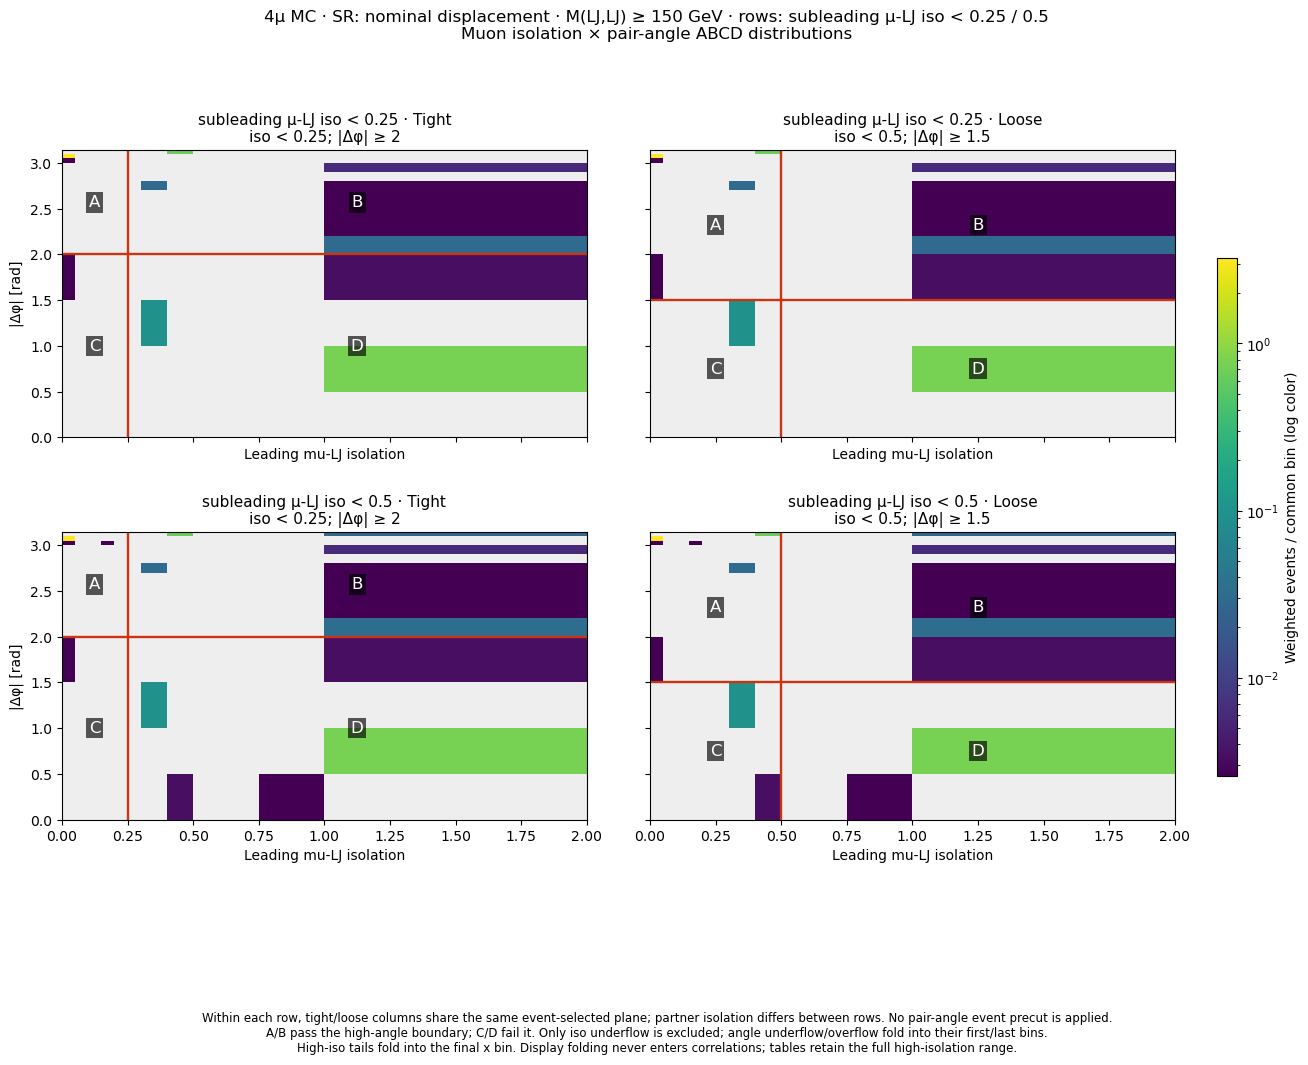

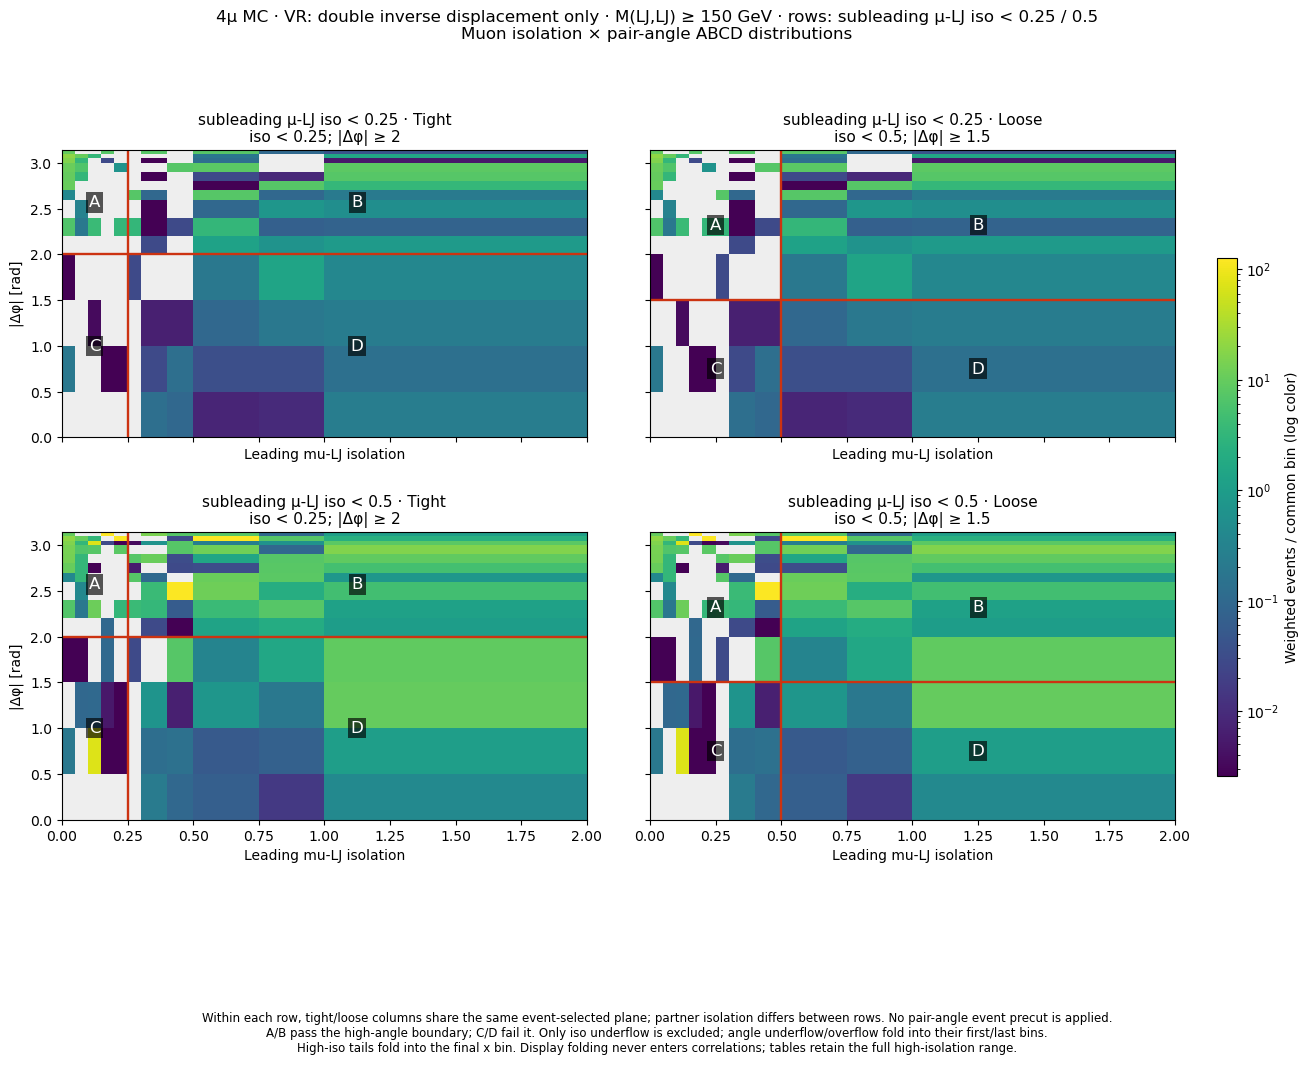

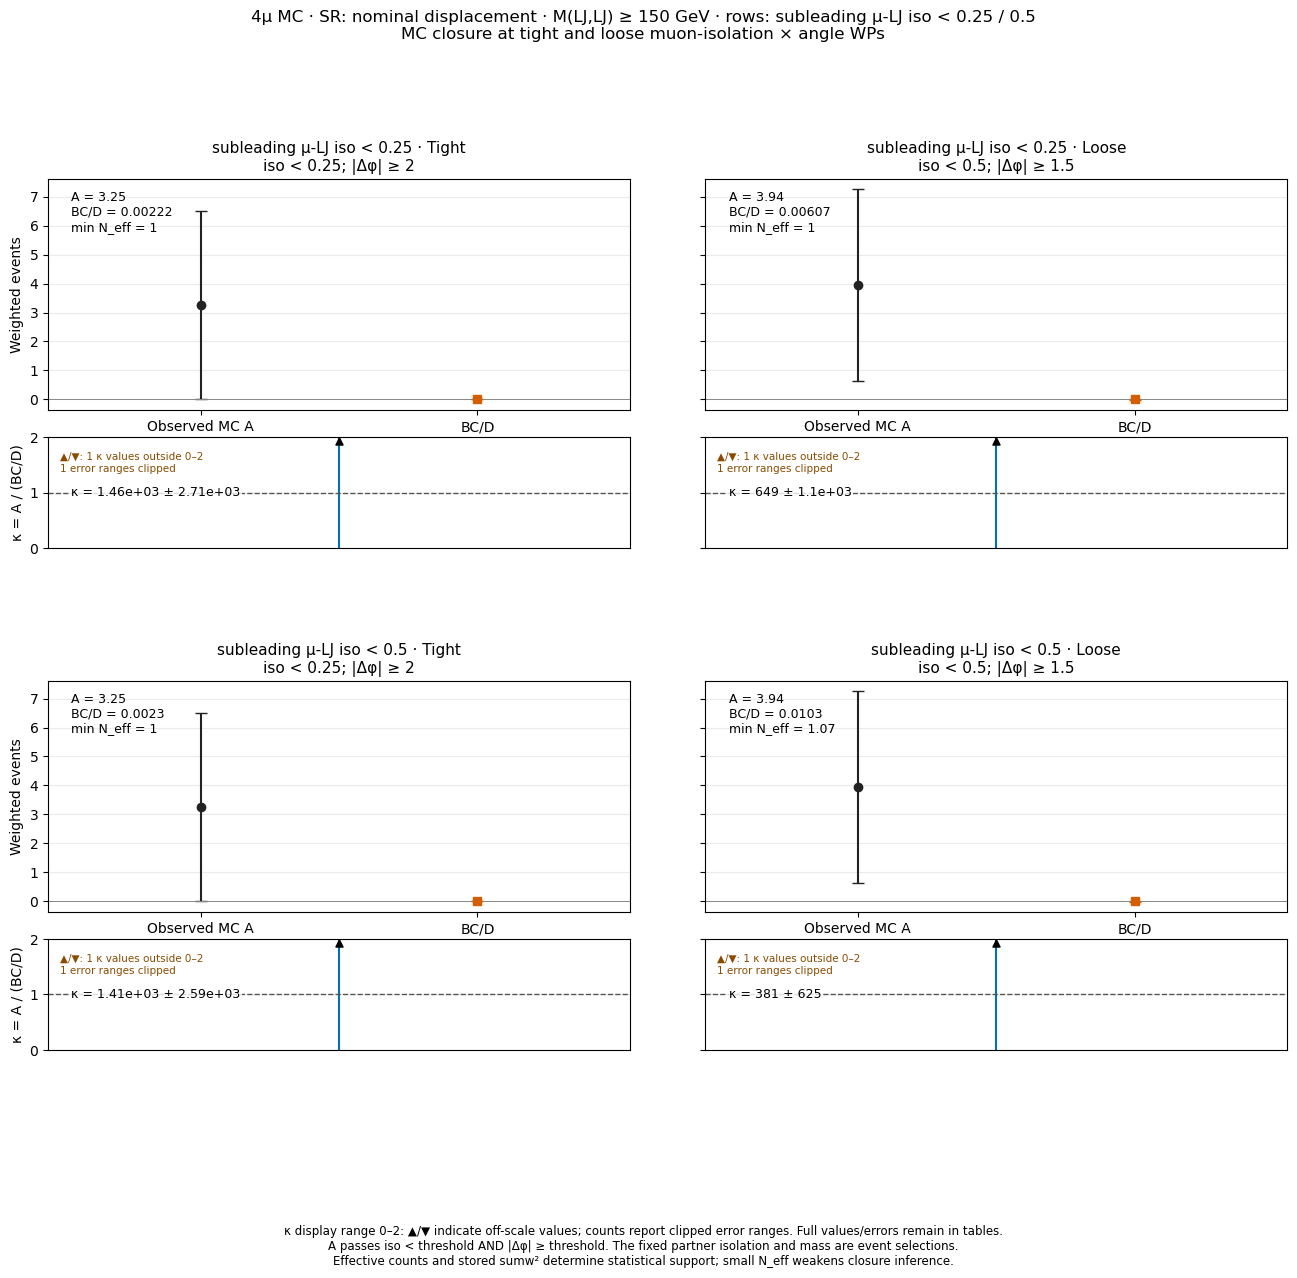

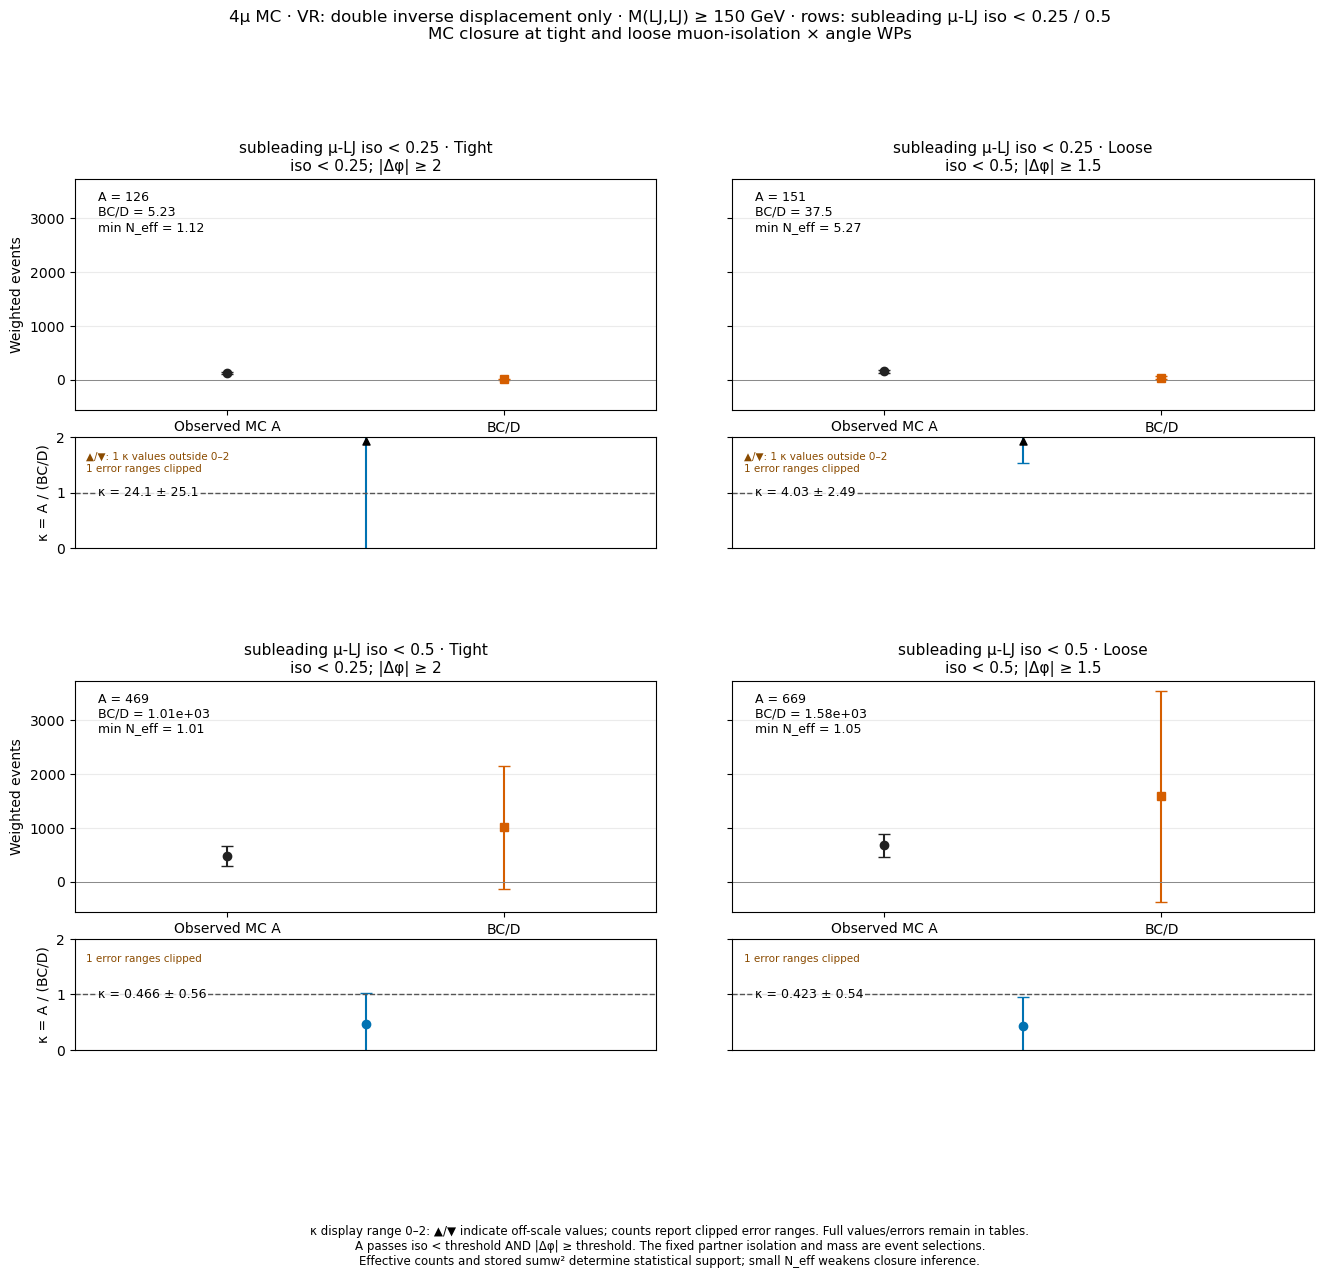

In [8]:
present_plane_figures(plot_plane_distributions(mc_results,CONFIG))
present_plane_figures(plot_plane_closure(mc_results,CONFIG))


## All 180 current signal points: pooled 2D shapes

Add a **pooled signal shape** using all 180 current signal samples, including both generated decay topologies. The existing golden legacy production contains 120 available models, so its pool uses those 120 and is labeled separately; old/current shape differences also reflect this grid-scope difference. Project every sample into the notebook's reconstructed topology and requested SR/VR/profile selection, sum the stored weighted bin contents first, then normalize the retained selected-plane sum to unit area for display. Do not normalize each sample separately before summation or apply another luminosity/cross-section factor. The inventory records the actual sample set, decay-topology balance, and retained weighted contributions for each source and profile.

This pool combines distinct physical hypotheses and is a visualization of the supplied signal library. It is **not a combined signal model**, an expected physical signal yield, or an input to S/B, leakage, WP selection, or the DATA gate. Those calculations continue to use the four displaced references individually. Differences between pooled shapes can reflect both event selection and the relative stored sample weights; state the source and sample inventory in the captions. Use the analysis's explicit flow policy for the normalization and fold bins for display only after forming the weighted pool.

Prompt-like samples may appear in this all-model visualization. They do not enter the four displaced-reference gate or its individual S/B/leakage diagnostics.

All-grid current signal shapes: 20/180, both partner profiles and generated topologies


All-grid current signal shapes: 40/180, both partner profiles and generated topologies


All-grid current signal shapes: 60/180, both partner profiles and generated topologies


All-grid current signal shapes: 80/180, both partner profiles and generated topologies


All-grid current signal shapes: 100/180, both partner profiles and generated topologies


All-grid current signal shapes: 120/180, both partner profiles and generated topologies


All-grid current signal shapes: 140/180, both partner profiles and generated topologies


All-grid current signal shapes: 160/180, both partner profiles and generated topologies


All-grid current signal shapes: 180/180, both partner profiles and generated topologies


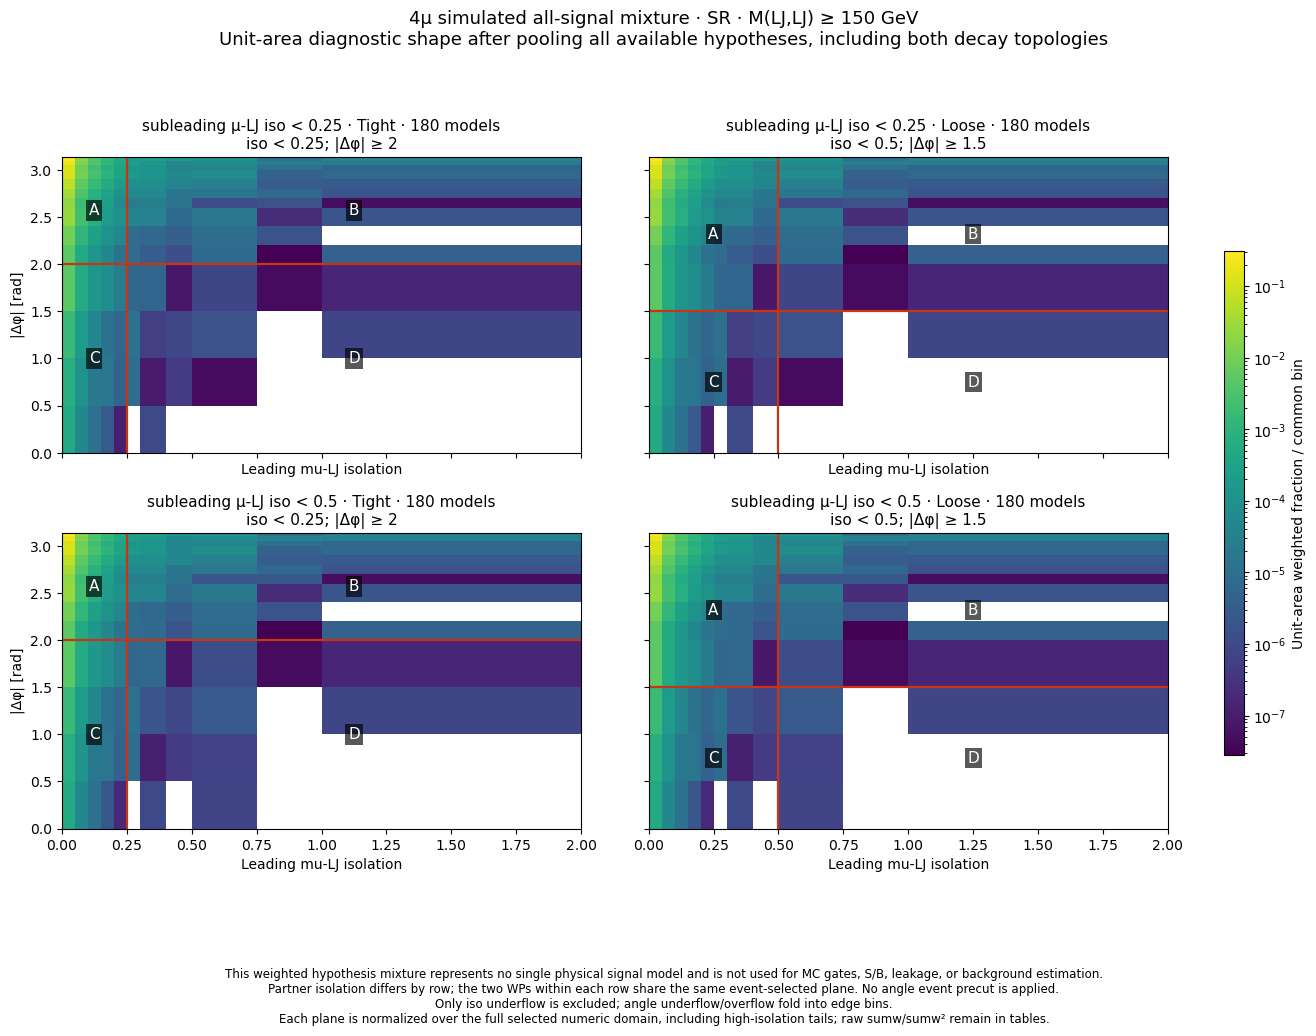

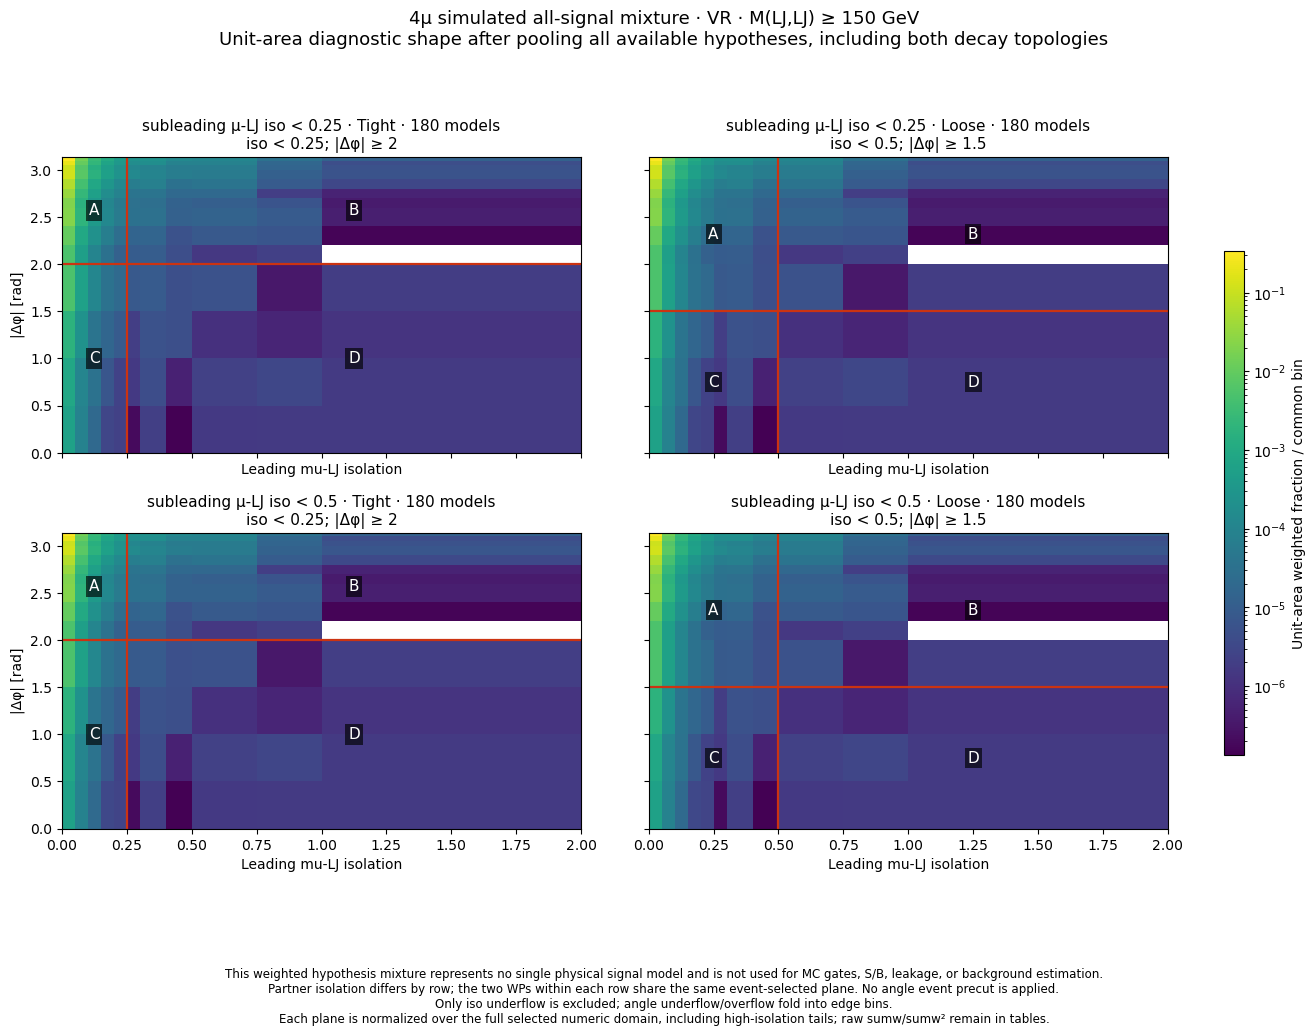

,benchmark,context,model_count,source,decay_topology_counts,bound_state_masses_GeV,raw_sumw,raw_sumw2,selected_sumw,selected_sumw2,...,unit_area_defined,normalization_status,xedges,yedges,display_normalization,flow_policy,purpose,partner_profile,partner_iso_max,column
0,p025_tight,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",502.900788,1.216130,502.004739,1.214140,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p025,0.25,tight
1,p025_tight,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",2067.782277,4.877859,2063.534218,4.868218,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p025,0.25,tight
2,p025_loose,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",502.900788,1.216130,502.004739,1.214140,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p025,0.25,loose
3,p025_loose,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",2067.782277,4.877859,2063.534218,4.868218,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p025,0.25,loose
4,p050_tight,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",508.944251,1.227834,508.038211,1.225821,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p050,0.50,tight
5,p050_tight,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",2084.080850,4.912119,2079.802197,4.902417,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p050,0.50,tight
6,p050_loose,SR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",508.944251,1.227834,508.038211,1.225821,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p050,0.50,loose
7,p050_loose,VR,180,current6d,2Mu2E:90;4Mu:90,"[100.0, 150.0, 200.0, 500.0, 800.0, 1000.0]",2084.080850,4.912119,2079.802197,4.902417,...,True,DEFINED,"[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0....","[0.0, 0.5, 1.0, 1.5, 2.0, 2.2, 2.4, 2.6, 2.7, ...",Plot layer normalizes the selected pooled nume...,Exclude muon-isolation underflow; retain isola...,Mixed-model diagnostic shape; not a gate model...,p050,0.50,loose


In [9]:
all_signal_shapes = aggregate_mu_phi_signal_shapes(CONFIG)
mc_results["tables"].update({"all_signal_"+name: frame for name,frame in all_signal_shapes["tables"].items()})
present_plane_figures(plot_mu_phi_all_signal_shapes(all_signal_shapes, CONFIG), source="MC")
display(all_signal_shapes["tables"]["summary"])


## 6. Correlation and two-dimensional κ

Report weighted bin-centre Pearson $\rho$ and effective statistics for **All/A/B/C/D**, separately in SR and VR. Use the current native regular isolation range [0, 5) and angular range [0, π), excluding both plane-axis flow bins. Show total background in the main panels and retain component results in the numerical table. A negative native bin, empty/nonpositive support, invalid moments, or zero axis spread makes the correlation undefined; keep the reason visible rather than clipping signed bins into a probability distribution.

Within each partner-isolation row, the two columns have identical All correlations because they use the same plane; A/B/C/D correlations can change with the boundaries. Native bin-centre Pearson is a diagnostic approximation. Weak full-plane correlation alone does not establish ABCD closure. DATA correlations are shown only for a comparison WP permitted by the MC SR-leakage gate.

Scan the two plane boundaries at exact stored edges and retain the full numerical $\kappa$ grid. Within each partner-isolation row, the two columns share the same grid and highlight their different comparison WPs; the grids can differ between rows. Use the reference blue–grey–red colour convention with $\kappa=1$ at the grey centre and colour limits −3/+3. Every finite cell displays its actual value, including values outside those colour limits. Undefined and gate-blocked DATA cells remain blank, while uncertainties and statistical support remain in the tables.

No point is retained or chosen because its $\kappa$ happens to be close to one. Low/high directions stay fixed across the grid: A always means low iso/high |Δφ|. The moving thresholds partition the full selected plane, including the appropriate angular pass/fail sides.

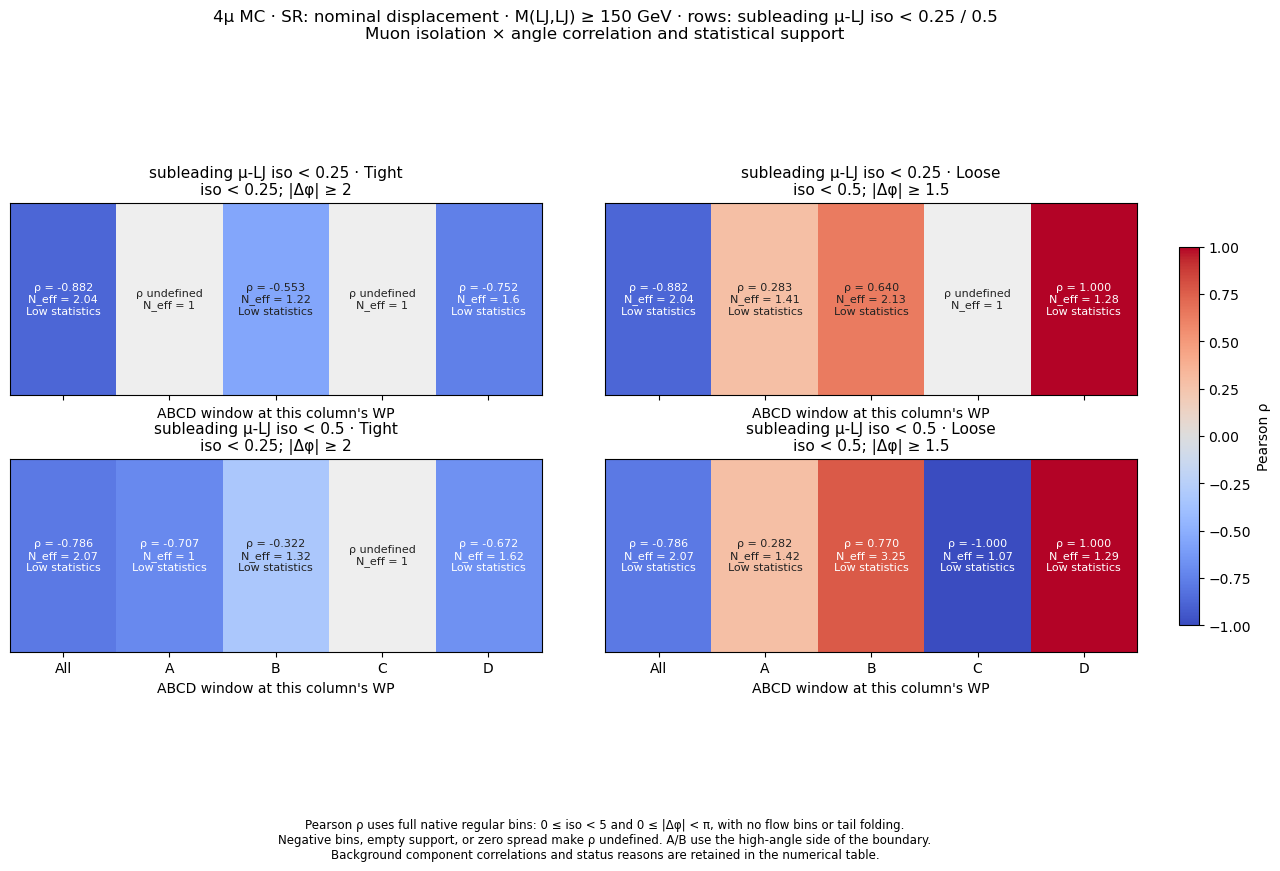

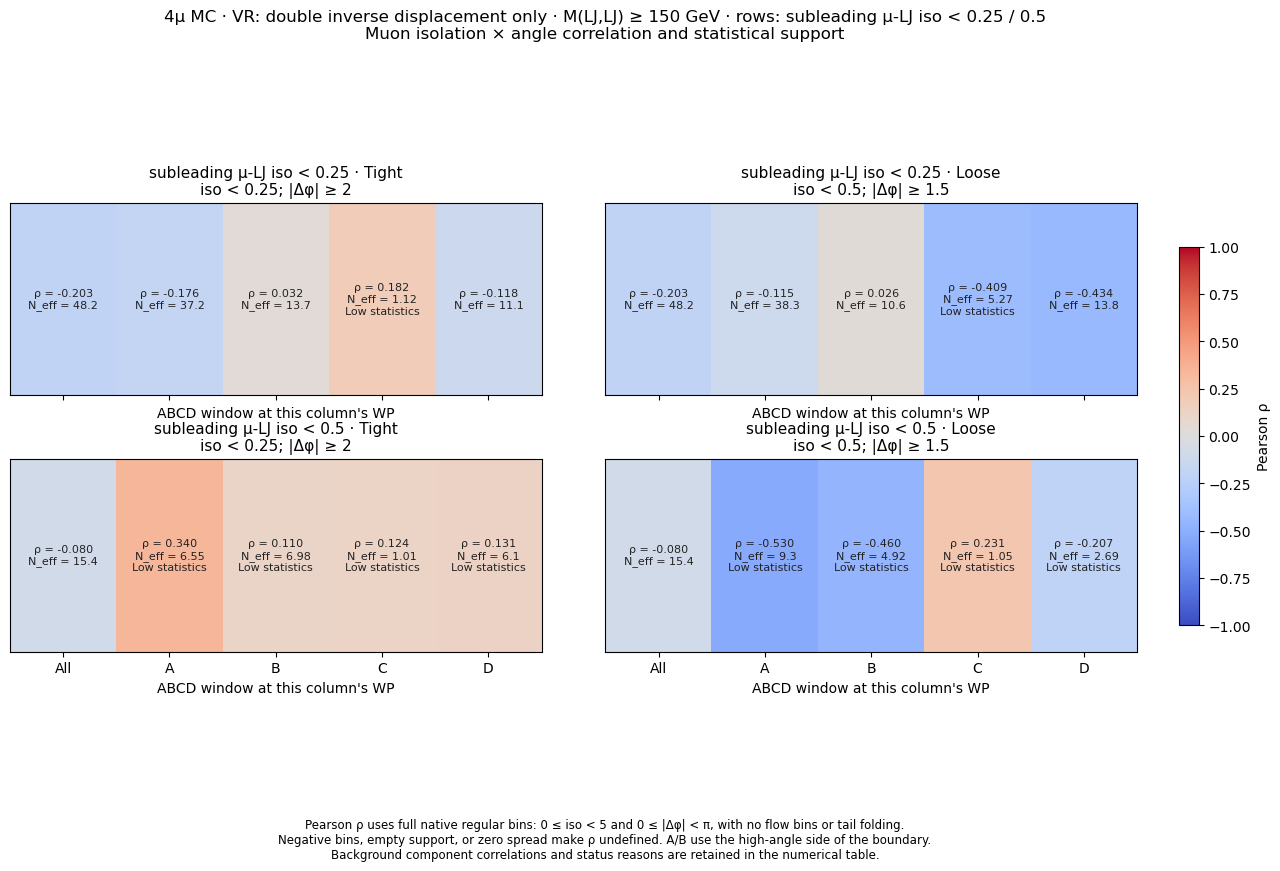

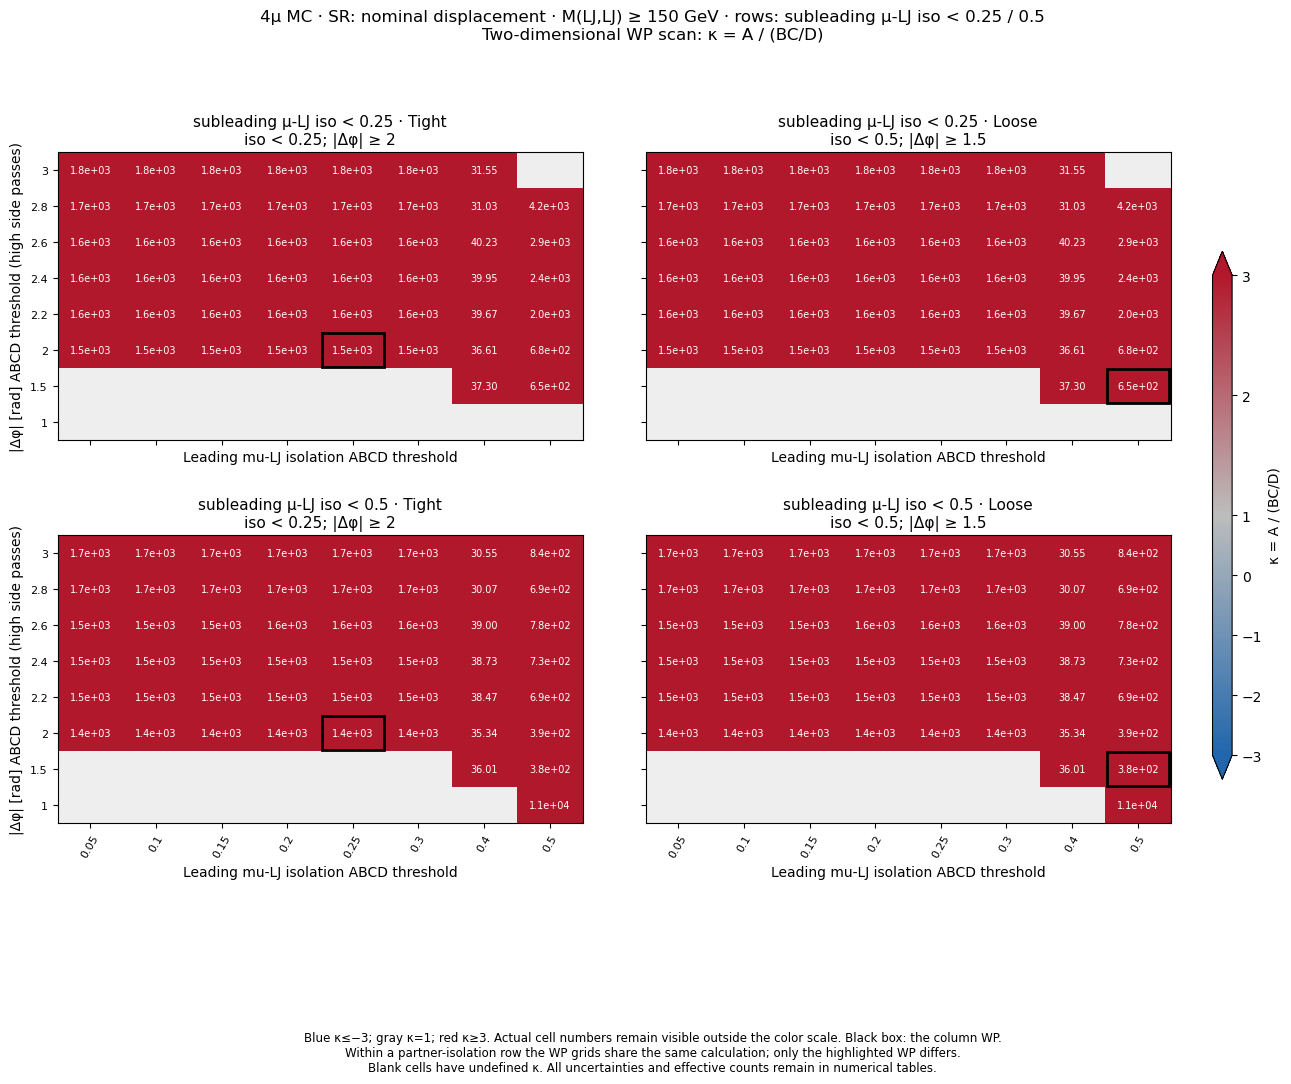

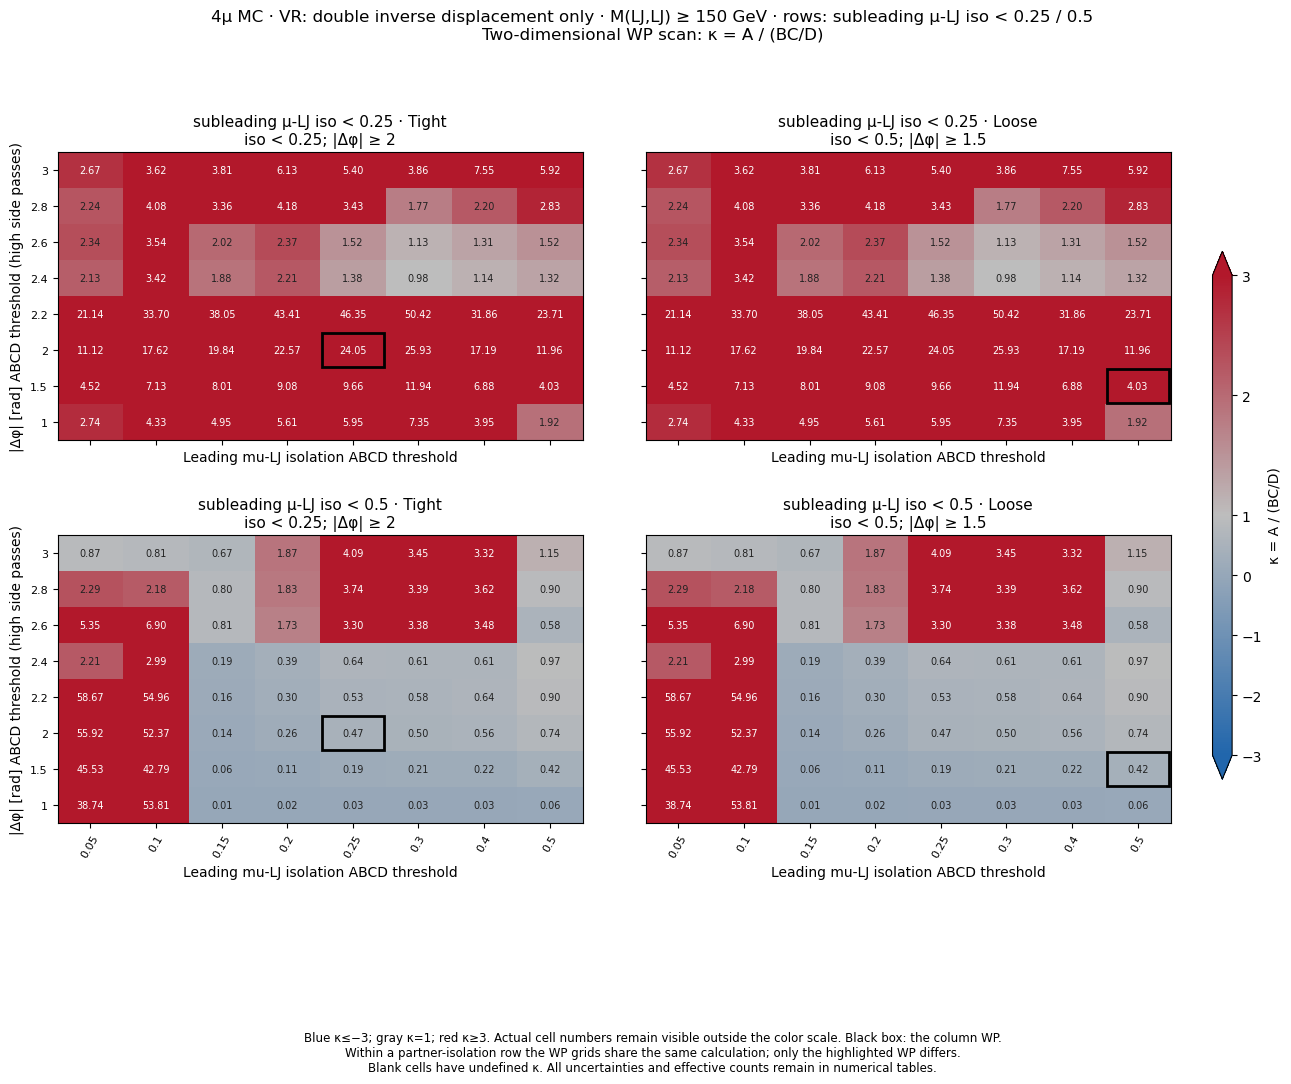

,benchmark,context,component,tx,ty,region,correlation,rho,neff,status,sumw,sumw2,negative_bins,native_negative_bins,display_binning,support,partner_profile,profile,partner_iso_max,column
0,p025_tight,SR,Total,0.25,2.0,All,-0.882417,-0.882417,2.040304,LOW_STAT,4.830600,11.436872,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p025,p025,0.25,tight
1,p025_tight,SR,Total,0.25,2.0,A,NaN,NaN,1.001583,NO_SPREAD,3.250611,10.549767,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p025,p025,0.25,tight
2,p025_tight,SR,Total,0.25,2.0,B,-0.552575,-0.552575,1.217090,LOW_STAT,0.728170,0.435655,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p025,p025,0.25,tight
3,p025_tight,SR,Total,0.25,2.0,C,NaN,NaN,1.000000,NO_SPREAD,0.002571,0.000007,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p025,p025,0.25,tight
4,p025_tight,SR,Total,0.25,2.0,D,-0.752205,-0.752205,1.597593,LOW_STAT,0.849248,0.451443,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p025,p025,0.25,tight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,p050_loose,VR,Diboson,0.50,1.5,All,-0.161244,-0.161244,11.994408,OK,2.391106,0.476671,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p050,p050,0.50,loose
196,p050_loose,VR,Diboson,0.50,1.5,A,-0.742015,-0.742015,10.994590,OK,2.194331,0.437951,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p050,p050,0.50,loose
197,p050_loose,VR,Diboson,0.50,1.5,B,NaN,NaN,NaN,EMPTY,0.000000,0.000000,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p050,p050,0.50,loose
198,p050_loose,VR,Diboson,0.50,1.5,C,-1.000000,-1.000000,1.000000,LOW_STAT,0.196775,0.038720,0,0,"{""xedges"": [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0...",Native regular-bin support only; both plane fl...,p050,p050,0.50,loose


In [10]:
present_plane_figures(plot_plane_correlations(mc_results,CONFIG))
present_plane_figures(plot_plane_kappa_grid(mc_results,CONFIG))
display(tables["correlation_summary"])


## 7. Native one-axis scans and four displaced signals

Show both native one-axis scans. For the isolation scan, hold the **angular ABCD boundary** at 2.0 in the tight column and 1.5 in the loose column. For the angular scan, hold the **isolation ABCD boundary** at 0.25 and 0.50, respectively. These fixed plane boundaries do not discard the other side of the axis. The partner event cut is held at its row value, iso1<0.25 or iso1<0.50.

Display the isolation scan through 1.0 and the angular scan over 0–π using native stored thresholds, without interpolation. Show observed A and BC/D in the top panel, $\kappa$ in the middle, and the four individual displaced-reference S/B and leakage curves below. The $\kappa$ range is 0–2. SR yield displays use 0–100 events for 2μ2e and 0–10 for 4μ; series-coloured off-scale markers and clipped-error counts preserve visibility of extreme values without changing the calculation. Keep effective statistics in the separate tables/figures.

Retain original numerical values outside display limits. DATA NaN gaps remain gaps in every curve; do not connect neighboring permitted points through a blocked boundary. Overlapping scan points are not independent measurements.

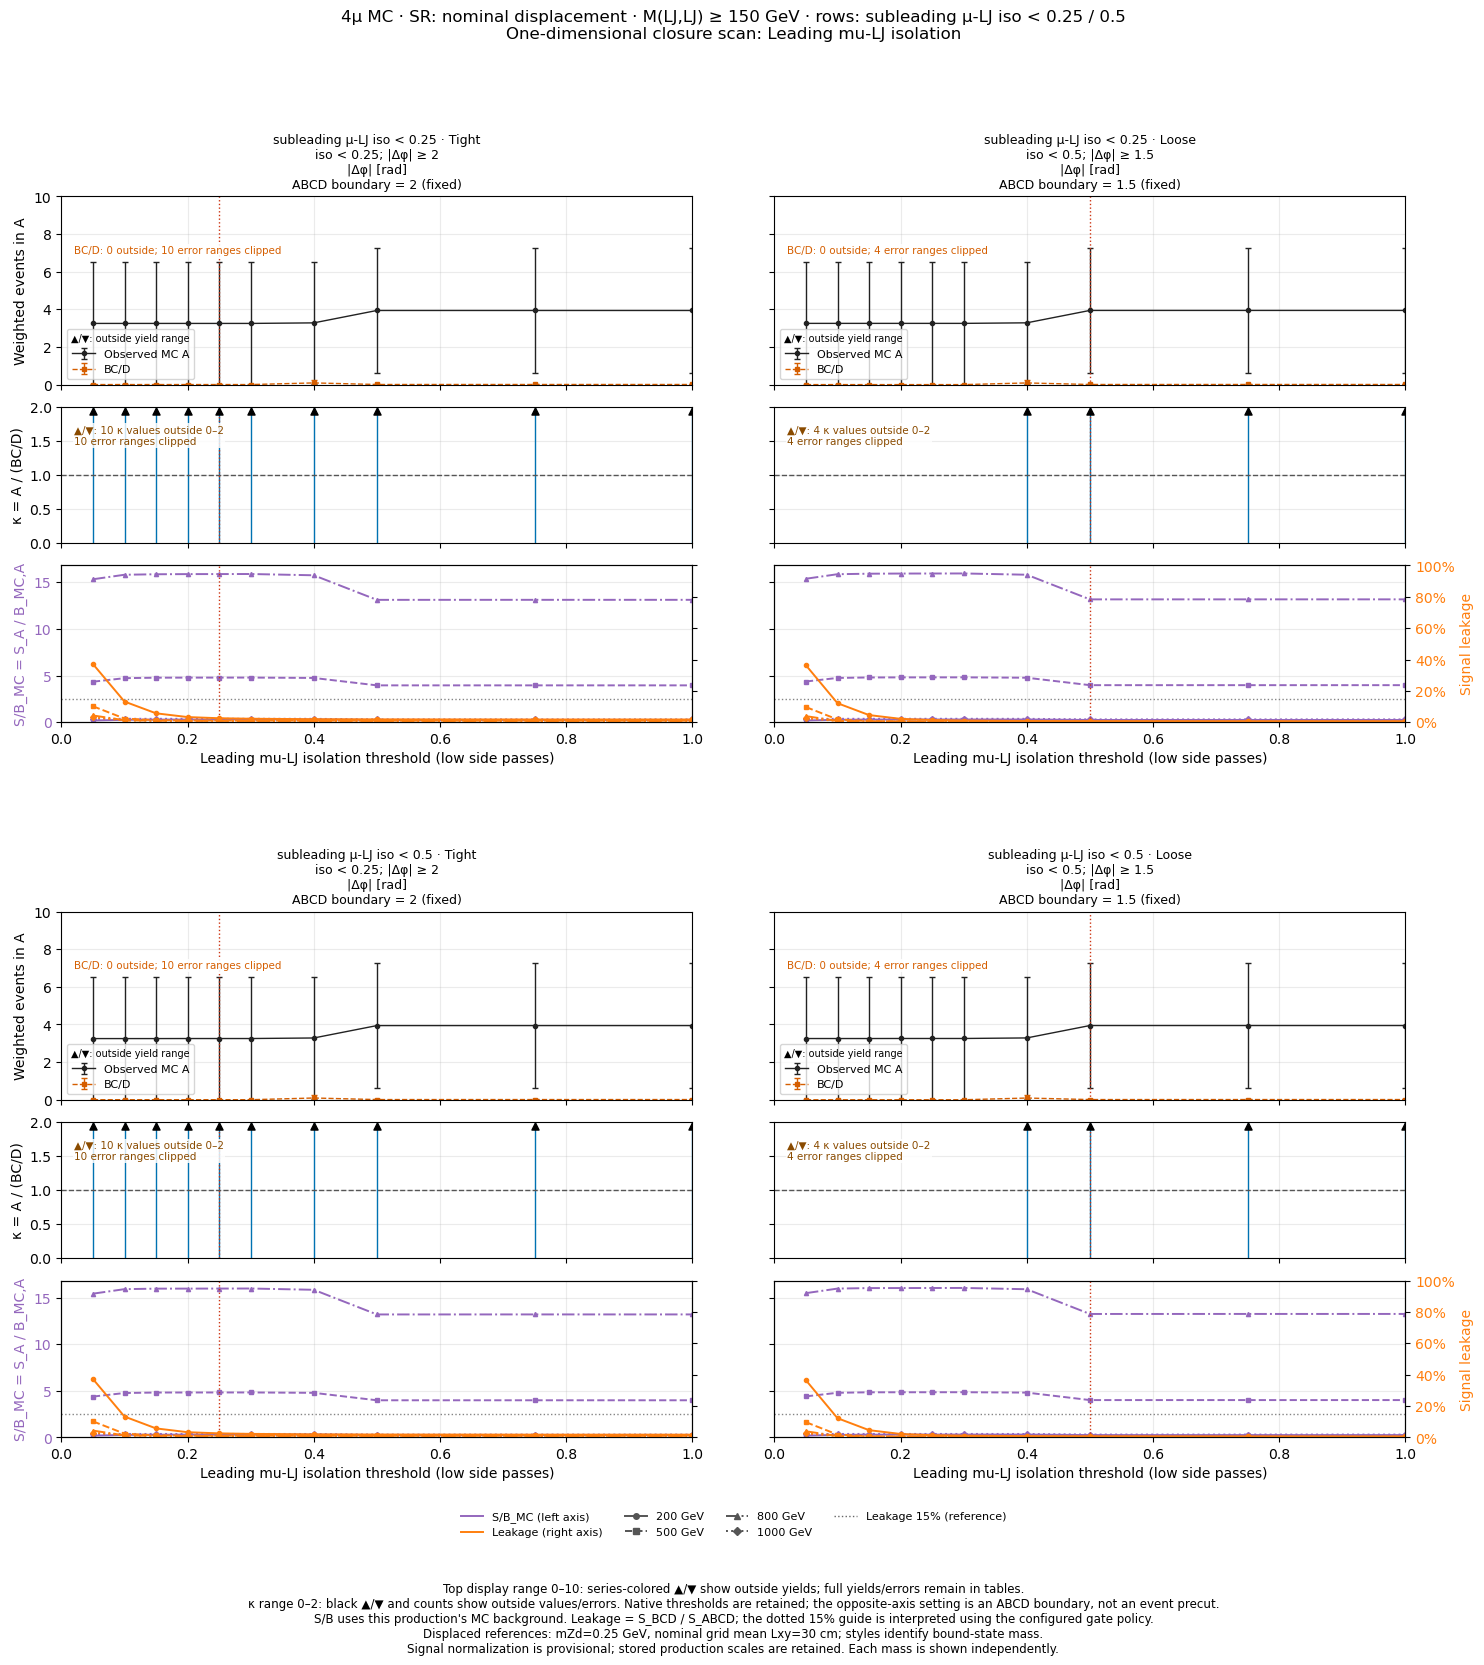

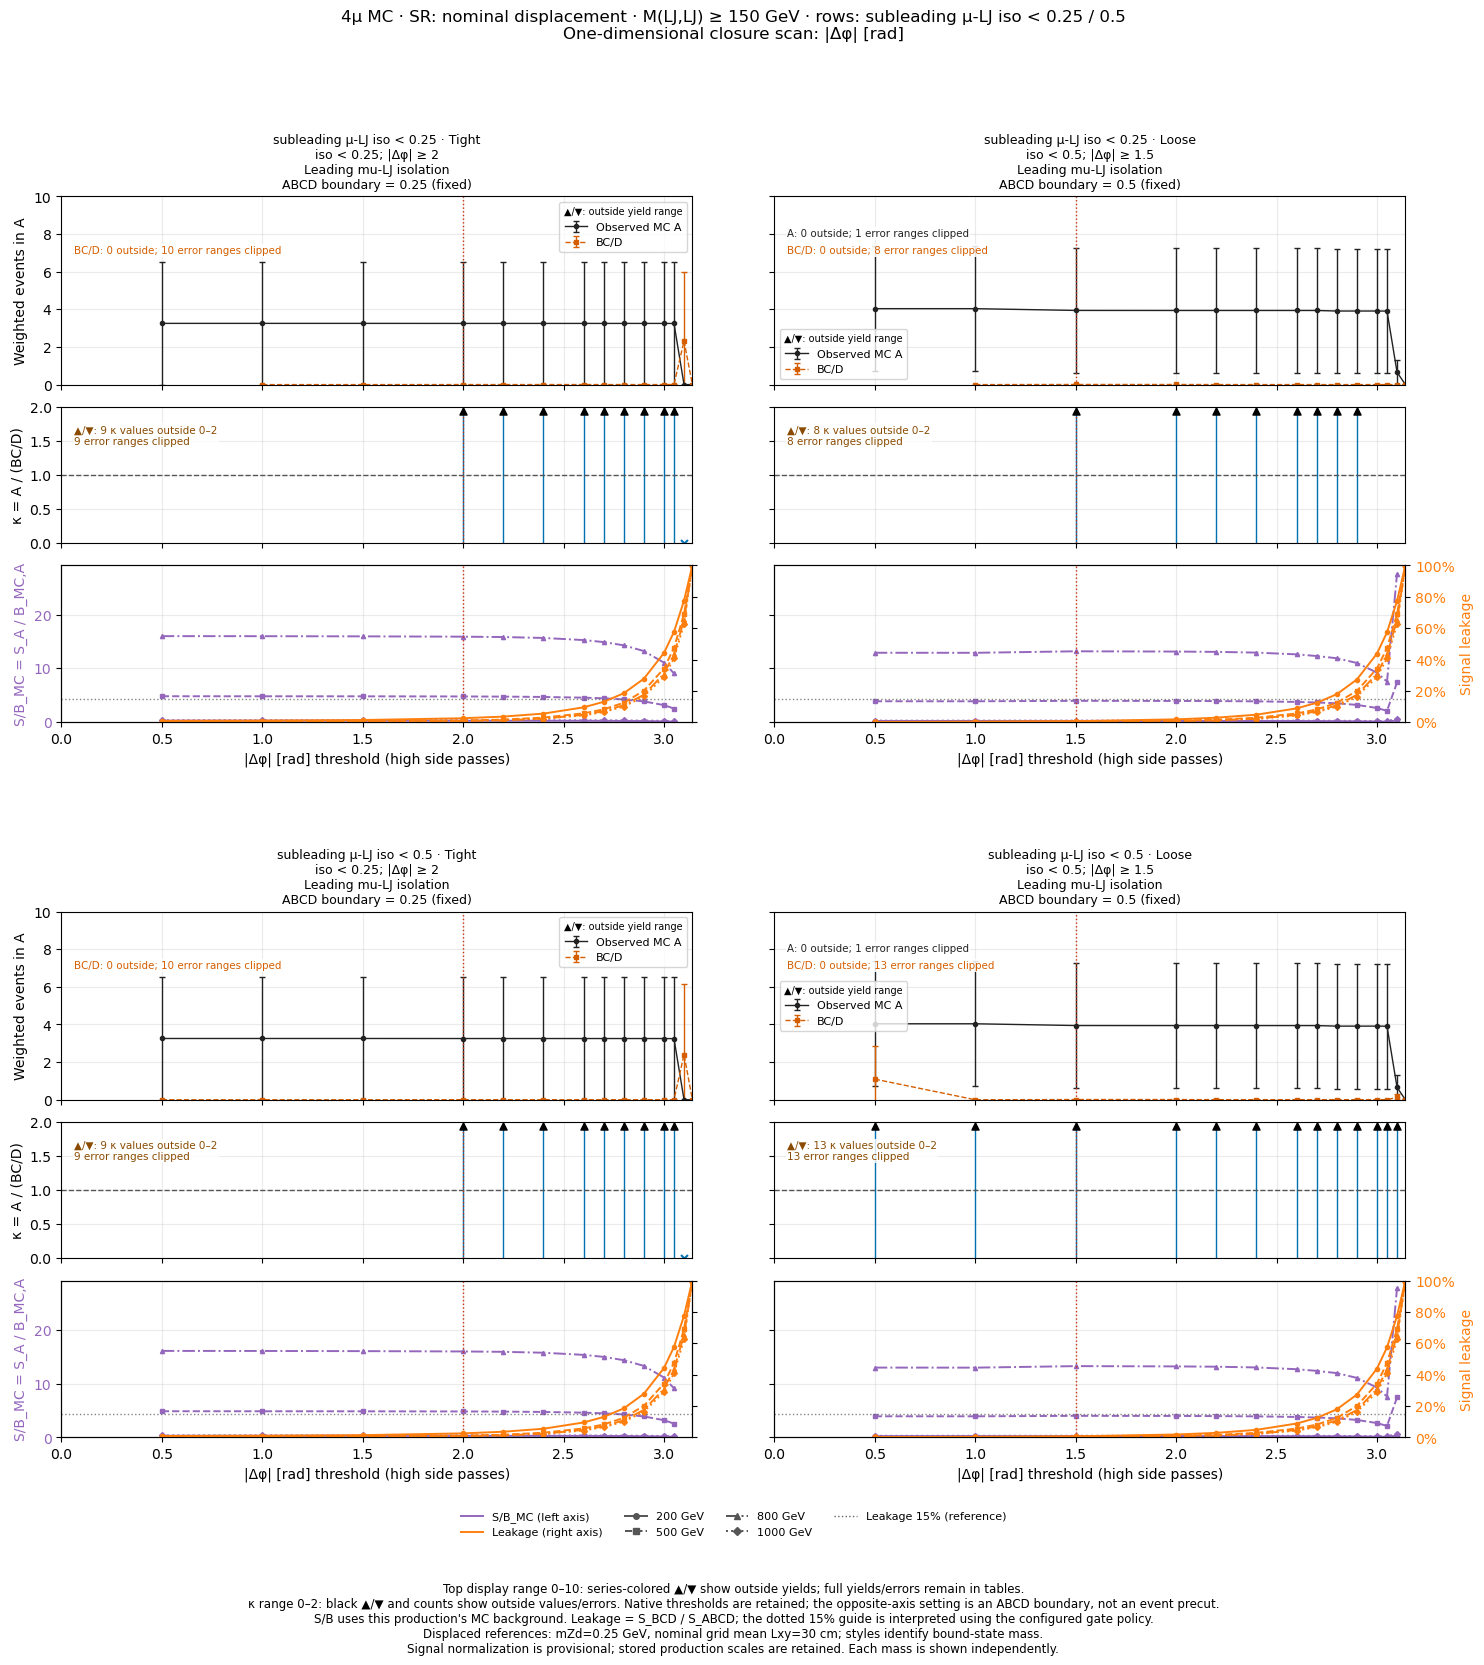

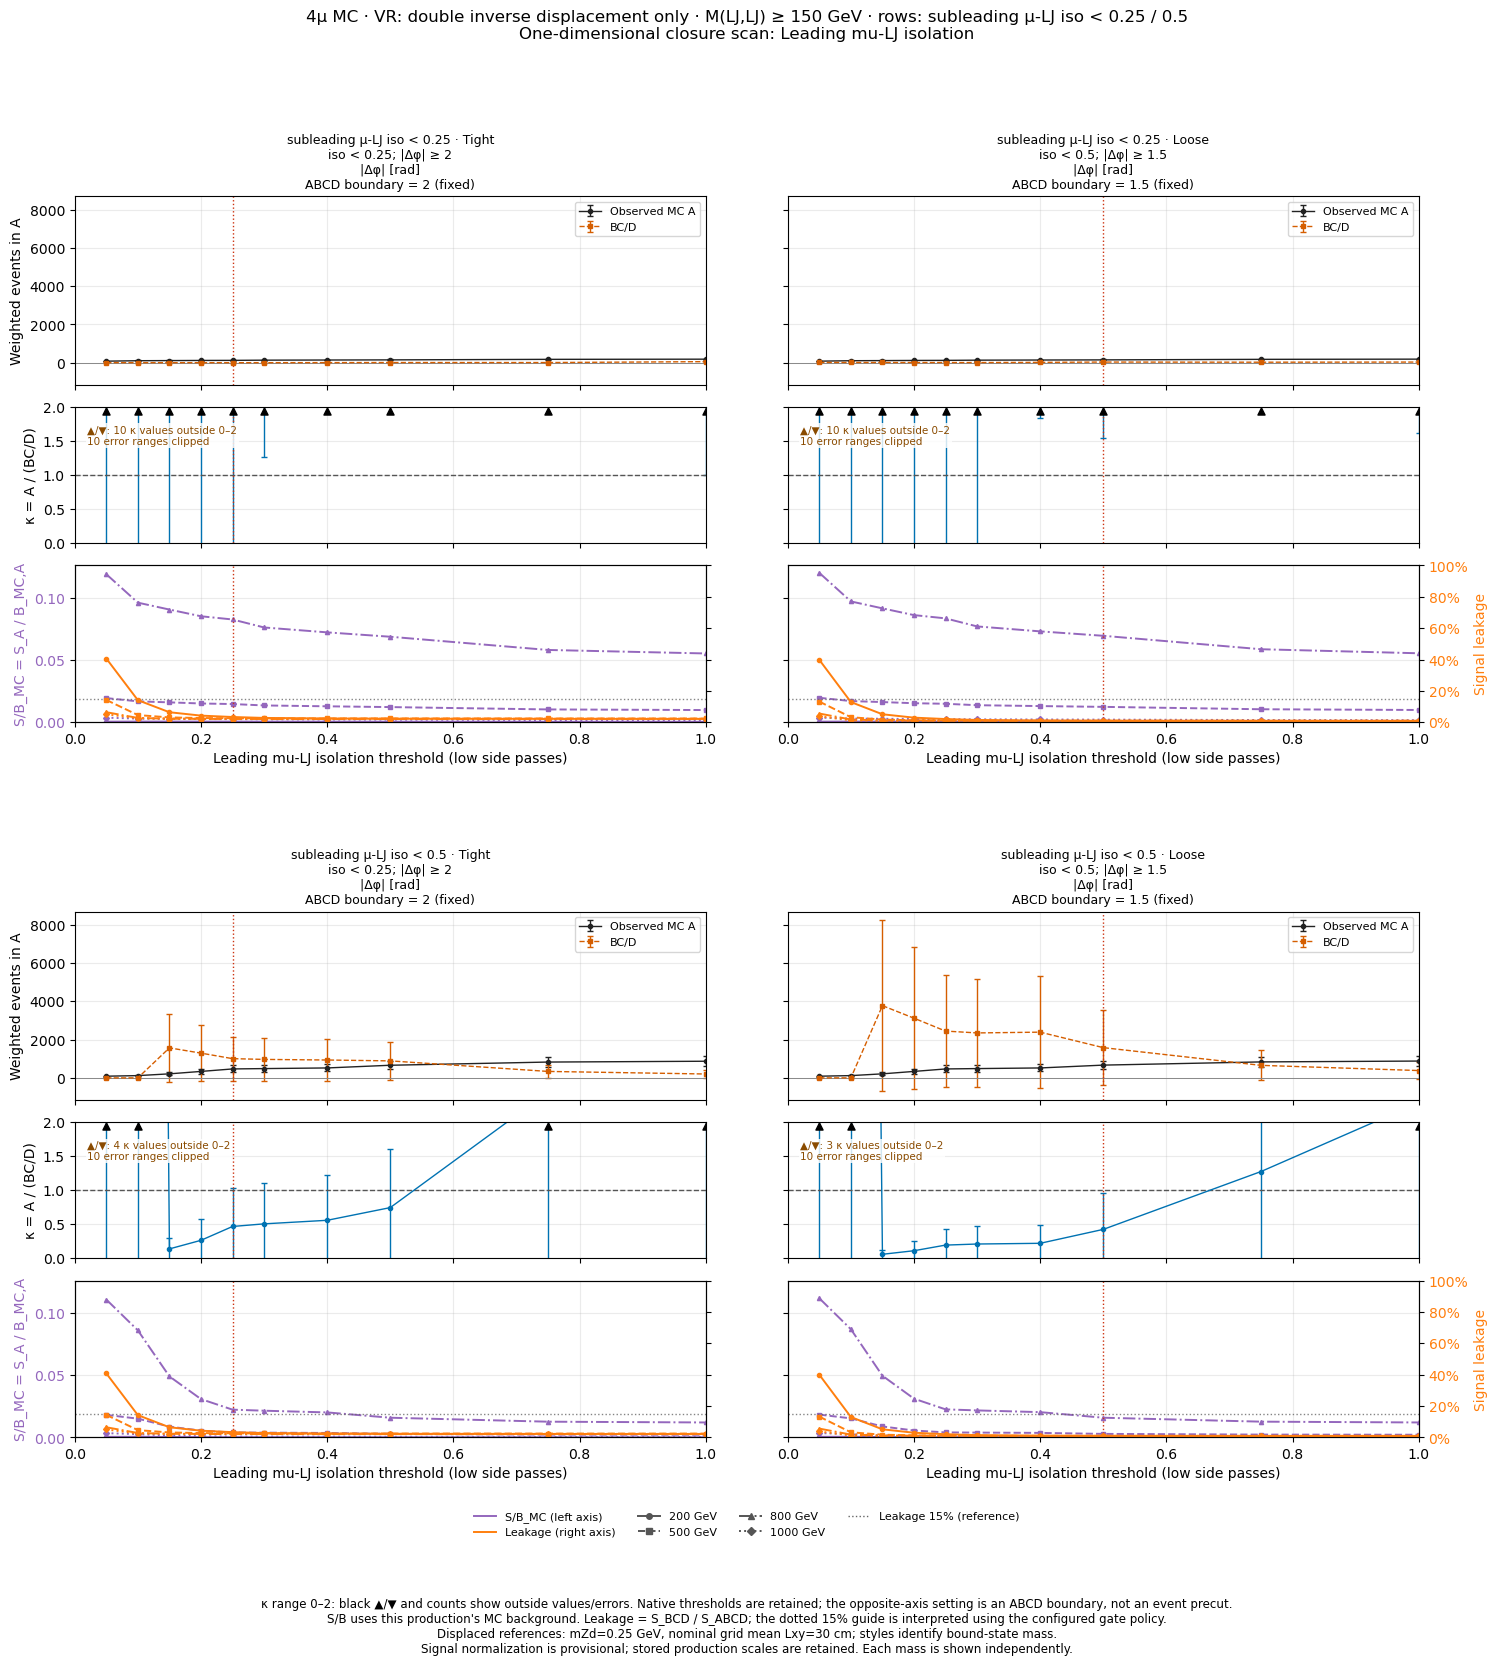

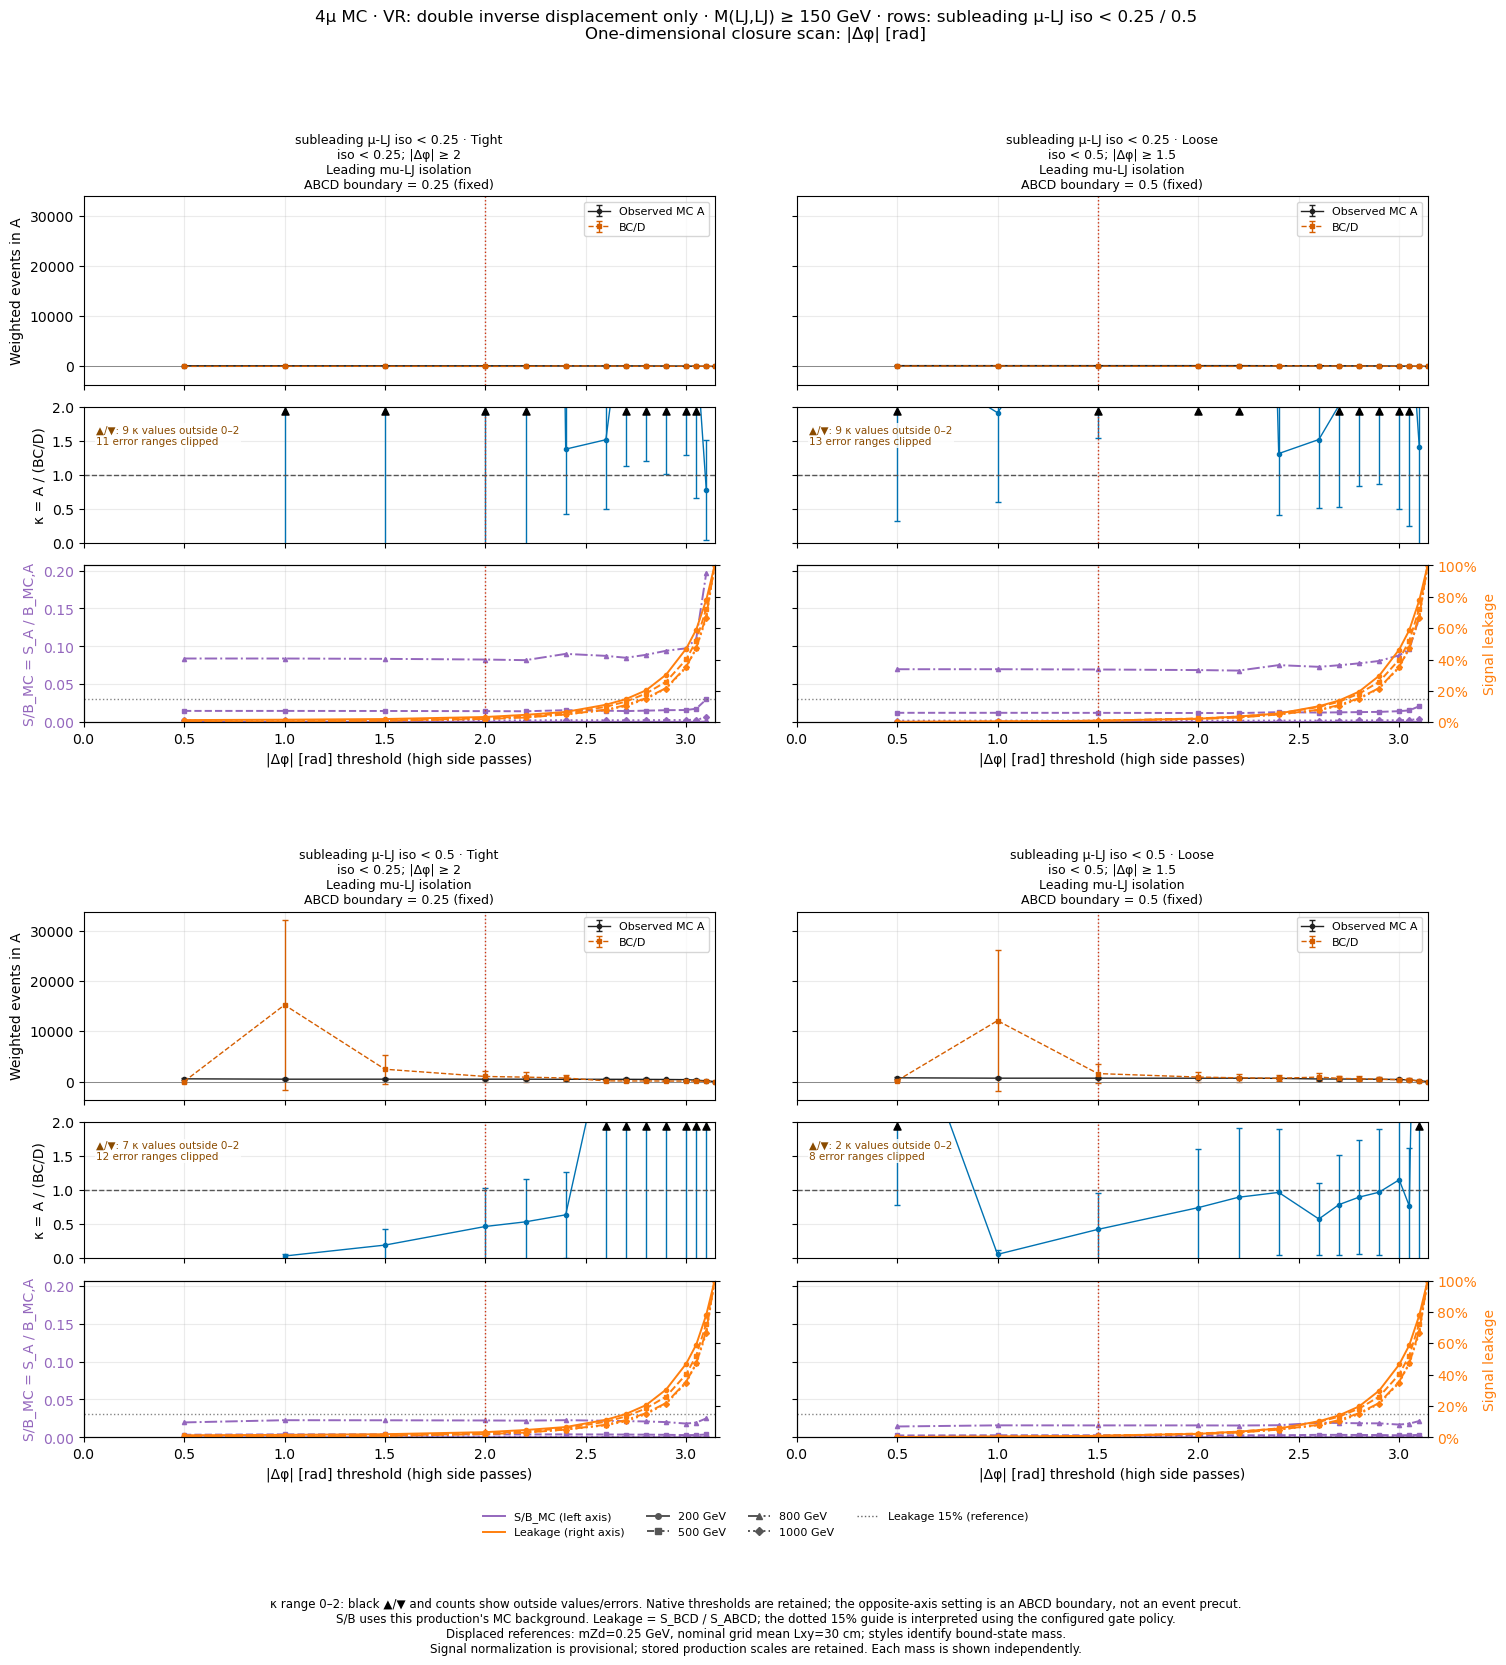

,benchmark,context,reference_role,role,sample,mA_GeV,mZd_GeV,ctau_mm,reference_kind,avg_transverse_cm,...,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,partner_profile,profile,partner_iso_max,column
0,p025_tight,SR,mA200,mA200,4Mu_200GeV_0p25GeV_1p0mm,200.0,0.25,1.00,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
1,p025_tight,SR,mA500,mA500,4Mu_500GeV_0p25GeV_0p4mm,500.0,0.25,0.40,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
2,p025_tight,SR,mA800,mA800,4Mu_800GeV_0p25GeV_0p25mm,800.0,0.25,0.25,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
3,p025_tight,SR,mA1000,mA1000,4Mu_1000GeV_0p25GeV_0p2mm,1000.0,0.25,0.20,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
4,p025_tight,VR,mA200,mA200,4Mu_200GeV_0p25GeV_1p0mm,200.0,0.25,1.00,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
5,p025_tight,VR,mA500,mA500,4Mu_500GeV_0p25GeV_0p4mm,500.0,0.25,0.40,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
6,p025_tight,VR,mA800,mA800,4Mu_800GeV_0p25GeV_0p25mm,800.0,0.25,0.25,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
7,p025_tight,VR,mA1000,mA1000,4Mu_1000GeV_0p25GeV_0p2mm,1000.0,0.25,0.20,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight
8,p025_loose,SR,mA200,mA200,4Mu_200GeV_0p25GeV_1p0mm,200.0,0.25,1.00,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,loose
9,p025_loose,SR,mA500,mA500,4Mu_500GeV_0p25GeV_0p4mm,500.0,0.25,0.40,displaced,30.0,...,Hypothetical contamination diagnostic only; no...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,loose


In [11]:
present_plane_figures(plot_plane_one_d(mc_results,CONFIG))
display(tables["signal_diagnostics"])


## 8. Background composition and statistics

Retain process A/B/C/D yields and effective counts separately from the signal panel. Statistics and first-order uncertainty limitations remain visible in the tables.

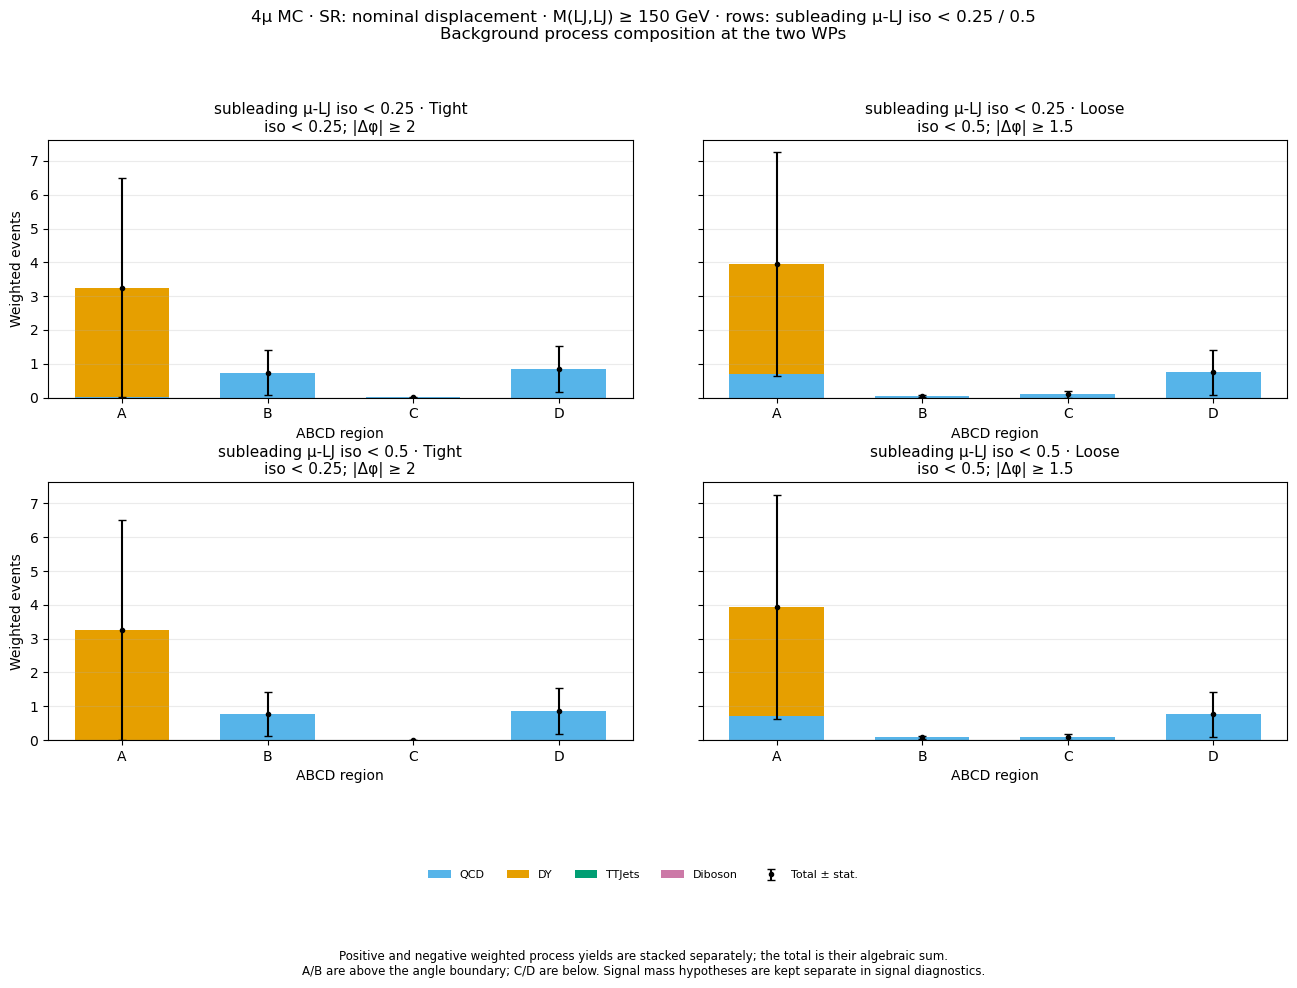

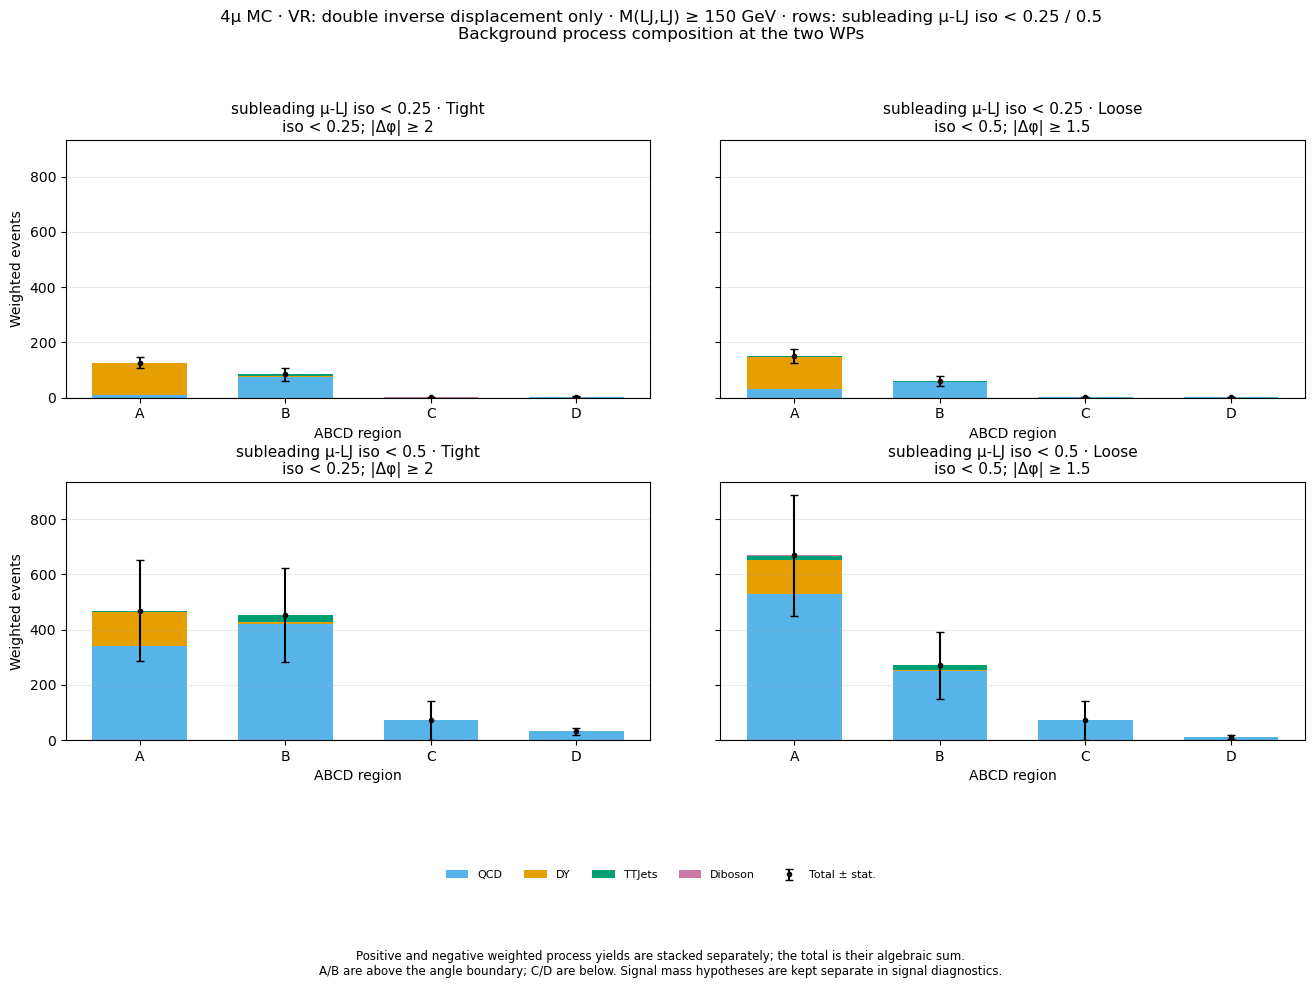

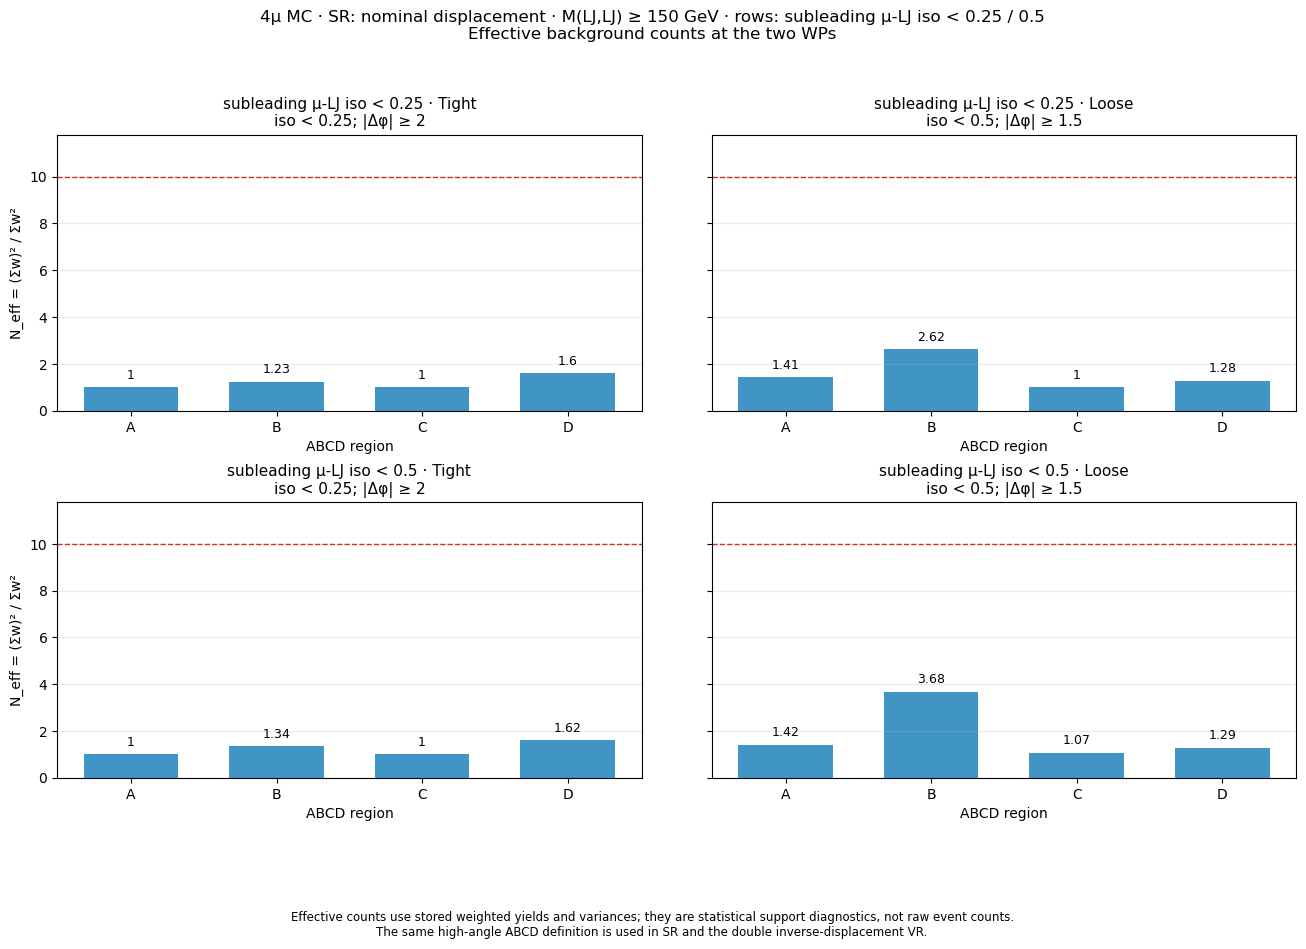

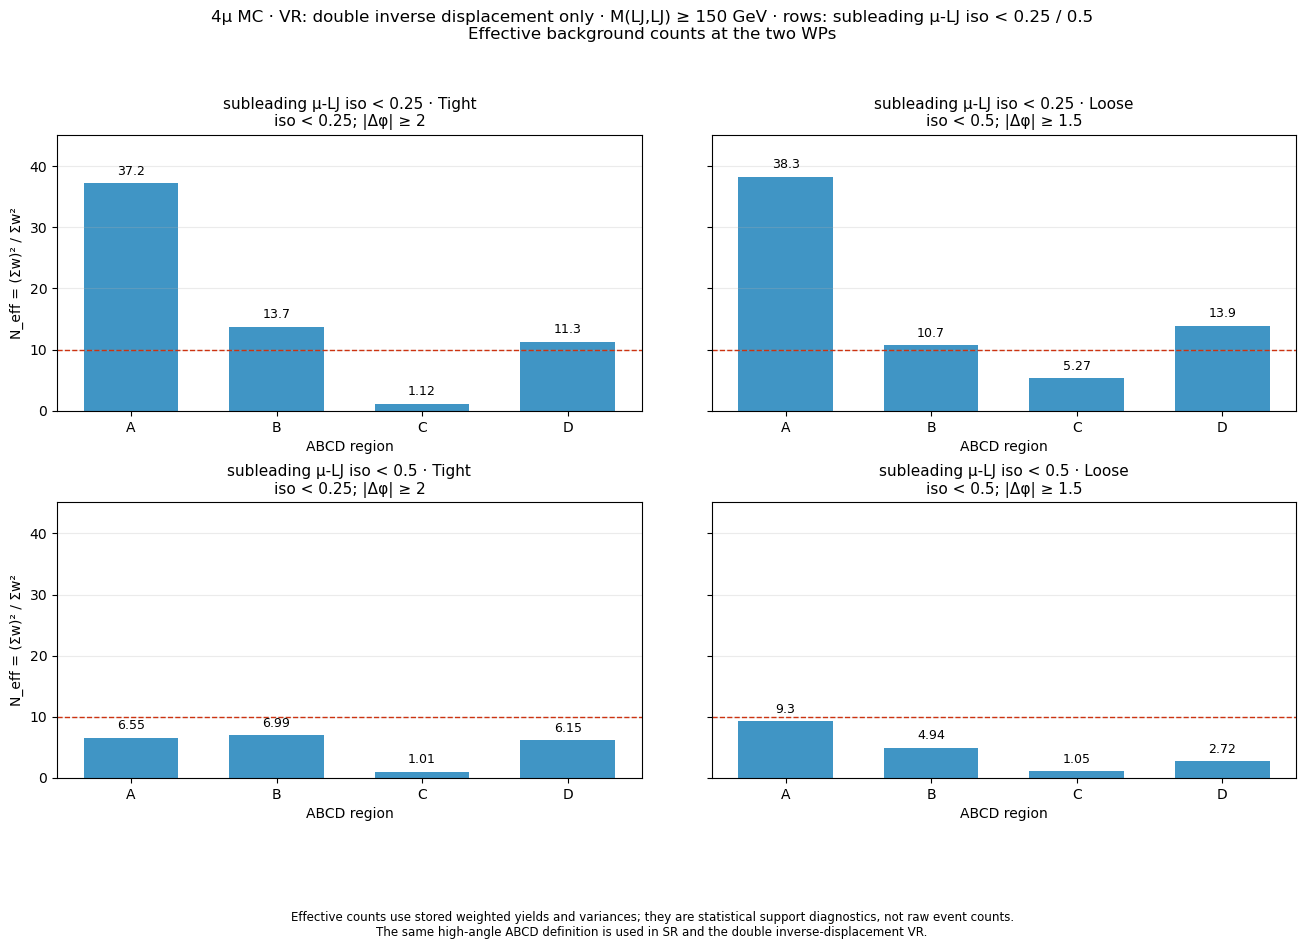

,benchmark,context,component,region,yield,variance,error,neff,partner_profile,profile,partner_iso_max,column
0,p025_tight,SR,Total,A,3.250611,10.549767,3.248041,1.001583,p025,p025,0.25,tight
1,p025_tight,SR,Total,B,0.733312,0.435668,0.660051,1.234302,p025,p025,0.25,tight
2,p025_tight,SR,Total,C,0.002571,0.000007,0.002571,1.000000,p025,p025,0.25,tight
3,p025_tight,SR,Total,D,0.849248,0.451443,0.671895,1.597593,p025,p025,0.25,tight
4,p025_tight,SR,QCD,A,0.002571,0.000007,0.002571,1.000000,p025,p025,0.25,tight
...,...,...,...,...,...,...,...,...,...,...,...,...
155,p050_loose,VR,TTJets,D,0.000000,0.000000,0.000000,NaN,p050,p050,0.50,loose
156,p050_loose,VR,Diboson,A,2.194331,0.437951,0.661778,10.994590,p050,p050,0.50,loose
157,p050_loose,VR,Diboson,B,0.000000,0.000000,0.000000,NaN,p050,p050,0.50,loose
158,p050_loose,VR,Diboson,C,0.196775,0.038720,0.196775,1.000000,p050,p050,0.50,loose


In [12]:
present_plane_figures(plot_plane_composition(mc_results,CONFIG))
present_plane_figures(plot_plane_neff(mc_results,CONFIG))
display(tables["region_yields"])


## Conditional inverse-displacement DATA VR

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


The current **configured criterion** is leakage-only: every one of the four displaced references must have SR leakage S_BCD/S_ABCD **strictly below 15%**; equality fails. Contamination and VR leakage remain diagnostics. Record the active mode, threshold, and contexts with each result. In **contamination** mode, every reference must satisfy S/(S+B_MC)≤10% in SR MC B/C/D and VR MC A/B/C/D. In **leakage** mode, require the strict leakage bound in each configured context. In **both** mode, both requirements must pass. Leakage contexts can be SR only or SR+VR. These are distinct tests and are not interchangeable.

Evaluate every hypothesis independently before opening DATA; do not sum references or use the pooled shape. Undefined/negative signal inputs or a nonpositive signal total make leakage unsupported. In leakage-only mode, a nonpositive MC background is a contamination diagnostic and does not independently veto a supported signal-leakage test. The criterion audit marks the active leakage requirements separately from inactive contamination rows and reports failure reasons and the limiting reference/context. DATA remains VR only, with failed points kept as NaN and the same masks on all curves. The selected four references have provisional normalization and do not establish safety for the full signal grid.

In [13]:
data_results = run_plane_data(mc_results,dict(CONFIG,run_data=RUN_DATA))
data_tables = data_results["tables"]
DATA_CONFIG = dict(CONFIG,source_label="DATA")
with pd.option_context("display.max_columns",None,"display.max_colwidth",100):
    for name in ("data_access","closure_summary","data_scan_status"):
        if name in data_tables:
            display(data_tables[name])


Current DATA VR: 20/68 after the four-reference MC gate


Current DATA VR: 40/68 after the four-reference MC gate


Current DATA VR: 60/68 after the four-reference MC gate


Current DATA VR: 68/68 after the four-reference MC gate
DATA VR scan p025_tight/x: 10 native points; {'AVAILABLE': 7, 'AVAILABLE_LOW_STAT': 2, 'GATE_BLOCKED': 1}
DATA VR scan p025_tight/y: 14 native points; {'GATE_BLOCKED': 6, 'AVAILABLE': 5, 'AVAILABLE_LOW_STAT': 3}
DATA VR scan p025_loose/x: 10 native points; {'AVAILABLE_LOW_STAT': 8, 'GATE_BLOCKED': 1, 'AVAILABLE': 1}
DATA VR scan p025_loose/y: 14 native points; {'GATE_BLOCKED': 6, 'AVAILABLE': 5, 'AVAILABLE_LOW_STAT': 3}
DATA VR scan p050_tight/x: 10 native points; {'AVAILABLE': 9, 'GATE_BLOCKED': 1}
DATA VR scan p050_tight/y: 14 native points; {'AVAILABLE': 6, 'GATE_BLOCKED': 6, 'AVAILABLE_LOW_STAT': 2}
DATA VR scan p050_loose/x: 10 native points; {'AVAILABLE': 7, 'AVAILABLE_LOW_STAT': 2, 'GATE_BLOCKED': 1}
DATA VR scan p050_loose/y: 14 native points; {'AVAILABLE': 6, 'GATE_BLOCKED': 6, 'AVAILABLE_LOW_STAT': 2}


,source,data_payloads_opened,approved_points,data_context,permitted_partner_profiles,signal_normalization_verified,policy,gate_mode,leakage_limit,leakage_contexts,partner_iso_max
0,current6d,68,176,VR only,"[""p025"", ""p050""]",False,Each displaced reference: Signal leakage < 15% in SR (strict),leakage,0.15,"[""SR""]","[0.25, 0.5]"


,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,kappa_status,A,var_A,A_error,neff_A,B,var_B,B_error,neff_B,C,var_C,C_error,neff_C,D,var_D,D_error,neff_D,neff_min,min_neff,min_sideband_neff,low_stat,anchor,approved,gate_passed,gate_reason,gate_max_fraction,gate_worst,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_mode,gate_criterion,max_signal_fraction,contamination_gate_passed,contamination_gate_reason,contamination_gate_worst,leakage_gate_passed,leakage_gate_reason,gate_max_leakage,leakage_gate_worst,leakage_limit,leakage_contexts,leakage_comparison,vr_only_gate_passed,vr_only_gate_reason,vr_only_gate_max_fraction,vr_only_gate_worst,vr_only_gate_policy,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,partner_profile,profile,partner_iso_max,column
0,p025_tight,VR,0.25,2.0,149.714286,56.329621,1.255725,0.481258,0.660390,OK,OK,188.0,188.0,13.711309,188.0,131.0,131.0,11.445523,131.0,16.0,16.0,4.000000,16.0,14.0,14.0,3.741657,14.0,14.0,14.0,14.0,False,True,True,True,,0.993375,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025604,0.15,0.170690,leakage,Signal leakage strictly < limit in configured contexts,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,mA800_SR_C,True,,0.025604,mA200_SR,0.15,SR,strict <; equality fails,False,mA500_VR_C:signal_fraction_exceeds_limit; mA800_VR_C:signal_fraction_exceeds_limit,0.500029,mA800_VR_C,Hypothetical contamination diagnostic only; not the active DATA criterion,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; reference signals are not summed,False,Conditional four-reference leakage gate; full signal-grid safety and normalization are not estab...,p025,p025,0.25,tight
1,p025_loose,VR,0.50,1.5,172.666667,86.610666,1.476834,0.746540,0.934857,LOW_STAT_SIDEBAND,LOW_STAT,255.0,255.0,15.968719,255.0,74.0,74.0,8.602325,74.0,14.0,14.0,3.741657,14.0,6.0,6.0,2.449490,6.0,6.0,6.0,6.0,True,True,True,True,,0.618000,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.006927,0.15,0.046180,leakage,Signal leakage strictly < limit in configured contexts,0.1,False,mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_B:signal_fraction_exceeds_limit; mA800_SR_C:s...,mA800_SR_C,True,,0.006927,mA200_SR,0.15,SR,strict <; equality fails,False,mA800_VR_C:signal_fraction_exceeds_limit,0.139584,mA800_VR_C,Hypothetical contamination diagnostic only; not the active DATA criterion,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; reference signals are not summed,False,Conditional four-reference leakage gate; full signal-grid safety and normalization are not estab...,p025,p025,0.25,loose
2,p050_tight,VR,0.25,2.0,214.666667,56.730030,1.383540,0.374339,1.388656,OK,OK,297.0,297.0,17.233688,297.0,392.0,392.0,19.798990,392.0,23.0,23.0,4.795832,23.0,42.0,42.0,6.480741,42.0,23.0,23.0,23.0,False,True,True,True,,0.993477,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.025693,0.15,0.171286,leakage,Signal leakage strictly < limit in configured contexts,0.1,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,mA800_SR_C,True,,0.025693,mA200_SR,0.15,SR,strict <; equality fails,True,,0.021836,mA800_VR_A,Hypothetical contamination diagnostic only; not the active DATA criterion,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; reference signals are not summed,False,Conditional four-reference leakage gate; full signal-grid safety and normalization are not estab...,p050,p050,0.50,tight
3,p050_loose,VR,0.50,1.5,364.500000,127.919687,1.305898,0.462192,0.859233,OK,OK,476.0,476.0,21.817424,476.0,243.0,243.0,15.588457,243.0,21.0,21.0,4.582576,21.0,14.0,14.0,3.741657,14.0,14.0,14.0,14.0,False,True,True,True,,0.612734,mA200_SR,mA200,SR,BCD/ABCD,leakage,0.006962,0.15,0.046412,leakag

,benchmark,context,direction,scan_axis,threshold,fixed_threshold,tx,ty,approved,gate_passed,worst,gatefraction,gate_max_fraction,vr_only_gate_passed,vr_only_gate_policy,A,pred,kappa,data_A,data_pred,data_kappa,data_A_available,data_prediction_available,data_kappa_available,raw_status,raw_kappa_status,signal_normalization_verified,gate_mode,gate_criterion,gate_max_leakage,leakage_limit,leakage_contexts,gate_active_fraction,gate_active_limit,gate_worst_ratio_to_limit,gate_worst_reference,gate_worst_context,gate_worst_region,gate_worst_criterion,contamination_gate_passed,contamination_gate_reason,leakage_gate_passed,leakage_gate_reason,status,reason,partner_profile,profile,partner_iso_max,column
0,p025_tight,VR,x,x,0.050000,2.0,0.05,2.000000,False,False,mA200_SR,0.371003,0.992934,False,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.371003,0.15,SR,0.371003,0.15,2.473354,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_B:signal_fraction_exceeds_limit; mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_B:s...,False,mA200_SR:leakage_not_strictly_below_limit,GATE_BLOCKED,mA200_SR:leakage_not_strictly_below_limit,p025,p025,0.25,tight
1,p025_tight,VR,x,x,0.100000,2.0,0.10,2.000000,True,True,mA200_SR,0.131876,0.993340,False,Hypothetical contamination diagnostic; does not set the active DATA criterion,138.0,104.789474,1.316926,138.0,104.789474,1.316926,True,True,True,OK,OK,False,leakage,Signal leakage strictly < limit in configured contexts,0.131876,0.15,SR,0.131876,0.15,0.879172,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_B:signal_fraction_exceeds_limit; mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_B:s...,True,,AVAILABLE,OK,p025,p025,0.25,tight
2,p025_tight,VR,x,x,0.150000,2.0,0.15,2.000000,True,True,mA200_SR,0.056921,0.993375,False,Hypothetical contamination diagnostic; does not set the active DATA criterion,159.0,122.352941,1.299519,159.0,122.352941,1.299519,True,True,True,OK,OK,False,leakage,Signal leakage strictly < limit in configured contexts,0.056921,0.15,SR,0.056921,0.15,0.379474,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_B:s...,True,,AVAILABLE,OK,p025,p025,0.25,tight
3,p025_tight,VR,x,x,0.200000,2.0,0.20,2.000000,True,True,mA200_SR,0.032969,0.993375,False,Hypothetical contamination diagnostic; does not set the active DATA criterion,173.0,127.750000,1.354207,173.0,127.750000,1.354207,True,True,True,OK,OK,False,leakage,Signal leakage strictly < limit in configured contexts,0.032969,0.15,SR,0.032969,0.15,0.219793,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,True,,AVAILABLE,OK,p025,p025,0.25,tight
4,p025_tight,VR,x,x,0.250000,2.0,0.25,2.000000,True,True,mA200_SR,0.025604,0.993375,False,Hypothetical contamination diagnostic; does not set the active DATA criterion,188.0,149.714286,1.255725,188.0,149.714286,1.255725,True,True,True,OK,OK,False,leakage,Signal leakage strictly < limit in configured contexts,0.025604,0.15,SR,0.025604,0.15,0.170690,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_exceeds_limit; mA500_SR_C:signal_fraction_exceeds_limit; mA800_SR_C:s...,True,,AVAILABLE,OK,p025,p025,0.25,tight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,p050_loose,VR,y,y,2.900000,0.5,0.50,2.900000,False,False,mA200_SR,0.272865,0.986089,True,Hypothetical contamination diagnostic; does not set the active DATA criterion,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,GATE_BLOCKED,GATE_BLOCKED,False,leakage,Signal leakage strictly < limit in configured contexts,0.272865,0.15,SR,0.272865,0.15,1.819098,mA200,SR,BCD/ABCD,leakage,False,mA200_SR_C:signal_fraction_e

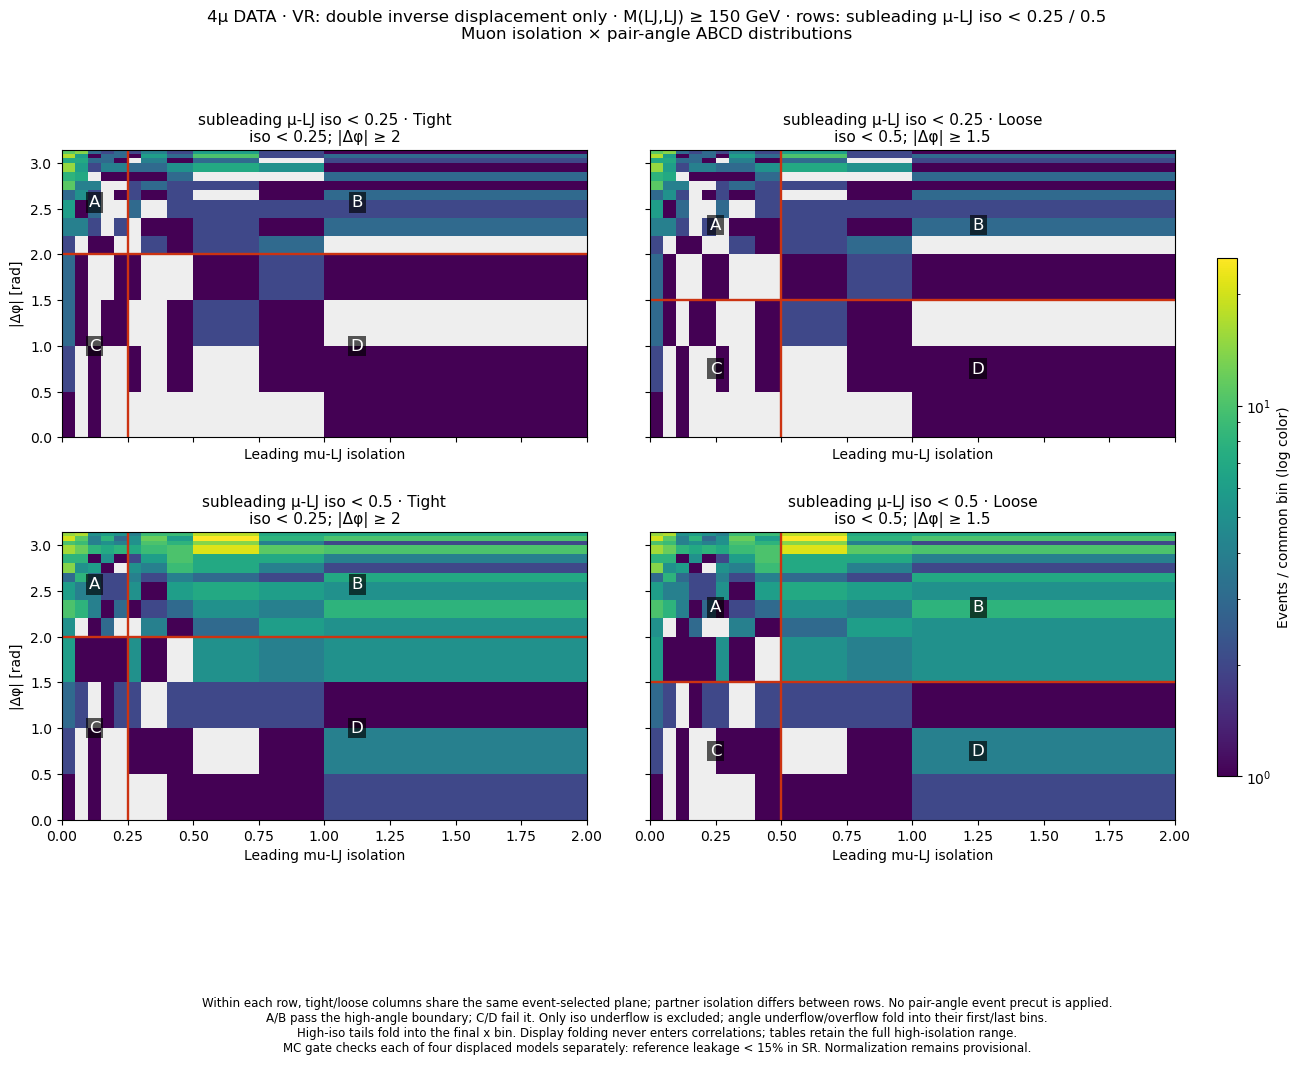

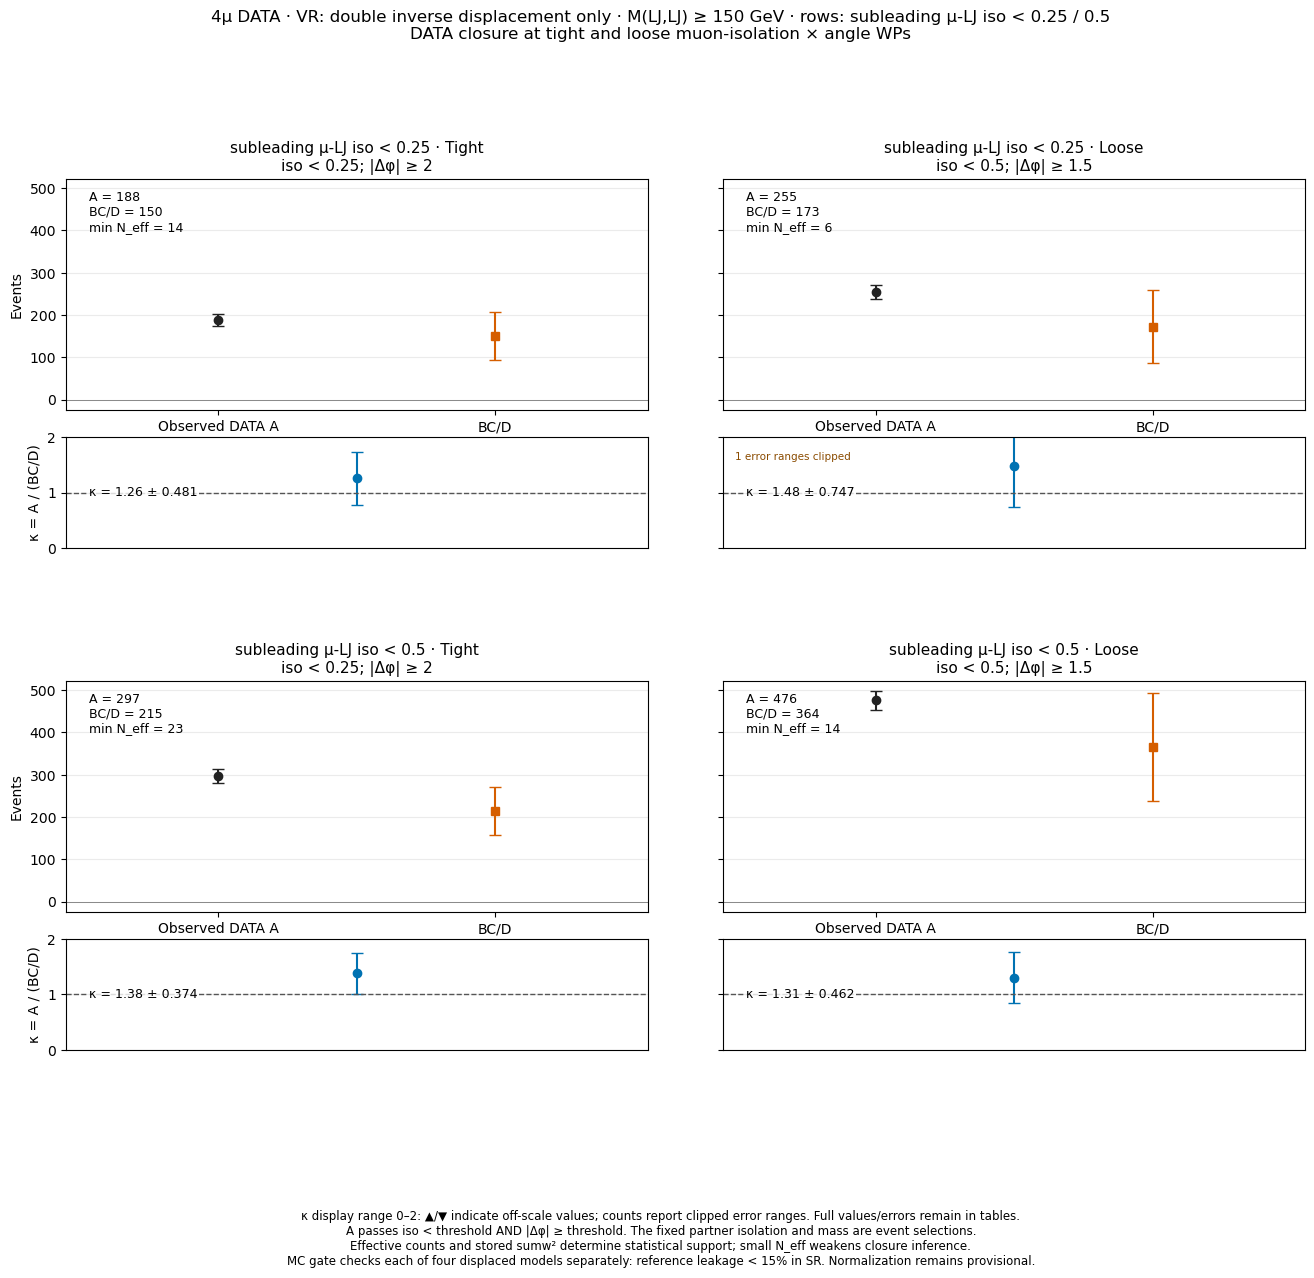

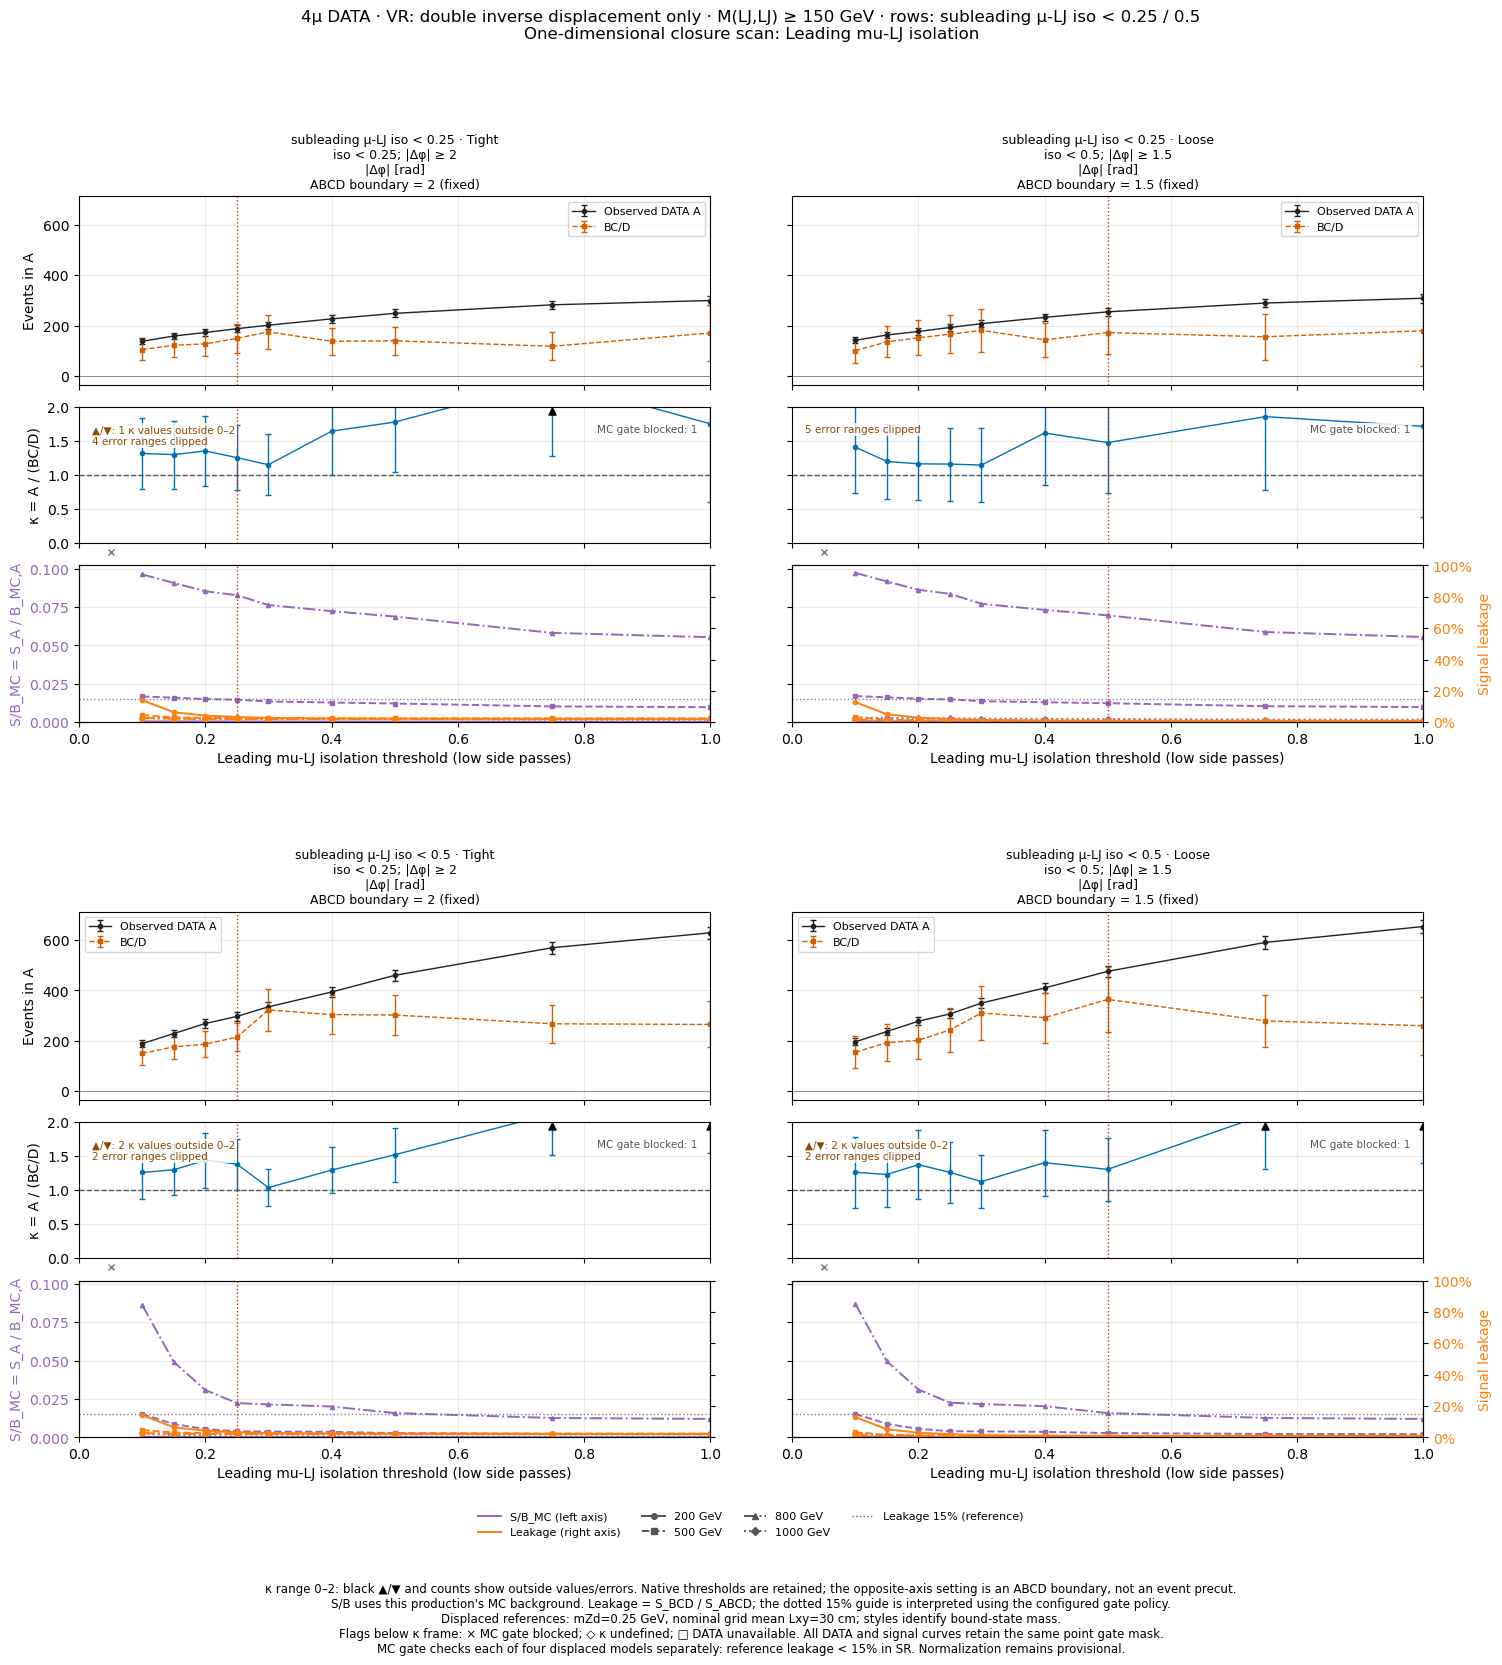

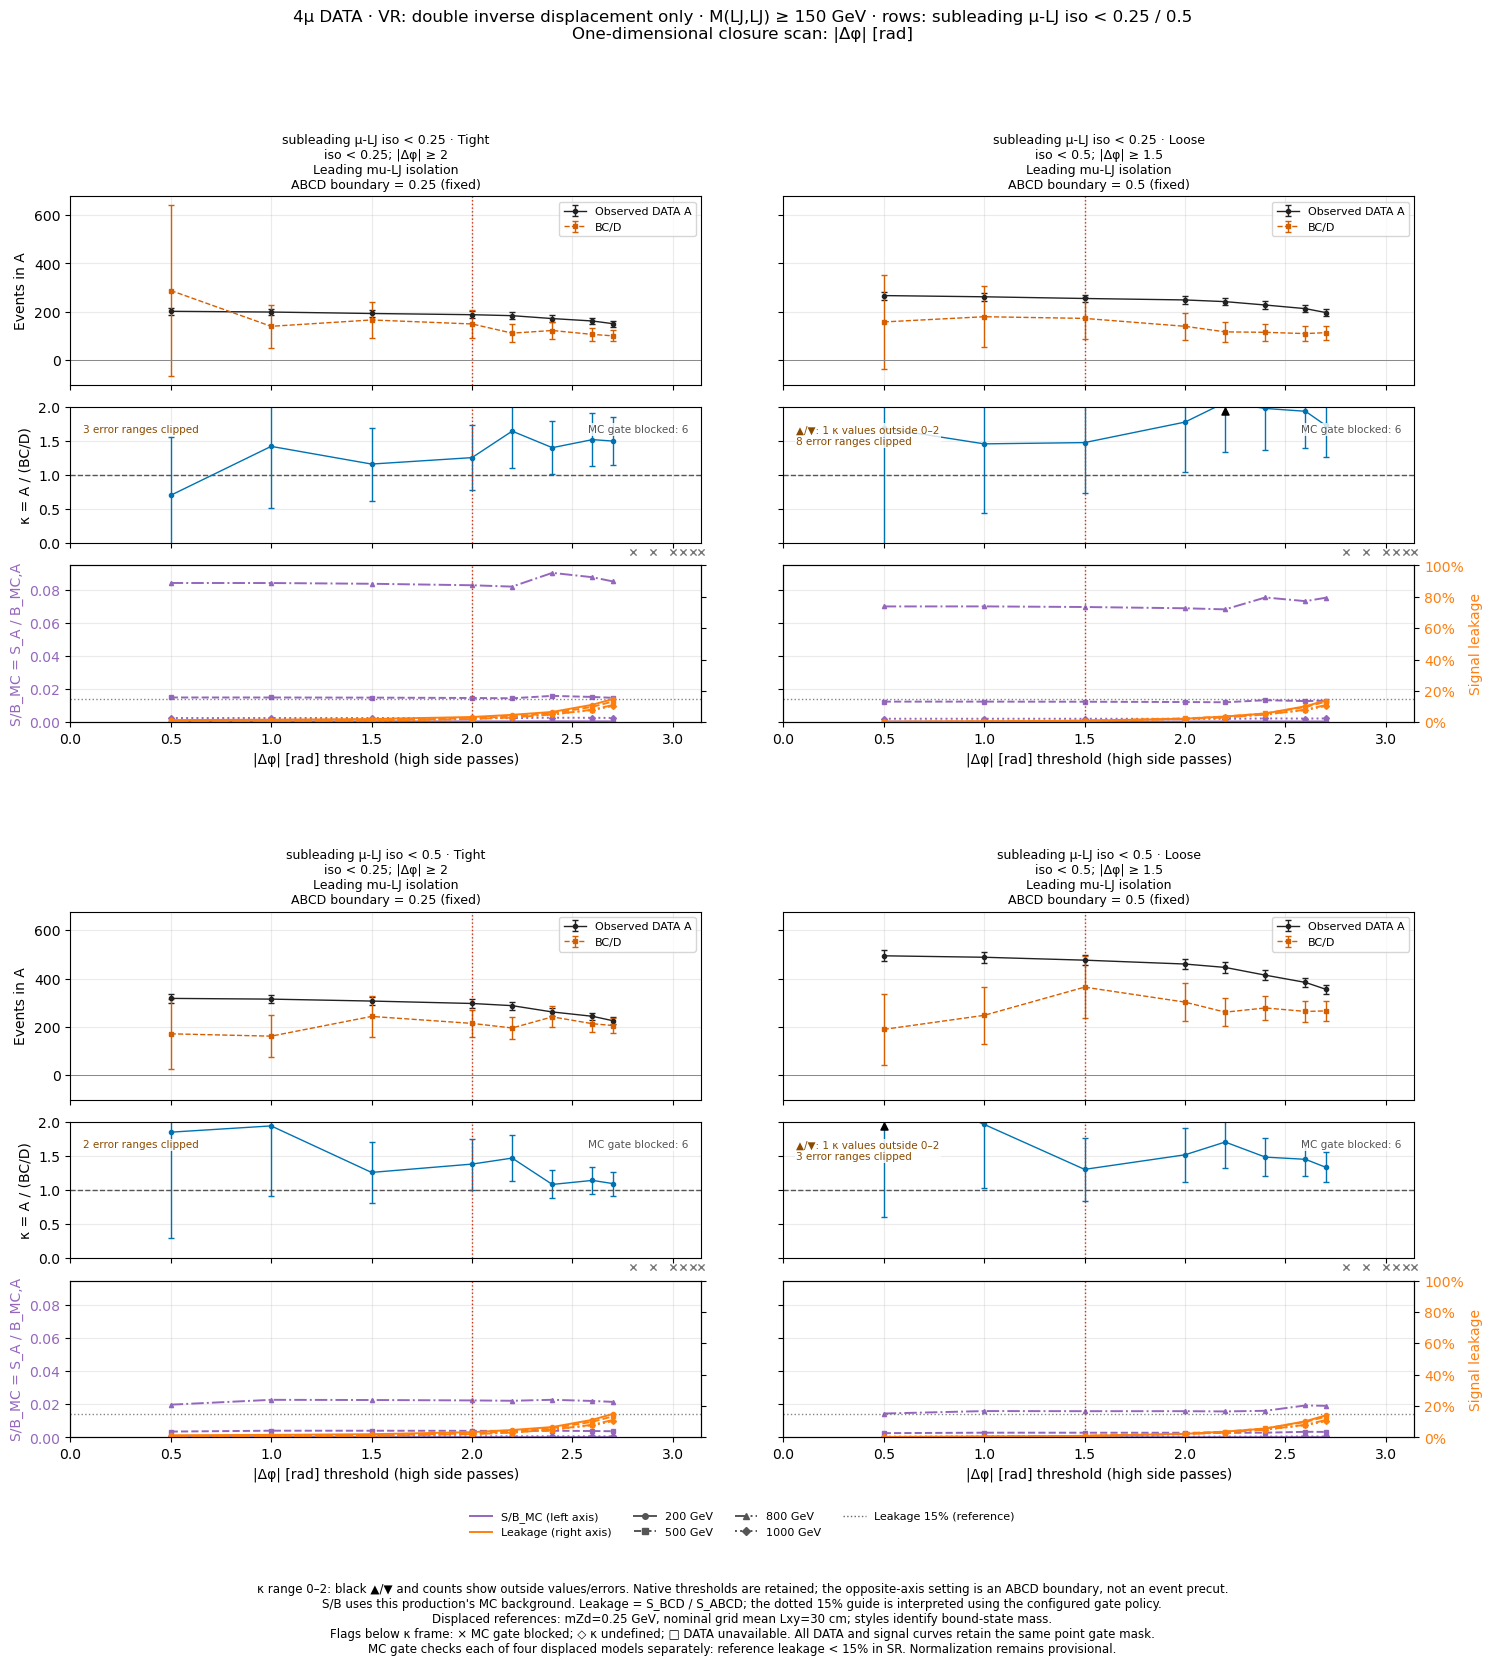

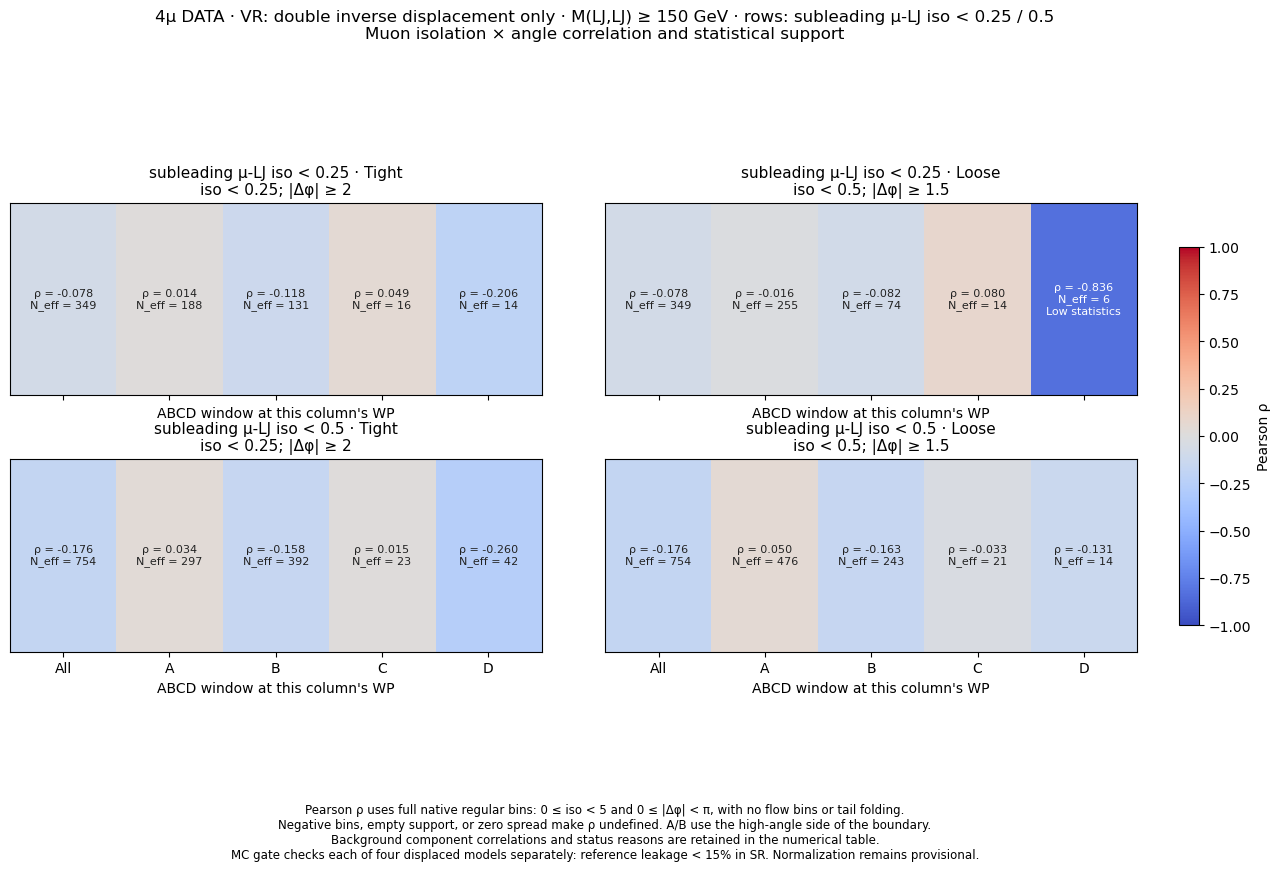

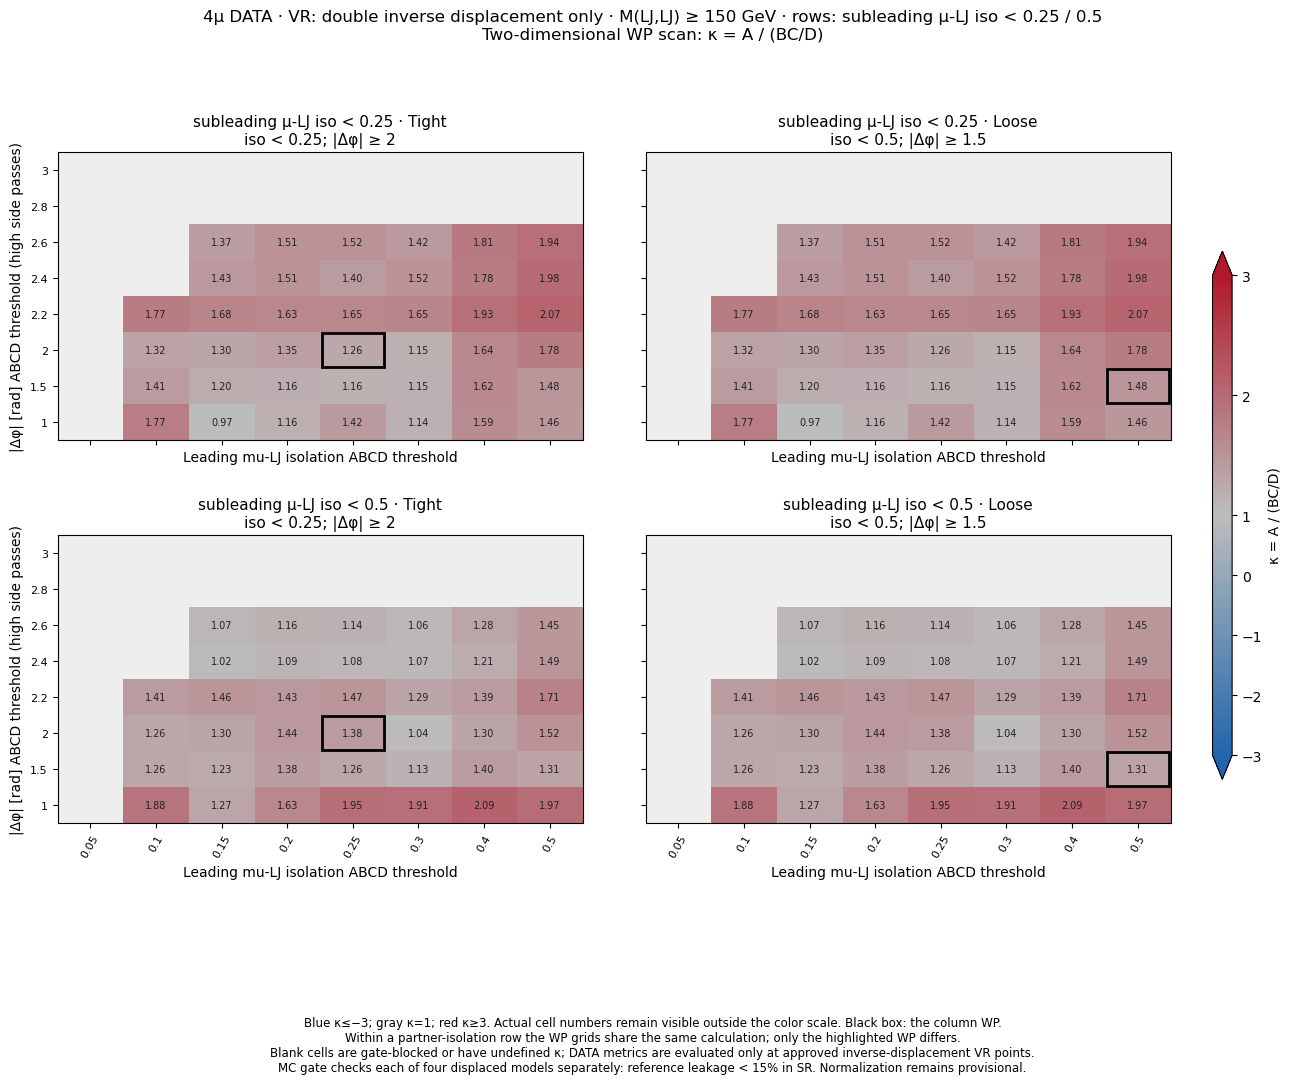

In [14]:
if RUN_DATA:
    present_plane_figures(plot_plane_distributions(data_results,DATA_CONFIG),source="DATA")
    present_plane_figures(plot_plane_closure(data_results,DATA_CONFIG),source="DATA")
    present_plane_figures(plot_plane_one_d(data_results,DATA_CONFIG),source="DATA")
    present_plane_figures(plot_plane_correlations(data_results,DATA_CONFIG),source="DATA")
    present_plane_figures(plot_plane_kappa_grid(data_results,DATA_CONFIG),source="DATA")
else:
    print("The conditional DATA VR section is disabled.")


## 10. Historical references and current interpretation

The current-6D predecessors already studied mu isolation×|Δφ|: [focused WP scan](Past_reference/ABCD_6D_focused_WP_scan.ipynb), [loose fixed-boundary 1D study](Past_reference/ABCD_1D_closure_fixed_events_loose_WP.ipynb), and [two-mass-profile study](Past_reference/ABCD_6D_VR_supported_mass_comparison_all_channels.ipynb). They provide plane definitions and display formats rather than independent old-versus-current datasets. Their non-plane partner isolation cut was **0.25**, whereas this notebook deliberately uses **0.50**. Their mass-inclusive and mass≥150 profiles must also be distinguished from the fixed mass≥150 selection here.

[Correlation/08](../Correlation/08_Fine_Combined_ABCD_2D_Closure_Study.ipynb) supplies an independent older iso×dphi workflow, including leading-muon and maximum-isolation alternatives in 4μ. Its loose_noHEM 2D histograms have no retained mass, displacement, or partner-isolation axes, so the fixed cuts required here cannot be restored from those outputs. The old angular binning also cannot represent 1.5 or 2.0 exactly. Use that notebook and its exploratory WP tables as history/style references only; its 4μ max-isolation plane is distinct from the leading-isolation plane used here.

Current results use both partner profiles and the selected leakage-only gate; previous saved contamination-gated DATA decisions are historical and are not reused.

In [15]:
slide_facts = tables["closure_summary"].copy()
slide_facts["mass_min_GeV"] = MASS_MIN
slide_facts["plane_pass_directions"] = "Muon isolation low; absolute delta phi high"
slide_facts["status"] = "Boundary comparison on current 6D; not a selected final working point"
data_slide_facts = data_tables["closure_summary"].copy()
data_slide_facts["scope"] = "Inverse-displacement VR only; four displaced-reference MC gate"
display(slide_facts)
display(data_slide_facts)


,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,...,neff_min,min_neff,min_sideband_neff,low_stat,partner_profile,profile,partner_iso_max,column,mass_min_GeV,plane_pass_directions
0,p025_tight,SR,0.25,2.0,0.002220,0.003465,1464.236194,2713.595676,1.000107,Boundary comparison on current 6D; not a selec...,...,1.000000,1.000000,1.000000,True,p025,p025,0.25,tight,150.0,Muon isolation low; absolute delta phi high
1,p025_tight,VR,0.25,2.0,5.228548,5.379134,24.053843,25.058809,5.657049,Boundary comparison on current 6D; not a selec...,...,1.115032,1.115032,1.115032,True,p025,p025,0.25,tight,150.0,Muon isolation low; absolute delta phi high
2,p025_loose,SR,0.50,1.5,0.006069,0.008926,649.425043,1100.277757,1.187281,Boundary comparison on current 6D; not a selec...,...,1.000000,1.000000,1.000000,True,p025,p025,0.25,loose,150.0,Muon isolation low; absolute delta phi high
3,p025_loose,VR,0.50,1.5,37.526056,22.364984,4.029717,2.488332,3.432547,Boundary comparison on current 6D; not a selec...,...,5.272311,5.272311,5.272311,True,p025,p025,0.25,loose,150.0,Muon isolation low; absolute delta phi high
4,p050_tight,SR,0.25,2.0,0.002300,0.003536,1414.432263,2592.668789,1.000874,Boundary comparison on current 6D; not a selec...,...,1.000000,1.000000,1.000000,True,p050,p050,0.50,tight,150.0,Muon isolation low; absolute delta phi high
5,p050_tight,VR,0.25,2.0,1007.603127,1145.069480,0.465619,0.559554,-0.464314,Boundary comparison on current 6D; not a selec...,...,1.014382,1.014382,1.014382,True,p050,p050,0.50,tight,150.0,Muon isolation low; absolute delta phi high
6,p050_loose,SR,0.50,1.5,0.010344,0.014561,381.264112,625.081717,1.186760,Boundary comparison on current 6D; not a selec...,...,1.072164,1.072164,1.072164,True,p050,p050,0.50,loose,150.0,Muon isolation low; absolute delta phi high
7,p050_loose,VR,0.50,1.5,1582.489683,1953.415860,0.422896,0.540122,-0.464598,Boundary comparison on current 6D; not a selec...,...,1.048333,1.048333,1.048333,True,p050,p050,0.50,loose,150.0,Muon isolation low; absolute delta phi high


,benchmark,context,tx,ty,pred,pred_error,kappa,kappa_error,pull,status,...,reference_count,gate_reference_mode,envelope_policy,signal_normalization_verified,policy,partner_profile,profile,partner_iso_max,column,scope
0,p025_tight,VR,0.25,2.0,149.714286,56.329621,1.255725,0.481258,0.660390,OK,...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,tight,Inverse-displacement VR only; four displaced-r...
1,p025_loose,VR,0.50,1.5,172.666667,86.610666,1.476834,0.746540,0.934857,LOW_STAT_SIDEBAND,...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p025,p025,0.25,loose,Inverse-displacement VR only; four displaced-r...
2,p050_tight,VR,0.25,2.0,214.666667,56.730030,1.383540,0.374339,1.388656,OK,...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p050,p050,0.50,tight,Inverse-displacement VR only; four displaced-r...
3,p050_loose,VR,0.50,1.5,364.500000,127.919687,1.305898,0.462192,0.859233,OK,...,4,Each named displaced mass reference independently,Maximum fraction is an audit summary only; ref...,False,Conditional four-reference leakage gate; full ...,p050,p050,0.50,loose,Inverse-displacement VR only; four displaced-r...


## 11. Export and review

Export the exact settings, input manifest, projection/selection definitions, region yields and variances, closure grid, native 1D scans, correlations, signal diagnostics, reference-region contamination audit, and DATA access/missing-point statuses with the figures. Preserve Neff and low-statistics flags independently of DATA access decisions.

Distinguish gate-blocked points, DATA not loaded, undefined prediction/closure, and finite values outside the displayed range. A DATA VR point is blocked when a selected SR reference fails the strict leakage requirement or lacks supported signal yields; background contamination is diagnostic only. Recompute all counts for this plane and the current four-reference scope; earlier iso×iso or prompt/displaced-pair counts are not the result of this study. VR closure remains validation of the stated plane and selection, and does not by itself establish an unbiased SR prediction or a final correction model.

Add a **pooled signal shape** using all 180 current signal samples, including both generated decay topologies. The existing golden legacy production contains 120 available models, so its pool uses those 120 and is labeled separately; old/current shape differences also reflect this grid-scope difference. Project every sample into the notebook's reconstructed topology and requested SR/VR/profile selection, sum the stored weighted bin contents first, then normalize the retained selected-plane sum to unit area for display. Do not normalize each sample separately before summation or apply another luminosity/cross-section factor. The inventory records the actual sample set, decay-topology balance, and retained weighted contributions for each source and profile.

This pool combines distinct physical hypotheses and is a visualization of the supplied signal library. It is **not a combined signal model**, an expected physical signal yield, or an input to S/B, leakage, WP selection, or the DATA gate. Those calculations continue to use the four displaced references individually. Differences between pooled shapes can reflect both event selection and the relative stored sample weights; state the source and sample inventory in the captions. Use the analysis's explicit flow policy for the normalization and fold bins for display only after forming the weighted pool.

Prompt-like samples may appear in this all-model visualization. They do not enter the four displaced-reference gate or its individual S/B/leakage diagnostics.

The DATA gate uses **SR signal leakage only**. Each of the four displaced references must independently satisfy
\(S_{BCD}/S_{ABCD}<0.15\); equality fails. Contamination \(S/(S+B_{MC})\) and VR leakage remain diagnostics and do not veto a point in this mode.
An empty, negative, or nonfinite signal support remains unsupported. `MC gate blocked` marks a failed reference-signal criterion, not a missing DATA file or an observed DATA closure test.


In [16]:
export_plane_results(mc_results,data_results,{"slide_facts":slide_facts,
    "data_VR_slide_facts":data_slide_facts,"figure_audit":pd.DataFrame(FIGURE_RECORDS)})
print("Complete: current 6D mu-isolation versus delta-phi tight/loose comparison.")


Saved plane comparison artifacts: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/08_MuIso_DPhi_4mu_6D_comparison_outputs
Complete: current 6D mu-isolation versus delta-phi tight/loose comparison.
